# STEP 1: Advanced Behavioural Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & Parse ──────────────────────────────────────────
df = pd.read_csv(r"c:\maharaja\college\Sem8 (WinterSem 25-26)\behavioural analytics\hackathon\synthetic_finance_dataset.csv", parse_dates=["timestamp"])
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df.dtypes)

# ── 2. Time-of-Day Behavioural Bins ──────────────────────────
# Theory: Impulse control weakens at night (ego depletion theory)
def time_of_day_bin(hour):
    if 5 <= hour < 12:   return "morning"
    elif 12 <= hour < 17: return "afternoon"
    elif 17 <= hour < 21: return "evening"
    else:                  return "late_night"

df["time_bin"] = df["hour"].apply(time_of_day_bin)
df["is_late_night"] = (df["time_bin"] == "late_night").astype(int)
df["is_evening"]    = (df["time_bin"] == "evening").astype(int)

# ── 3. Salary-Relative Spend ──────────────────────────────────
# Theory: Impulse is relative — Rs.500 means different things to different earners
df["spend_to_salary_ratio"]  = df["transaction_amount"] / df["monthly_salary"]
df["balance_to_salary_ratio"] = df["balance_after"] / df["monthly_salary"]

# Balance stress: low balance → scarcity mindset → paradoxically increases impulse
df["balance_stress"] = (df["balance_after"] < 0.1 * df["monthly_salary"]).astype(int)

# ── 4. Per-User Rolling Features (Temporal Behavioural Signals) ─
# Sort is already done; now group-apply rolling statistics
df = df.sort_values(["user_id", "timestamp"])

# Helper: rolling on a per-user basis
def user_rolling(df, col, windows=[3, 7], funcs={"mean": np.mean, "std": np.std}):
    for w in windows:
        for fname, func in funcs.items():
            feat_name = f"{col}_rolling{w}_{fname}"
            df[feat_name] = (
                df.groupby("user_id")[col]
                  .transform(lambda x: x.shift(1).rolling(w, min_periods=1).agg(func))
            )
    return df

df = user_rolling(df, "transaction_amount", windows=[3, 7])
df = user_rolling(df, "spend_to_salary_ratio", windows=[3, 7])

# ── 5. Spend Velocity (Burst Buying Signal) ───────────────────
# Deviation from personal baseline — high z-score = anomalous spend burst
df["user_mean_spend"] = df.groupby("user_id")["transaction_amount"].transform("mean")
df["user_std_spend"]  = df.groupby("user_id")["transaction_amount"].transform("std").replace(0, 1)
df["spend_zscore"]    = (df["transaction_amount"] - df["user_mean_spend"]) / df["user_std_spend"]
df["is_spend_burst"]  = (df["spend_zscore"] > 1.5).astype(int)  # 1.5σ above personal mean

# ── 6. Transaction Frequency Features ────────────────────────
# Impulse buyers transact more frequently in short windows
df["txn_count_last3"] = (
    df.groupby("user_id")["transaction_amount"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).count())
)
df["txn_count_last7"] = (
    df.groupby("user_id")["transaction_amount"]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).count())
)

# ── 7. Category-Level Encoding (Behavioural Risk Score) ──────
# Some categories are inherently high-impulse (Entertainment, Fashion, Food)
IMPULSE_RISK_MAP = {
    "Entertainment": 3,
    "Fashion":       3,
    "Food":          2,
    "Electronics":   2,
    "Travel":        2,
    "Utilities":     0,
    "Healthcare":    0,
    "Education":     0,
    "Groceries":     1,
    "Others":        1,
}
df["category_impulse_risk"] = df["merchant_category"].map(IMPULSE_RISK_MAP).fillna(1)

# One-hot encode merchant category for models
df = pd.get_dummies(df, columns=["merchant_category", "time_bin"], drop_first=False)

# ── 8. Weekend × Evening Interaction ─────────────────────────
# Combined contextual vulnerability: weekend + late activity = peak impulse zone
df["weekend_x_evening"]   = df["is_weekend"] * df["is_evening"]
df["weekend_x_latenight"] = df["is_weekend"] * df["is_late_night"]

# ── 9. Balance Drawdown Ratio ─────────────────────────────────
# How much of current balance was consumed by this transaction?
df["balance_before_approx"] = df["balance_after"] + df["transaction_amount"]
df["drawdown_ratio"]        = df["transaction_amount"] / (df["balance_before_approx"] + 1e-6)

# ── 10. User-Level Historical Impulse Rate (Leakage-Safe) ─────
# Prior impulse tendency of this user (shift to avoid target leakage)
df["user_impulse_rate"] = (
    df.groupby("user_id")["impulse_label"]
      .transform(lambda x: x.shift(1).expanding().mean())
).fillna(0.5)  # cold-start prior = 0.5

# ── Final Cleanup ─────────────────────────────────────────────
df = df.fillna(0)

print(f"\n Final shape after feature engineering: {df.shape}")
print(f" New features added: {df.shape[1] - 10}")
print("\nSample new features:")
new_cols = [c for c in df.columns if c not in [
    "transaction_id","user_id","timestamp","hour","is_weekend",
    "transaction_amount","balance_after","monthly_salary","impulse_label"
]]
print(new_cols)

# Save engineered dataset
df.to_csv("df_engineered.csv", index=False)
print("\n Saved: df_engineered.csv")

Shape: (23852, 10)
transaction_id                object
user_id                       object
timestamp             datetime64[ns]
hour                           int64
is_weekend                     int64
merchant_category             object
transaction_amount           float64
balance_after                float64
monthly_salary                 int64
impulse_label                  int64
dtype: object

 Final shape after feature engineering: (23852, 46)
 New features added: 36

Sample new features:
['is_late_night', 'is_evening', 'spend_to_salary_ratio', 'balance_to_salary_ratio', 'balance_stress', 'transaction_amount_rolling3_mean', 'transaction_amount_rolling3_std', 'transaction_amount_rolling7_mean', 'transaction_amount_rolling7_std', 'spend_to_salary_ratio_rolling3_mean', 'spend_to_salary_ratio_rolling3_std', 'spend_to_salary_ratio_rolling7_mean', 'spend_to_salary_ratio_rolling7_std', 'user_mean_spend', 'user_std_spend', 'spend_zscore', 'is_spend_burst', 'txn_count_last3', 'txn_count

# STEP 2: Exploratory Behavioural Analysis (EBA)

In [2]:
%pip install matplotlib seaborn numpy pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\maharajaMani\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


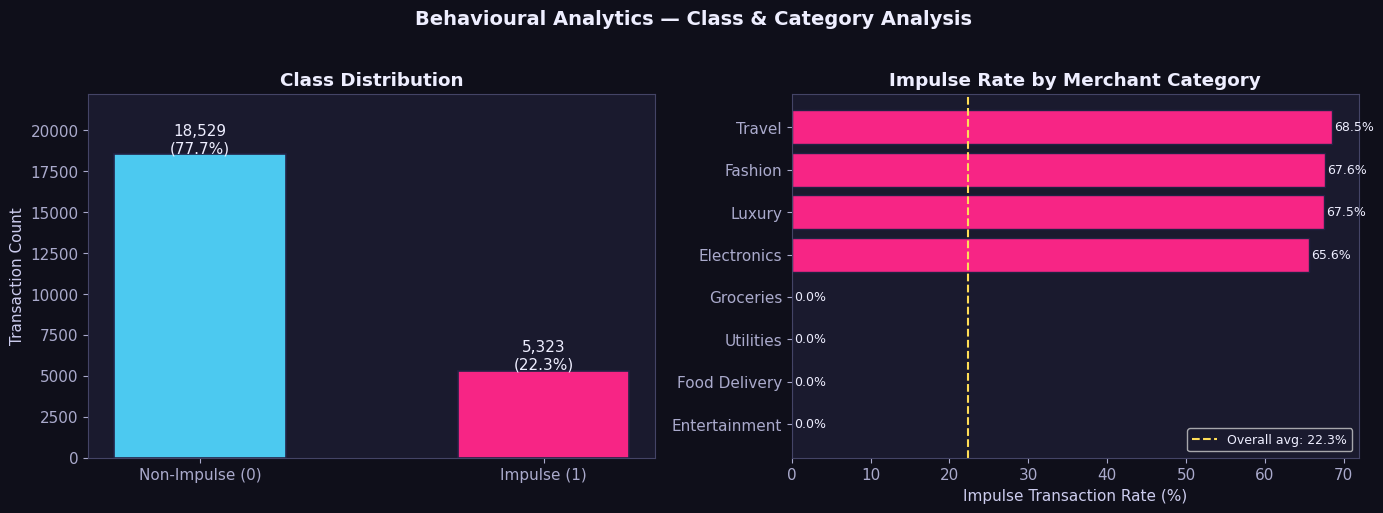

 Plot 1 saved


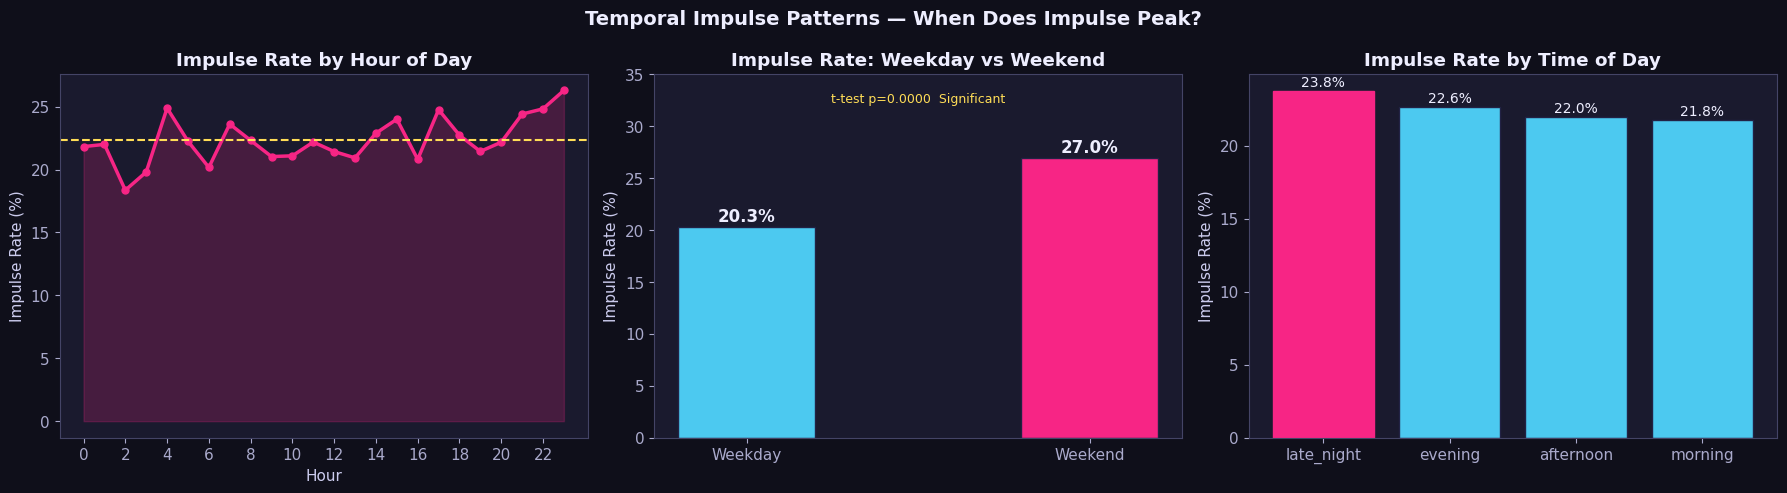

 Plot 2 saved


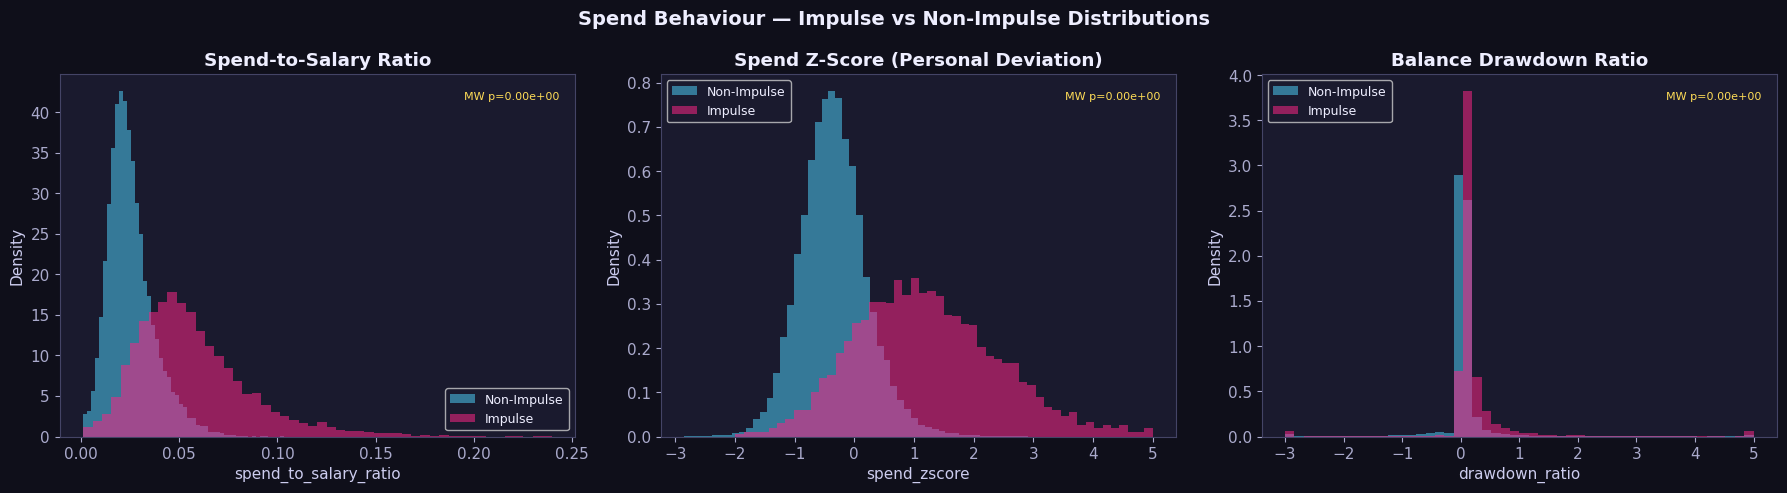

 Plot 3 saved


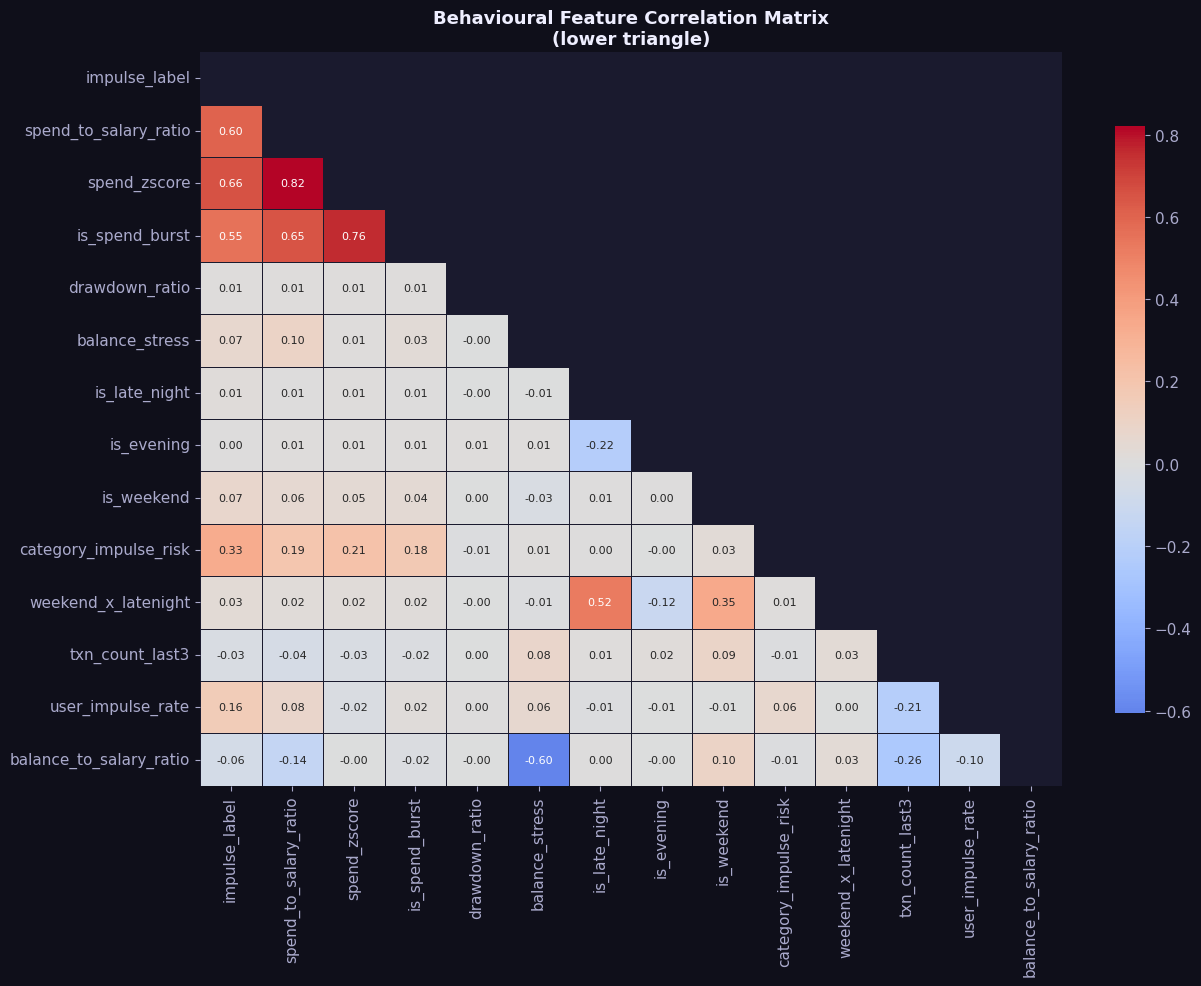

 Plot 4 saved

 BEHAVIOURAL STATISTICAL SUMMARY
              Feature  Non-Impulse Mean  Impulse Mean  Diff % MW p-value Significant
spend_to_salary_ratio            0.0255        0.0569   123.4   0.00e+00           ✅
         spend_zscore           -0.3490        1.2149  -448.1   0.00e+00           ✅
       drawdown_ratio           -0.0076        0.2727 -3695.2   0.00e+00           ✅
       balance_stress            0.1123        0.1646    46.6   1.81e-24           ✅
        is_late_night            0.1558        0.1689     8.4   2.08e-02           ✅
           is_weekend            0.2826        0.3633    28.5   1.10e-29           ✅
category_impulse_risk            1.1836        1.9972    68.7   0.00e+00           ✅
    user_impulse_rate            0.2151        0.2755    28.1  1.08e-151           ✅
      txn_count_last3            2.9060        2.8762    -1.0   1.33e-05           ✅

 Saved: eba_summary.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load engineered data ──────────────────────────────────────
df = pd.read_csv("df_engineered.csv", parse_dates=["timestamp"])

# Plotting style
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444466",
    "axes.labelcolor":  "#ccccee",
    "xtick.color":      "#aaaacc",
    "ytick.color":      "#aaaacc",
    "text.color":       "#eeeeff",
    "grid.color":       "#2a2a44",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.size":        11,
})
PALETTE = ["#4cc9f0", "#f72585"]

# ─────────────────────────────────────────────────────────────
# PLOT 1: Class Distribution + Impulse Rate by Category
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Behavioural Analytics — Class & Category Analysis", fontsize=14, fontweight="bold", y=1.02)

# 1a. Class balance
counts = df["impulse_label"].value_counts()
bars = axes[0].bar(["Non-Impulse (0)", "Impulse (1)"], counts.values,
                   color=PALETTE, edgecolor="#222244", linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Transaction Count")
axes[0].set_ylim(0, counts.max() * 1.2)

# 1b. Impulse rate by merchant category
cat_cols = [c for c in df.columns if c.startswith("merchant_category_")]
cat_names = [c.replace("merchant_category_", "") for c in cat_cols]
impulse_rates = []
for col in cat_cols:
    subset = df[df[col] == 1]
    impulse_rates.append(subset["impulse_label"].mean() * 100)

cat_df = pd.DataFrame({"category": cat_names, "impulse_rate": impulse_rates})
cat_df = cat_df.sort_values("impulse_rate", ascending=True)

colors = ["#f72585" if r > 40 else "#4cc9f0" for r in cat_df["impulse_rate"]]
axes[1].barh(cat_df["category"], cat_df["impulse_rate"], color=colors, edgecolor="#222244")
axes[1].axvline(df["impulse_label"].mean() * 100, color="#ffdd57", linestyle="--",
                linewidth=1.5, label=f"Overall avg: {df['impulse_label'].mean()*100:.1f}%")
axes[1].set_title("Impulse Rate by Merchant Category", fontweight="bold")
axes[1].set_xlabel("Impulse Transaction Rate (%)")
axes[1].legend(fontsize=9)
for i, (_, row) in enumerate(cat_df.iterrows()):
    axes[1].text(row["impulse_rate"] + 0.3, i, f"{row['impulse_rate']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot1_class_category.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot 1 saved")


# ─────────────────────────────────────────────────────────────
# PLOT 2: Temporal Behavioural Patterns (FIXED)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(top=0.88)          # ← tightly controls title space
fig.suptitle("Temporal Impulse Patterns — When Does Impulse Peak?",
             fontsize=14, fontweight="bold")  # ← removed y=1.02

# 2a. Impulse rate by hour of day
hourly = df.groupby("hour")["impulse_label"].mean().reset_index()
axes[0].plot(hourly["hour"], hourly["impulse_label"] * 100,
             color="#f72585", linewidth=2.5, marker="o", markersize=5)
axes[0].fill_between(hourly["hour"], hourly["impulse_label"] * 100, alpha=0.2, color="#f72585")
axes[0].axhline(df["impulse_label"].mean() * 100, color="#ffdd57", linestyle="--", linewidth=1.5)
axes[0].set_title("Impulse Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Impulse Rate (%)")
axes[0].set_xticks(range(0, 24, 2))

# 2b. Impulse rate: weekday vs weekend
wk = df.groupby("is_weekend")["impulse_label"].mean() * 100
axes[1].bar(["Weekday", "Weekend"], wk.values, color=PALETTE, width=0.4, edgecolor="#222244")
for i, v in enumerate(wk.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Impulse Rate: Weekday vs Weekend", fontweight="bold")
axes[1].set_ylabel("Impulse Rate (%)")
axes[1].set_ylim(0, wk.max() * 1.3)

weekday_imp = df[df["is_weekend"] == 0]["impulse_label"]
weekend_imp = df[df["is_weekend"] == 1]["impulse_label"]
t_stat, p_val = stats.ttest_ind(weekday_imp, weekend_imp)
sig_text = f"t-test p={p_val:.4f} {' Significant' if p_val < 0.05 else '❌ Not significant'}"
axes[1].text(0.5, 0.92, sig_text, ha="center", fontsize=9,
             color="#ffdd57", transform=axes[1].transAxes)  # ← use transAxes, not data coords

# 2c. Impulse rate by time bin
time_cols = [c for c in df.columns if c.startswith("time_bin_")]
time_names = [c.replace("time_bin_", "") for c in time_cols]
time_rates = [df[df[col] == 1]["impulse_label"].mean() * 100 for col in time_cols]
time_df = pd.DataFrame({"time_bin": time_names, "rate": time_rates}).sort_values("rate", ascending=False)
bars = axes[2].bar(time_df["time_bin"], time_df["rate"], color="#4cc9f0", edgecolor="#222244")
bars[0].set_color("#f72585")
axes[2].set_title("Impulse Rate by Time of Day", fontweight="bold")
axes[2].set_ylabel("Impulse Rate (%)")
for bar, v in zip(bars, time_df["rate"]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot2_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot 2 saved")

# ─────────────────────────────────────────────────────────────
# PLOT 3: Spend Behaviour Distributions
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Spend Behaviour — Impulse vs Non-Impulse Distributions", fontsize=14, fontweight="bold")

features_to_plot = [
    ("spend_to_salary_ratio", "Spend-to-Salary Ratio"),
    ("spend_zscore",          "Spend Z-Score (Personal Deviation)"),
    ("drawdown_ratio",        "Balance Drawdown Ratio"),
]

for ax, (feat, title) in zip(axes, features_to_plot):
    for label, color in [(0, "#4cc9f0"), (1, "#f72585")]:
        subset = df[df["impulse_label"] == label][feat].clip(-3, 5)
        ax.hist(subset, bins=50, alpha=0.55, color=color,
                label=f"{'Impulse' if label else 'Non-Impulse'}", density=True, edgecolor="none")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

    # Mann-Whitney U test (non-parametric, robust for skewed financial data)
    g0 = df[df["impulse_label"] == 0][feat].dropna()
    g1 = df[df["impulse_label"] == 1][feat].dropna()
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    ax.text(0.97, 0.95, f"MW p={p_val:.2e}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#ffdd57")

plt.tight_layout()
plt.savefig("plot3_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot 3 saved")


# ─────────────────────────────────────────────────────────────
# PLOT 4: Feature Correlation Heatmap (Top Behavioural Features)
# ─────────────────────────────────────────────────────────────
key_features = [
    "impulse_label", "spend_to_salary_ratio", "spend_zscore", "is_spend_burst",
    "drawdown_ratio", "balance_stress", "is_late_night", "is_evening",
    "is_weekend", "category_impulse_risk", "weekend_x_latenight",
    "txn_count_last3", "user_impulse_rate", "balance_to_salary_ratio"
]
corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="#1a1a2e",
            annot_kws={"size": 8}, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Behavioural Feature Correlation Matrix\n(lower triangle)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("plot4_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot 4 saved")


# ─────────────────────────────────────────────────────────────
# STATISTICAL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print(" BEHAVIOURAL STATISTICAL SUMMARY")
print("="*65)

numerical_feats = [
    "spend_to_salary_ratio", "spend_zscore", "drawdown_ratio",
    "balance_stress", "is_late_night", "is_weekend",
    "category_impulse_risk", "user_impulse_rate", "txn_count_last3"
]

rows = []
for feat in numerical_feats:
    g0 = df[df["impulse_label"] == 0][feat].dropna()
    g1 = df[df["impulse_label"] == 1][feat].dropna()
    _, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    rows.append({
        "Feature":         feat,
        "Non-Impulse Mean": round(g0.mean(), 4),
        "Impulse Mean":    round(g1.mean(), 4),
        "Diff %":          round((g1.mean() - g0.mean()) / (g0.mean() + 1e-9) * 100, 1),
        "MW p-value":      f"{p:.2e}",
        "Significant":     "✅" if p < 0.05 else "❌"
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("eba_summary.csv", index=False)
print("\n Saved: eba_summary.csv")

# STEP 3: Baseline Model — Logistic Regression

Feature matrix shape : (23852, 36)
Class distribution   : {0: 18529, 1: 5323}
Positive class rate  : 0.2232

Train size : 19081 | Test size : 4771

--- 5-Fold Cross Validation Results (Train Set) ---
  roc_auc     : 0.9876  (+/- 0.0011)
  f1          : 0.8381  (+/- 0.0087)
  precision   : 0.7405  (+/- 0.0123)
  recall      : 0.9655  (+/- 0.0071)

--- Test Set Performance (default threshold = 0.5) ---
              precision    recall  f1-score   support

 Non-Impulse       0.99      0.90      0.95      3706
     Impulse       0.74      0.98      0.84      1065

    accuracy                           0.92      4771
   macro avg       0.87      0.94      0.89      4771
weighted avg       0.94      0.92      0.92      4771

ROC-AUC  : 0.9893
Avg Prec : 0.9663

--- Threshold-Tuned Performance (threshold = 0.81) ---
              precision    recall  f1-score   support

 Non-Impulse       0.96      0.97      0.97      3706
     Impulse       0.91      0.87      0.89      1065

    accuracy 

<Figure size 2200x1100 with 0 Axes>

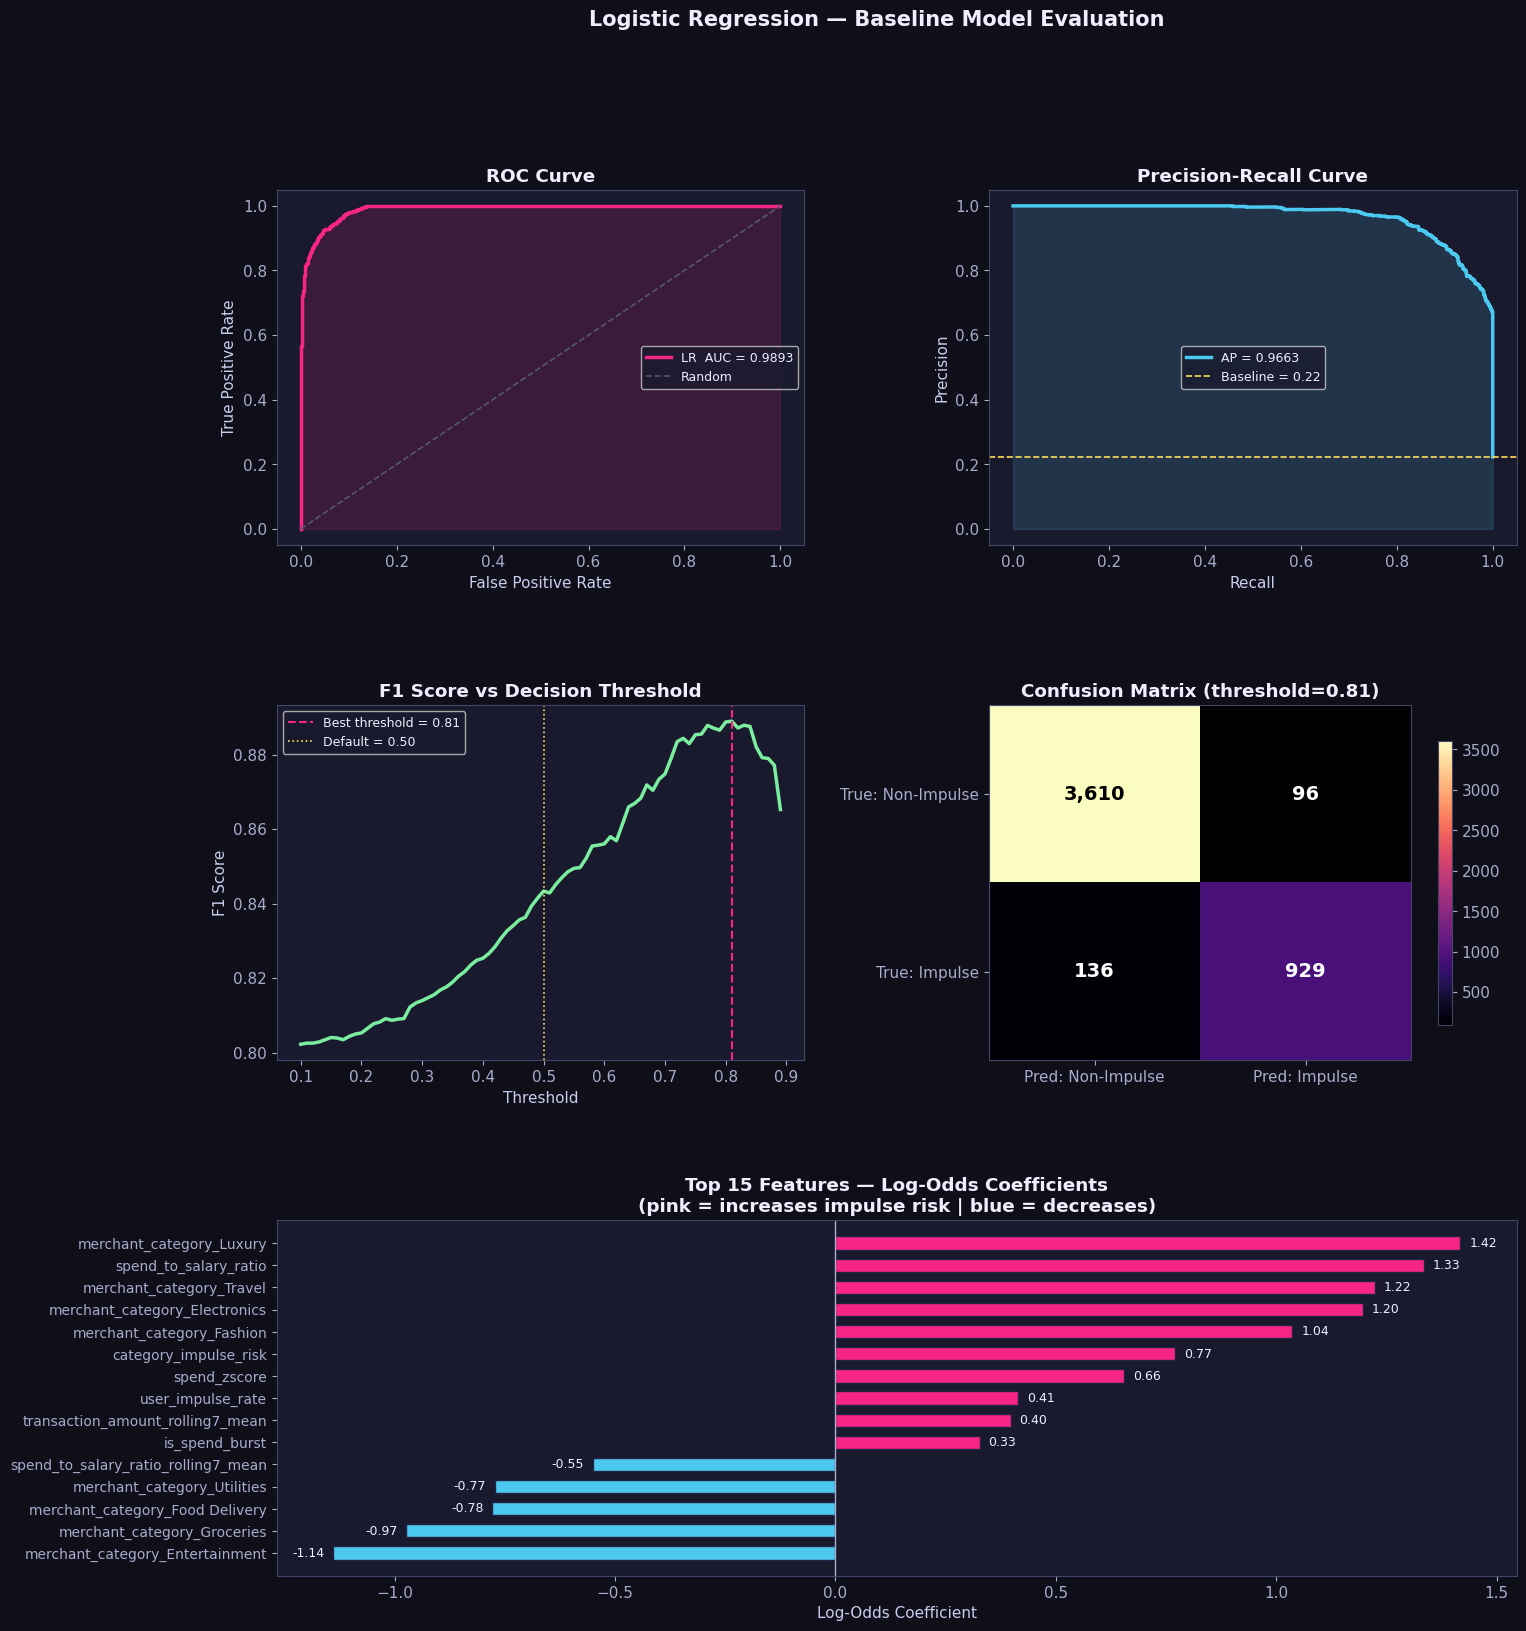


Saved: model_lr_baseline.pkl
Saved: train_test_split.pkl
Saved: lr_odds_ratios.csv

Baseline complete. Proceed to STEP 4.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & Define Feature Set ─────────────────────────────
df = pd.read_csv("df_engineered.csv")

# Columns to exclude from features
EXCLUDE = [
    "transaction_id", "user_id", "timestamp",
    "impulse_label",
    # Exclude raw scale leakers — model should use ratios, not raw amounts
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]

feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols]
y = df["impulse_label"]

print(f"Feature matrix shape : {X.shape}")
print(f"Class distribution   : {y.value_counts().to_dict()}")
print(f"Positive class rate  : {y.mean():.4f}\n")

# ── 2. Train / Test Split (Stratified) ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)
print(f"Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")

# ── 3. Build Pipeline ─────────────────────────────────────────
# Pipeline prevents data leakage — scaler fit only on train fold
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        class_weight="balanced",   # handles class imbalance via loss weighting
        max_iter=1000,
        solver="lbfgs",
        C=0.1,                     # mild L2 regularization — reduces overfitting on correlated features
        random_state=42
    ))
])

# ── 4. Cross-Validated Training (5-Fold Stratified) ──────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipe_lr, X_train, y_train, cv=cv,
    scoring=["roc_auc", "f1", "precision", "recall"],
    return_train_score=True
)

print("\n--- 5-Fold Cross Validation Results (Train Set) ---")
for metric in ["roc_auc", "f1", "precision", "recall"]:
    test_scores = cv_results[f"test_{metric}"]
    print(f"  {metric:<12}: {test_scores.mean():.4f}  (+/- {test_scores.std():.4f})")

# ── 5. Fit on Full Train, Evaluate on Held-Out Test ──────────
pipe_lr.fit(X_train, y_train)
y_prob  = pipe_lr.predict_proba(X_test)[:, 1]
y_pred  = pipe_lr.predict(X_test)

print("\n--- Test Set Performance (default threshold = 0.5) ---")
print(classification_report(y_test, y_pred, target_names=["Non-Impulse", "Impulse"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Prec : {average_precision_score(y_test, y_prob):.4f}")

# ── 6. Threshold Tuning via F1 Curve ─────────────────────────
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_tuned = (y_prob >= best_thresh).astype(int)

print(f"\n--- Threshold-Tuned Performance (threshold = {best_thresh:.2f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Impulse", "Impulse"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# ── 7. Odds Ratios (Behavioural Interpretability) ─────────────
scaler  = pipe_lr.named_steps["scaler"]
clf     = pipe_lr.named_steps["clf"]
coefs   = clf.coef_[0]
odds    = np.exp(coefs)

odds_df = pd.DataFrame({
    "feature":    feature_cols,
    "coefficient": coefs,
    "odds_ratio":  odds
}).sort_values("odds_ratio", ascending=False)

print("\n--- Top 10 Impulse-Increasing Features (Odds Ratio) ---")
print(odds_df.head(10).to_string(index=False))
print("\n--- Top 10 Impulse-Decreasing Features ---")
print(odds_df.tail(10).to_string(index=False))

odds_df.to_csv("lr_odds_ratios.csv", index=False)

# ── 8. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
    "font.size": 11,
})

fig = plt.figure(figsize=(22, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.5)
fig.suptitle("Logistic Regression — Baseline Model Evaluation", fontsize=15, fontweight="bold")


# 8a. ROC Curve
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Logistic Regression — Baseline Model Evaluation", fontsize=15, fontweight="bold")

# Row 1 — ROC and Precision-Recall
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score    = roc_auc_score(y_test, y_prob)
ax1.plot(fpr, tpr, color="#f72585", linewidth=2.5, label=f"LR  AUC = {auc_score:.4f}")
ax1.plot([0,1],[0,1], color="#555577", linestyle="--", linewidth=1.2, label="Random")
ax1.fill_between(fpr, tpr, alpha=0.15, color="#f72585")
ax1.set_title("ROC Curve", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
prec, rec, thrs = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
ax2.plot(rec, prec, color="#4cc9f0", linewidth=2.5, label=f"AP = {ap:.4f}")
ax2.axhline(y.mean(), color="#ffdd57", linestyle="--", linewidth=1.2, label=f"Baseline = {y.mean():.2f}")
ax2.fill_between(rec, prec, alpha=0.15, color="#4cc9f0")
ax2.set_title("Precision-Recall Curve", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9)

# Row 2 — F1 Threshold and Confusion Matrix
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(thresholds, f1_scores, color="#7bed9f", linewidth=2.5)
ax3.axvline(best_thresh, color="#f72585", linestyle="--", linewidth=1.5,
            label=f"Best threshold = {best_thresh:.2f}")
ax3.axvline(0.5, color="#ffdd57", linestyle=":", linewidth=1.2, label="Default = 0.50")
ax3.set_title("F1 Score vs Decision Threshold", fontweight="bold")
ax3.set_xlabel("Threshold")
ax3.set_ylabel("F1 Score")
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_test, y_pred_tuned)
im = ax4.imshow(cm, cmap=plt.cm.get_cmap("magma"), aspect="auto")
plt.colorbar(im, ax=ax4, shrink=0.8)
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                 fontsize=14, fontweight="bold",
                 color="white" if cm[i,j] < cm.max()/2 else "black")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["Pred: Non-Impulse", "Pred: Impulse"])
ax4.set_yticklabels(["True: Non-Impulse", "True: Impulse"])
ax4.set_title(f"Confusion Matrix (threshold={best_thresh:.2f})", fontweight="bold")

# Row 3 — Top 15 Odds Ratio (full width)
ax5 = fig.add_subplot(gs[2, :])
top_n   = 15
plot_df = odds_df.reindex(
    odds_df["coefficient"].abs().nlargest(top_n).index
).sort_values("coefficient")

colors = ["#f72585" if c > 0 else "#4cc9f0" for c in plot_df["coefficient"]]
ax5.barh(plot_df["feature"], plot_df["coefficient"], color=colors,
         edgecolor="#222244", height=0.6)
ax5.axvline(0, color="#aaaacc", linewidth=1.0)
ax5.set_title("Top 15 Features — Log-Odds Coefficients\n(pink = increases impulse risk | blue = decreases)",
              fontweight="bold")
ax5.set_xlabel("Log-Odds Coefficient")
ax5.tick_params(axis="y", labelsize=10)
ax5.margins(y=0.05)

for bar, val in zip(ax5.patches, plot_df["coefficient"]):
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ha   = "left" if val >= 0 else "right"
    ax5.text(xpos, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", ha=ha, fontsize=9, color="#eeeeff")

plt.savefig("plot3_lr_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9. Save artifacts ─────────────────────────────────────────
import joblib
joblib.dump(pipe_lr, "model_lr_baseline.pkl")
joblib.dump((X_train, X_test, y_train, y_test), "train_test_split.pkl")

print("\nSaved: model_lr_baseline.pkl")
print("Saved: train_test_split.pkl")
print("Saved: lr_odds_ratios.csv")
print("\nBaseline complete. Proceed to STEP 4.")

# STEP 4: Advanced Models — Random Forest + XGBoost

In [5]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [6]:
%pip install matplotlib seaborn numpy pandas scikit-learn optuna joblib xgboost lightgbm shap


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\maharajamani\appdata\local\programs\python\python310\lib\site-packages (3.10.8)



You should consider upgrading via the 'c:\Users\maharajaMani\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Train class ratio  (neg/pos): 3.48

Tuning Random Forest...


Best trial: 33. Best value: 0.988307: 100%|██████████| 40/40 [11:29<00:00, 17.25s/it]


Best RF ROC-AUC (CV): 0.9883
Best RF Params      : {'n_estimators': 159, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.6143528409664252}

Tuning XGBoost...


Best trial: 13. Best value: 0.988792: 100%|██████████| 40/40 [02:46<00:00,  4.17s/it]


Best XGB ROC-AUC (CV): 0.9888
Best XGB Params      : {'n_estimators': 594, 'max_depth': 3, 'learning_rate': 0.027279496663267264, 'subsample': 0.5050712354687058, 'colsample_bytree': 0.8255079015857973, 'reg_alpha': 0.016112505320184437, 'reg_lambda': 9.92686677050091, 'min_child_weight': 8}

MODEL COMPARISON — TEST SET
              Model  ROC-AUC  Avg Prec     F1  Precision  Recall
Logistic Regression   0.9893    0.9663 0.8890     0.9063  0.8723
      Random Forest   0.9884    0.9628 0.8911     0.8988  0.8836
            XGBoost   0.9895    0.9676 0.8930     0.9127  0.8742


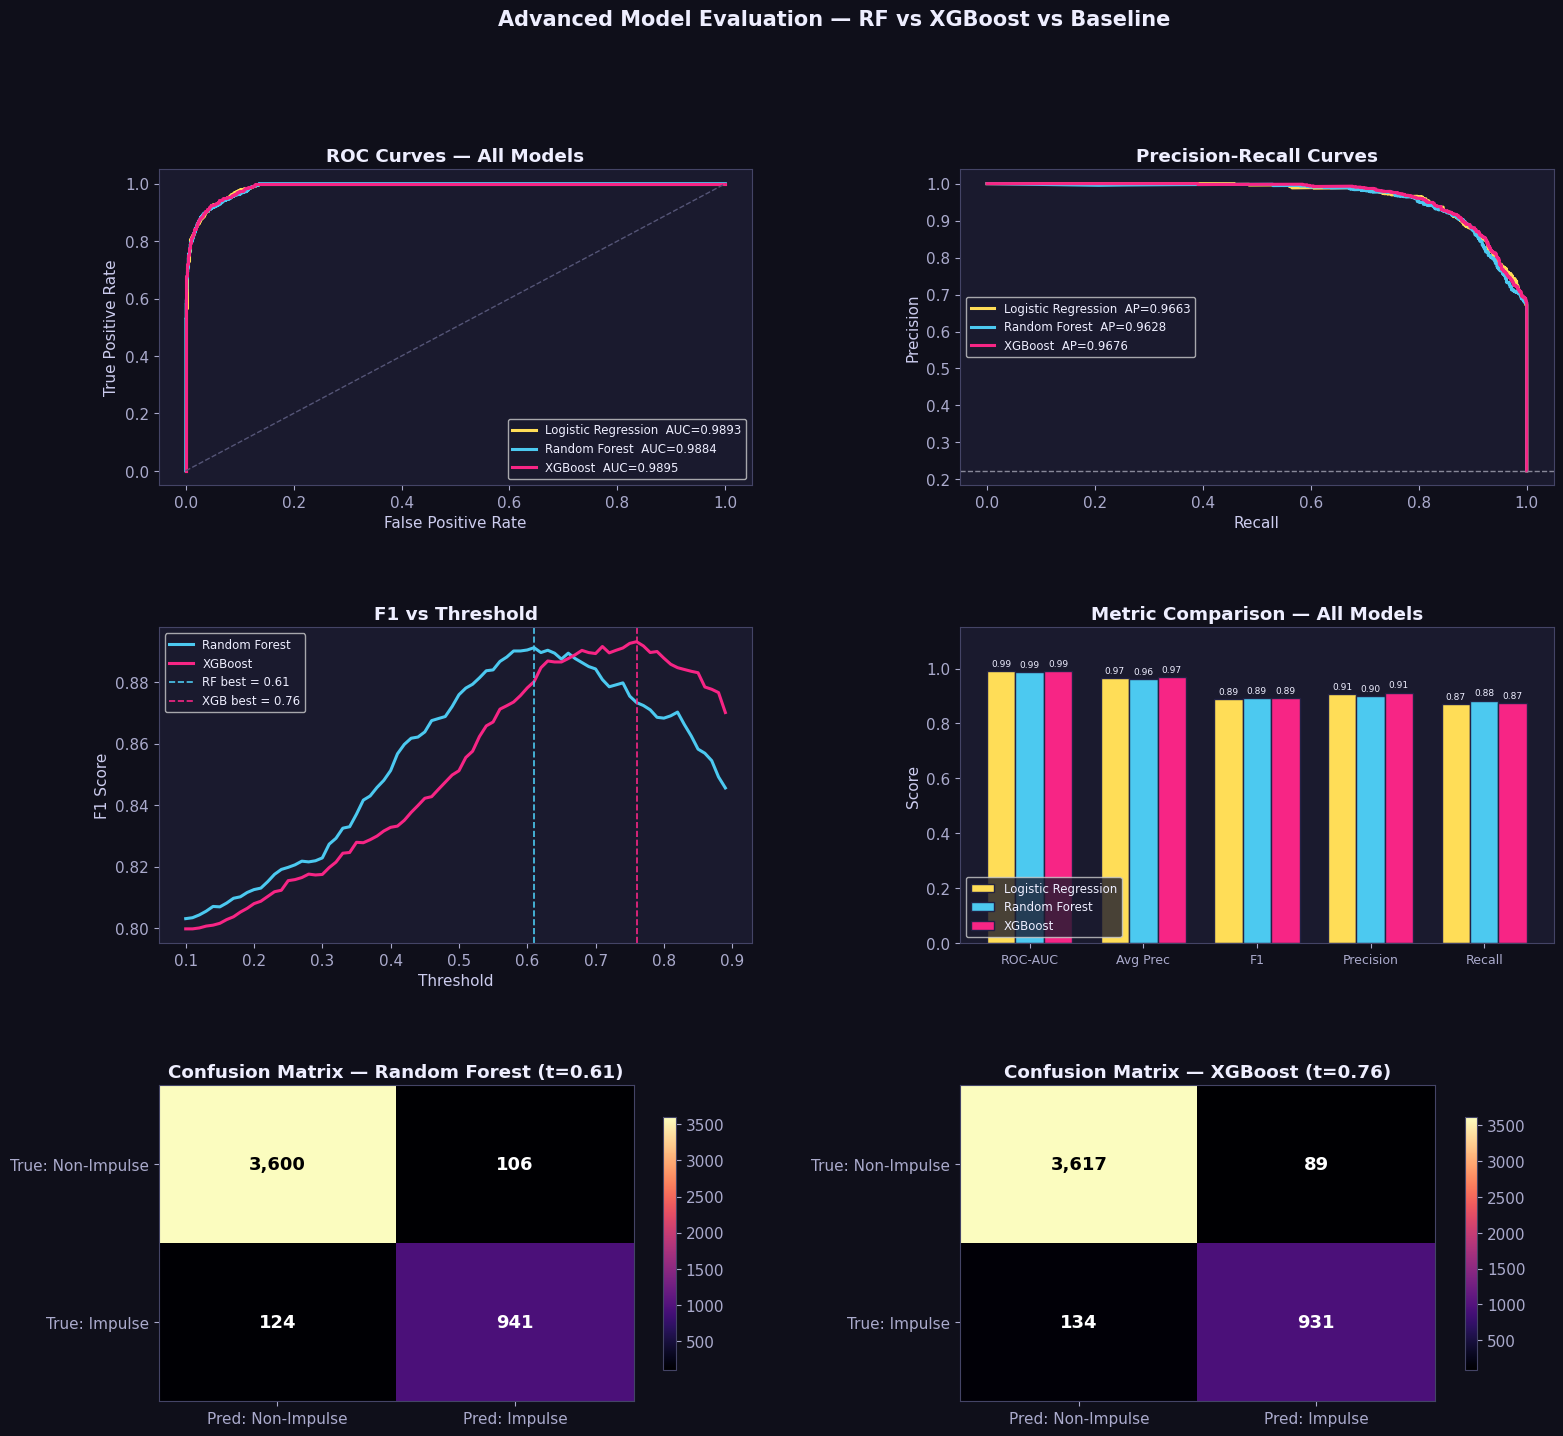


Saved: model_rf.pkl
Saved: model_xgb.pkl
Saved: best_thresholds.pkl
Saved: model_comparison.csv

Step 4 complete. Proceed to STEP 5.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import optuna
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report,
    roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier


# ── 1. Load Data & Splits ─────────────────────────────────────
df = pd.read_csv("df_engineered.csv")

EXCLUDE = [
    "transaction_id", "user_id", "timestamp", "impulse_label",
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X_train, X_test, y_train, y_test = joblib.load("train_test_split.pkl")

neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
scale_pos = neg / pos   # for XGBoost class imbalance correction
print(f"Train class ratio  (neg/pos): {scale_pos:.2f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 2. Random Forest — Optuna Tuning ─────────────────────────
print("\nTuning Random Forest...")

def rf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_float("max_features", 0.3, 0.9),
        "class_weight":      "balanced",
        "n_jobs":            -1,
        "random_state":      42,
    }
    clf    = RandomForestClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

rf_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=40, show_progress_bar=True)

print(f"Best RF ROC-AUC (CV): {rf_study.best_value:.4f}")
print(f"Best RF Params      : {rf_study.best_params}")

best_rf = RandomForestClassifier(
    **rf_study.best_params,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train, y_train)

# ── 3. XGBoost — Optuna Tuning ───────────────────────────────
print("\nTuning XGBoost...")

def xgb_objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 600),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight":   scale_pos,
        "eval_metric":        "auc",
        "use_label_encoder":  False,
        "random_state":       42,
        "n_jobs":             -1,
    }
    clf    = XGBClassifier(**params, verbosity=0)
    scores = cross_val_score(clf, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

xgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

print(f"Best XGB ROC-AUC (CV): {xgb_study.best_value:.4f}")
print(f"Best XGB Params      : {xgb_study.best_params}")

best_xgb = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight=scale_pos,
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
best_xgb.fit(X_train, y_train)

# ── 4. Threshold Tuning for Both Models ──────────────────────
def tune_threshold(model, X, y_true):
    y_prob = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
                  for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]
    return y_prob, best_t, thresholds, f1_scores

rf_prob,  rf_thresh,  rf_thrs,  rf_f1s  = tune_threshold(best_rf,  X_test, y_test)
xgb_prob, xgb_thresh, xgb_thrs, xgb_f1s = tune_threshold(best_xgb, X_test, y_test)

rf_pred  = (rf_prob  >= rf_thresh).astype(int)
xgb_pred = (xgb_prob >= xgb_thresh).astype(int)

# ── 5. Load Logistic Regression for Comparison ───────────────
pipe_lr  = joblib.load("model_lr_baseline.pkl")
lr_prob  = pipe_lr.predict_proba(X_test)[:, 1]

# ── 6. Model Comparison Table ────────────────────────────────
print("\n" + "="*70)
print("MODEL COMPARISON — TEST SET")
print("="*70)

models = {
    "Logistic Regression": (lr_prob,  (lr_prob  >= 0.81).astype(int)),
    "Random Forest":       (rf_prob,  rf_pred),
    "XGBoost":             (xgb_prob, xgb_pred),
}

rows = []
for name, (prob, pred) in models.items():
    rows.append({
        "Model":       name,
        "ROC-AUC":     round(roc_auc_score(y_test, prob), 4),
        "Avg Prec":    round(average_precision_score(y_test, prob), 4),
        "F1":          round(f1_score(y_test, pred), 4),
        "Precision":   round(__import__("sklearn.metrics", fromlist=["precision_score"])
                             .precision_score(y_test, pred, zero_division=0), 4),
        "Recall":      round(__import__("sklearn.metrics", fromlist=["recall_score"])
                             .recall_score(y_test, pred, zero_division=0), 4),
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))
comp_df.to_csv("model_comparison.csv", index=False)

# ── 7. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

MODEL_COLORS = {
    "Logistic Regression": "#ffdd57",
    "Random Forest":       "#4cc9f0",
    "XGBoost":             "#f72585",
}

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Advanced Model Evaluation — RF vs XGBoost vs Baseline", fontsize=15, fontweight="bold")

# 7a. ROC Curves — all 3 models
ax1 = fig.add_subplot(gs[0, 0])
for name, (prob, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2.2,
             label=f"{name}  AUC={auc:.4f}")
ax1.plot([0,1],[0,1], color="#555577", linestyle="--", linewidth=1)
ax1.set_title("ROC Curves — All Models", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=8.5)

# 7b. Precision-Recall Curves — all 3 models
ax2 = fig.add_subplot(gs[0, 1])
for name, (prob, _) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, color=MODEL_COLORS[name], linewidth=2.2,
             label=f"{name}  AP={ap:.4f}")
ax2.axhline(y_test.mean(), color="#888899", linestyle="--", linewidth=1)
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=8.5)

# 7c. F1 vs Threshold — RF and XGB
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(rf_thrs,  rf_f1s,  color="#4cc9f0", linewidth=2.2, label="Random Forest")
ax3.plot(xgb_thrs, xgb_f1s, color="#f72585", linewidth=2.2, label="XGBoost")
ax3.axvline(rf_thresh,  color="#4cc9f0", linestyle="--", linewidth=1.2,
            label=f"RF best = {rf_thresh:.2f}")
ax3.axvline(xgb_thresh, color="#f72585", linestyle="--", linewidth=1.2,
            label=f"XGB best = {xgb_thresh:.2f}")
ax3.set_title("F1 vs Threshold", fontweight="bold")
ax3.set_xlabel("Threshold")
ax3.set_ylabel("F1 Score")
ax3.legend(fontsize=8.5)

# 7d. Metric Comparison Bar Chart
ax4 = fig.add_subplot(gs[1, 1])
metrics    = ["ROC-AUC", "Avg Prec", "F1", "Precision", "Recall"]
x          = np.arange(len(metrics))
width      = 0.25
model_list = list(comp_df["Model"])

for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax4.bar(x + i * width, vals, width, label=row["Model"],
            color=list(MODEL_COLORS.values())[i], edgecolor="#222244")

ax4.set_xticks(x + width)
ax4.set_xticklabels(metrics, fontsize=9)
ax4.set_ylim(0, 1.15)
ax4.set_title("Metric Comparison — All Models", fontweight="bold")
ax4.set_ylabel("Score")
ax4.legend(fontsize=8.5)
for bar in ax4.patches:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=6.5)

# 7e. Confusion Matrices — RF and XGB side by side (full width row)
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

for ax, pred, prob, name in [
    (ax5, rf_pred,  rf_prob,  f"Random Forest (t={rf_thresh:.2f})"),
    (ax6, xgb_pred, xgb_prob, f"XGBoost (t={xgb_thresh:.2f})"),
]:
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap=plt.cm.get_cmap("magma"), aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if cm[i,j] < cm.max()/2 else "black")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred: Non-Impulse", "Pred: Impulse"])
    ax.set_yticklabels(["True: Non-Impulse", "True: Impulse"])
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")

plt.savefig("plot4_advanced_models.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 8. Save Models ────────────────────────────────────────────
joblib.dump(best_rf,  "model_rf.pkl")
joblib.dump(best_xgb, "model_xgb.pkl")
joblib.dump({"rf": rf_thresh, "xgb": xgb_thresh}, "best_thresholds.pkl")

print("\nSaved: model_rf.pkl")
print("Saved: model_xgb.pkl")
print("Saved: best_thresholds.pkl")
print("Saved: model_comparison.csv")
print("\nStep 4 complete. Proceed to STEP 5.")

# STEP 5: Deep Model Evaluation

COMPREHENSIVE EVALUATION METRICS — TEST SET
              Model  Threshold  ROC-AUC  Avg Prec     F1  Precision  Recall    MCC  Kappa  Log Loss  Brier Score
Logistic Regression       0.81   0.9893    0.9663 0.8890     0.9063  0.8723 0.8581 0.8579    0.1452       0.0506
      Random Forest       0.61   0.9884    0.9628 0.8911     0.8988  0.8836 0.8602 0.8601    0.1243       0.0391
            XGBoost       0.76   0.9895    0.9676 0.8930     0.9127  0.8742 0.8635 0.8632    0.1331       0.0446

--- Detailed Classification Report: XGBoost ---
              precision    recall  f1-score   support

 Non-Impulse     0.9643    0.9760    0.9701      3706
     Impulse     0.9127    0.8742    0.8930      1065

    accuracy                         0.9533      4771
   macro avg     0.9385    0.9251    0.9316      4771
weighted avg     0.9528    0.9533    0.9529      4771

--- Error Analysis ---
Logistic Regression    | FP=  96 (2.6% false alarm) | FN= 136 (12.8% missed impulse)
Random Forest       

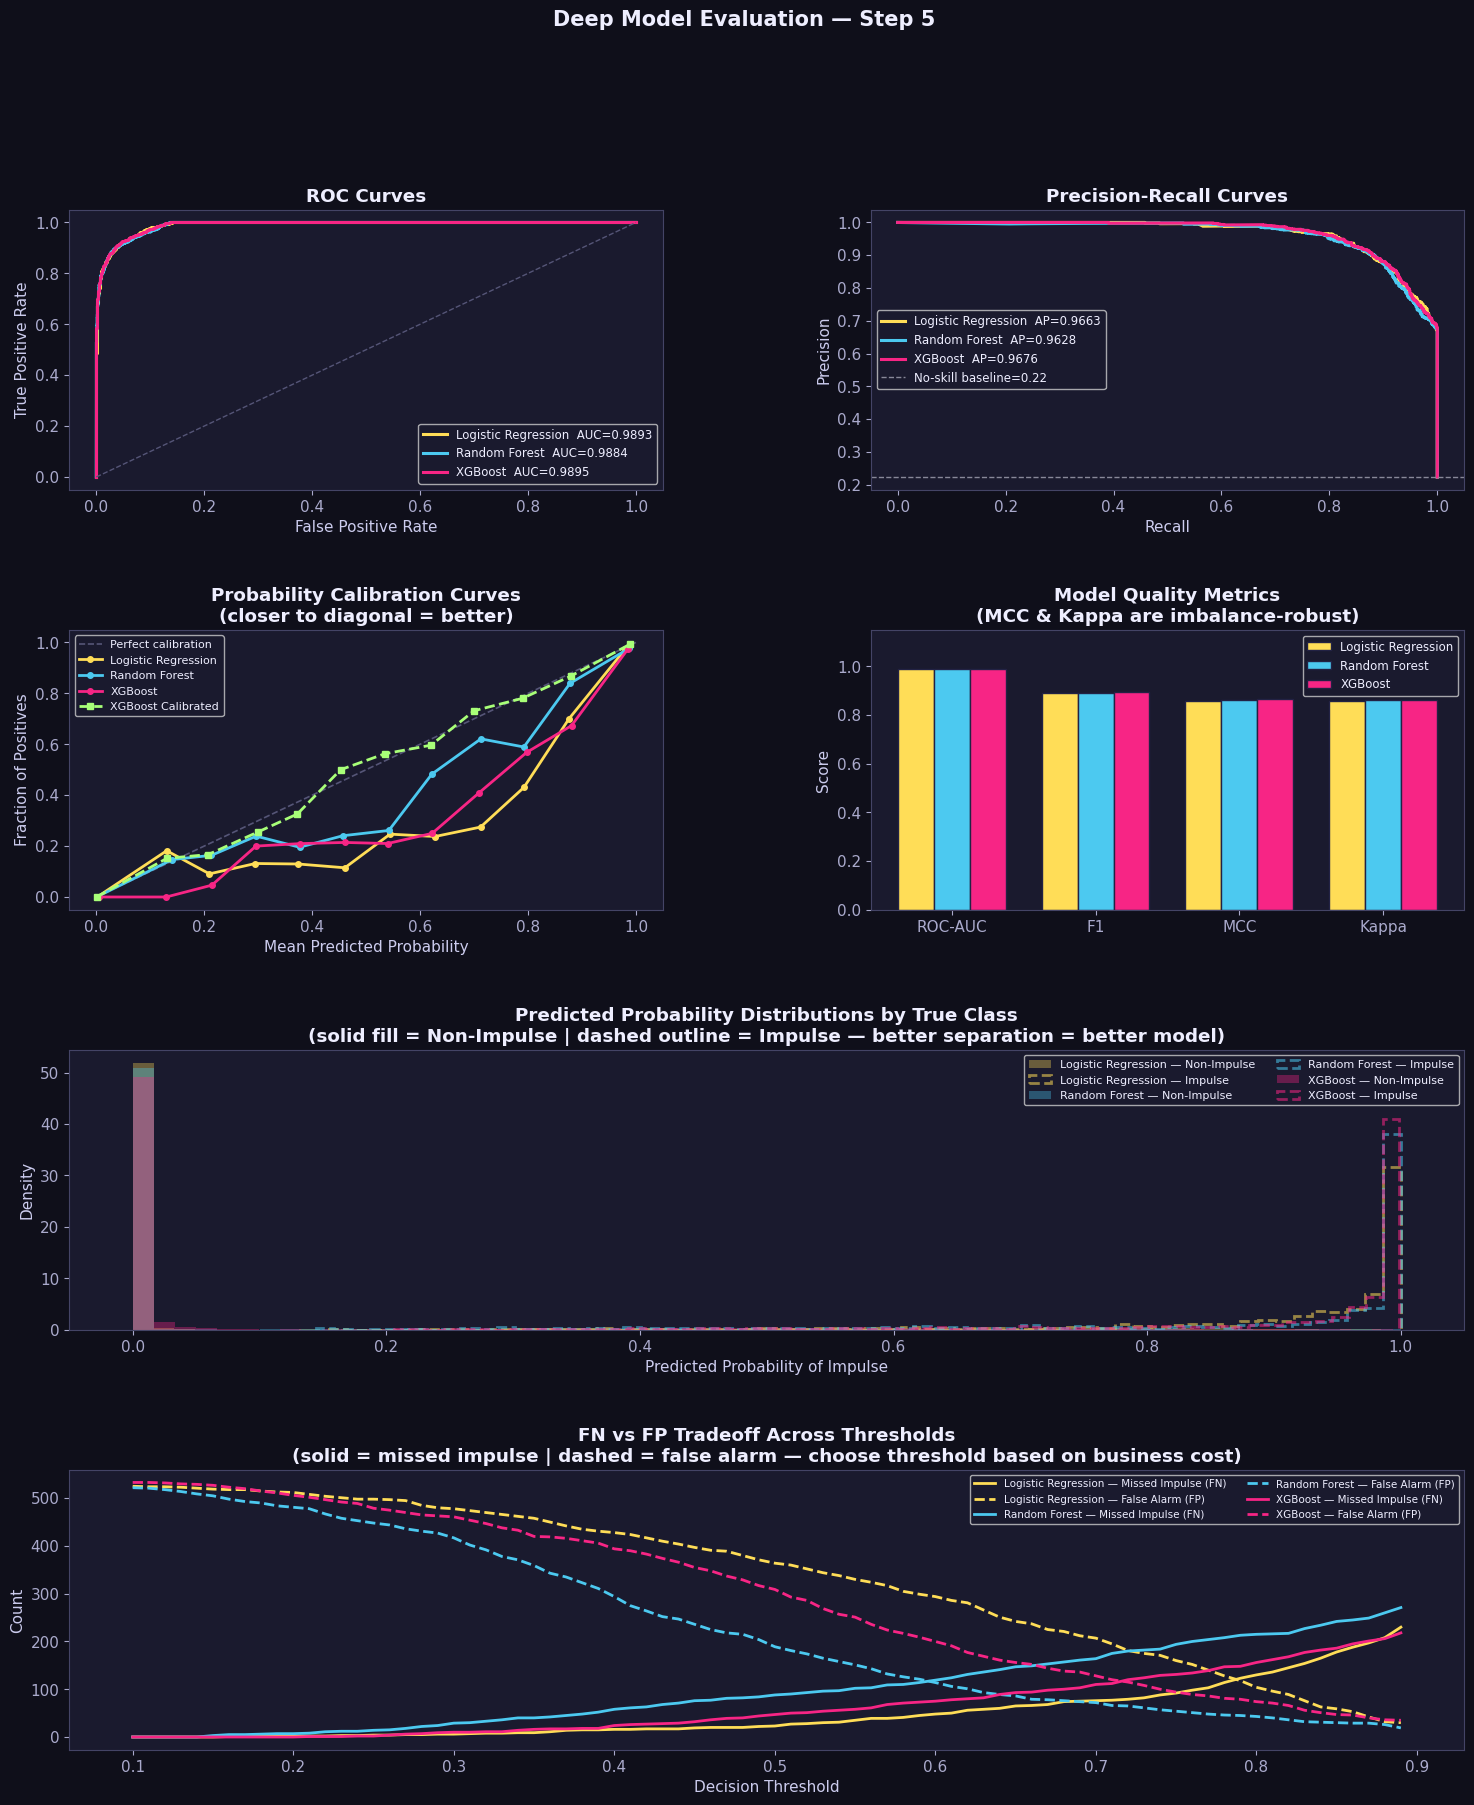


Saved: plot5_deep_evaluation.png
Saved: deep_evaluation.csv
Saved: model_xgb_calibrated.pkl

Step 5 complete. Proceed to STEP 6.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, matthews_corrcoef, cohen_kappa_score,
    precision_score, recall_score, log_loss,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ── 1. Load Everything ────────────────────────────────────────
X_train, X_test, y_train, y_test = joblib.load("train_test_split.pkl")
pipe_lr  = joblib.load("model_lr_baseline.pkl")
best_rf  = joblib.load("model_rf.pkl")
best_xgb = joblib.load("model_xgb.pkl")
thresholds_dict = joblib.load("best_thresholds.pkl")

lr_prob  = pipe_lr.predict_proba(X_test)[:, 1]
rf_prob  = best_rf.predict_proba(X_test)[:, 1]
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

LR_THRESH  = 0.81
RF_THRESH  = thresholds_dict["rf"]
XGB_THRESH = thresholds_dict["xgb"]

lr_pred  = (lr_prob  >= LR_THRESH).astype(int)
rf_pred  = (rf_prob  >= RF_THRESH).astype(int)
xgb_pred = (xgb_prob >= XGB_THRESH).astype(int)

MODEL_COLORS = {
    "Logistic Regression": "#ffdd57",
    "Random Forest":       "#4cc9f0",
    "XGBoost":             "#f72585",
}

models = {
    "Logistic Regression": (lr_prob,  lr_pred,  LR_THRESH),
    "Random Forest":       (rf_prob,  rf_pred,  RF_THRESH),
    "XGBoost":             (xgb_prob, xgb_pred, XGB_THRESH),
}

# ── 2. Comprehensive Metrics Table ───────────────────────────
print("="*75)
print("COMPREHENSIVE EVALUATION METRICS — TEST SET")
print("="*75)

rows = []
for name, (prob, pred, thresh) in models.items():
    rows.append({
        "Model":        name,
        "Threshold":    round(thresh, 2),
        "ROC-AUC":      round(roc_auc_score(y_test, prob), 4),
        "Avg Prec":     round(average_precision_score(y_test, prob), 4),
        "F1":           round(f1_score(y_test, pred), 4),
        "Precision":    round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall":       round(recall_score(y_test, pred, zero_division=0), 4),
        "MCC":          round(matthews_corrcoef(y_test, pred), 4),
        "Kappa":        round(cohen_kappa_score(y_test, pred), 4),
        "Log Loss":     round(log_loss(y_test, prob), 4),
        "Brier Score":  round(brier_score_loss(y_test, prob), 4),
    })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
eval_df.to_csv("deep_evaluation.csv", index=False)

# ── 3. Per-Class Report for Best Model (XGBoost) ─────────────
print("\n--- Detailed Classification Report: XGBoost ---")
print(classification_report(y_test, xgb_pred,
      target_names=["Non-Impulse", "Impulse"], digits=4))

# ── 4. Error Analysis — What Did Each Model Get Wrong? ────────
print("--- Error Analysis ---")
for name, (prob, pred, _) in models.items():
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_rate = fp / (fp + tn) * 100
    fnr_rate = fn / (fn + tp) * 100
    print(f"{name:<22} | FP={fp:>4} ({fpr_rate:.1f}% false alarm) | "
          f"FN={fn:>4} ({fnr_rate:.1f}% missed impulse)")

# ── 5. Probability Calibration ───────────────────────────────
# XGBoost is often overconfident — check if calibration is needed
print("\n--- Calibrating XGBoost with Isotonic Regression ---")
xgb_cal = CalibratedClassifierCV(best_xgb, method="isotonic", cv=3)
xgb_cal.fit(X_train, y_train)
xgb_cal_prob = xgb_cal.predict_proba(X_test)[:, 1]
print(f"Pre-calibration  Brier Score : {brier_score_loss(y_test, xgb_prob):.4f}")
print(f"Post-calibration Brier Score : {brier_score_loss(y_test, xgb_cal_prob):.4f}")
print("(Lower Brier Score = better calibrated probabilities)")

# Save calibrated model for use in risk scoring (Step 7)
joblib.dump(xgb_cal, "model_xgb_calibrated.pkl")

# ── 6. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle("Deep Model Evaluation — Step 5", fontsize=15, fontweight="bold")

# 6a. ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
for name, (prob, _, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2.2,
             label=f"{name}  AUC={auc:.4f}")
ax1.plot([0,1],[0,1], color="#555577", linestyle="--", linewidth=1)
ax1.set_title("ROC Curves", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=8.5)

# 6b. Precision-Recall Curves
ax2 = fig.add_subplot(gs[0, 1])
for name, (prob, _, _) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, color=MODEL_COLORS[name], linewidth=2.2,
             label=f"{name}  AP={ap:.4f}")
ax2.axhline(y_test.mean(), color="#888899", linestyle="--", linewidth=1,
            label=f"No-skill baseline={y_test.mean():.2f}")
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=8.5)

# 6c. Calibration Curves
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot([0,1],[0,1], color="#555577", linestyle="--", linewidth=1.2,
         label="Perfect calibration")
for name, (prob, _, _) in models.items():
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=12)
    ax3.plot(mean_pred, frac_pos, color=MODEL_COLORS[name],
             linewidth=2, marker="o", markersize=4, label=name)
# Also plot calibrated XGBoost
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, xgb_cal_prob, n_bins=12)
ax3.plot(mean_pred_cal, frac_pos_cal, color="#a8ff78",
         linewidth=2, marker="s", markersize=4, linestyle="--",
         label="XGBoost Calibrated")
ax3.set_title("Probability Calibration Curves\n(closer to diagonal = better)", fontweight="bold")
ax3.set_xlabel("Mean Predicted Probability")
ax3.set_ylabel("Fraction of Positives")
ax3.legend(fontsize=8)

# 6d. MCC and Kappa Comparison
ax4 = fig.add_subplot(gs[1, 1])
metric_names  = ["ROC-AUC", "F1", "MCC", "Kappa"]
x             = np.arange(len(metric_names))
width         = 0.25
for i, (name, (prob, pred, _)) in enumerate(models.items()):
    vals = [
        roc_auc_score(y_test, prob),
        f1_score(y_test, pred),
        matthews_corrcoef(y_test, pred),
        cohen_kappa_score(y_test, pred),
    ]
    bars = ax4.bar(x + i * width, vals, width, label=name,
                   color=list(MODEL_COLORS.values())[i], edgecolor="#222244")
ax4.set_xticks(x + width)
ax4.set_xticklabels(metric_names)
ax4.set_ylim(0, 1.15)
ax4.set_title("Model Quality Metrics\n(MCC & Kappa are imbalance-robust)", fontweight="bold")
ax4.set_ylabel("Score")
ax4.legend(fontsize=8.5)

# 6e. Prediction Probability Distributions
ax5 = fig.add_subplot(gs[2, :])
for name, (prob, _, thresh) in models.items():
    ax5.hist(prob[y_test == 0], bins=60, alpha=0.35,
             color=MODEL_COLORS[name], density=True, label=f"{name} — Non-Impulse")
    ax5.hist(prob[y_test == 1], bins=60, alpha=0.55,
             color=MODEL_COLORS[name], density=True, linestyle="--",
             histtype="step", linewidth=2, label=f"{name} — Impulse")
ax5.set_title("Predicted Probability Distributions by True Class\n"
              "(solid fill = Non-Impulse | dashed outline = Impulse — better separation = better model)",
              fontweight="bold")
ax5.set_xlabel("Predicted Probability of Impulse")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8, ncol=2)

# 6f. False Negative vs False Positive Tradeoff
ax6 = fig.add_subplot(gs[3, :])
thrs_range = np.arange(0.1, 0.9, 0.01)
for name, (prob, _, _) in models.items():
    fns = [confusion_matrix(y_test, (prob >= t).astype(int)).ravel()[2]
           for t in thrs_range]
    fps = [confusion_matrix(y_test, (prob >= t).astype(int)).ravel()[1]
           for t in thrs_range]
    ax6.plot(thrs_range, fns, color=MODEL_COLORS[name], linewidth=2,
             label=f"{name} — Missed Impulse (FN)")
    ax6.plot(thrs_range, fps, color=MODEL_COLORS[name], linewidth=2,
             linestyle="--", label=f"{name} — False Alarm (FP)")

ax6.set_title("FN vs FP Tradeoff Across Thresholds\n"
              "(solid = missed impulse | dashed = false alarm — choose threshold based on business cost)",
              fontweight="bold")
ax6.set_xlabel("Decision Threshold")
ax6.set_ylabel("Count")
ax6.legend(fontsize=7.5, ncol=2)

plt.savefig("plot5_deep_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: plot5_deep_evaluation.png")
print("Saved: deep_evaluation.csv")
print("Saved: model_xgb_calibrated.pkl")
print("\nStep 5 complete. Proceed to STEP 6.")

# STEP 6: Feature Importance & SHAP Explainability

In [12]:
%pip install xgboost==1.7.6


  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\maharajaMani\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~gboost\\lib\\xgboost.dll'
Consider using the `--user` option or check the permissions.

You should consider upgrading via the 'c:\Users\maharajaMani\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


[19:24:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

Computing XGBoost native feature importance...

--- Top 15 XGBoost Features (by gain) ---
                        feature  importance
                   spend_zscore    0.165247
                 is_spend_burst    0.158651
       merchant_category_Luxury    0.128175
merchant_category_Entertainment    0.080786
          category_impulse_risk    0.078433
          spend_to_salary_ratio    0.051490
    merchant_category_Utilities    0.049007
    merchant_category

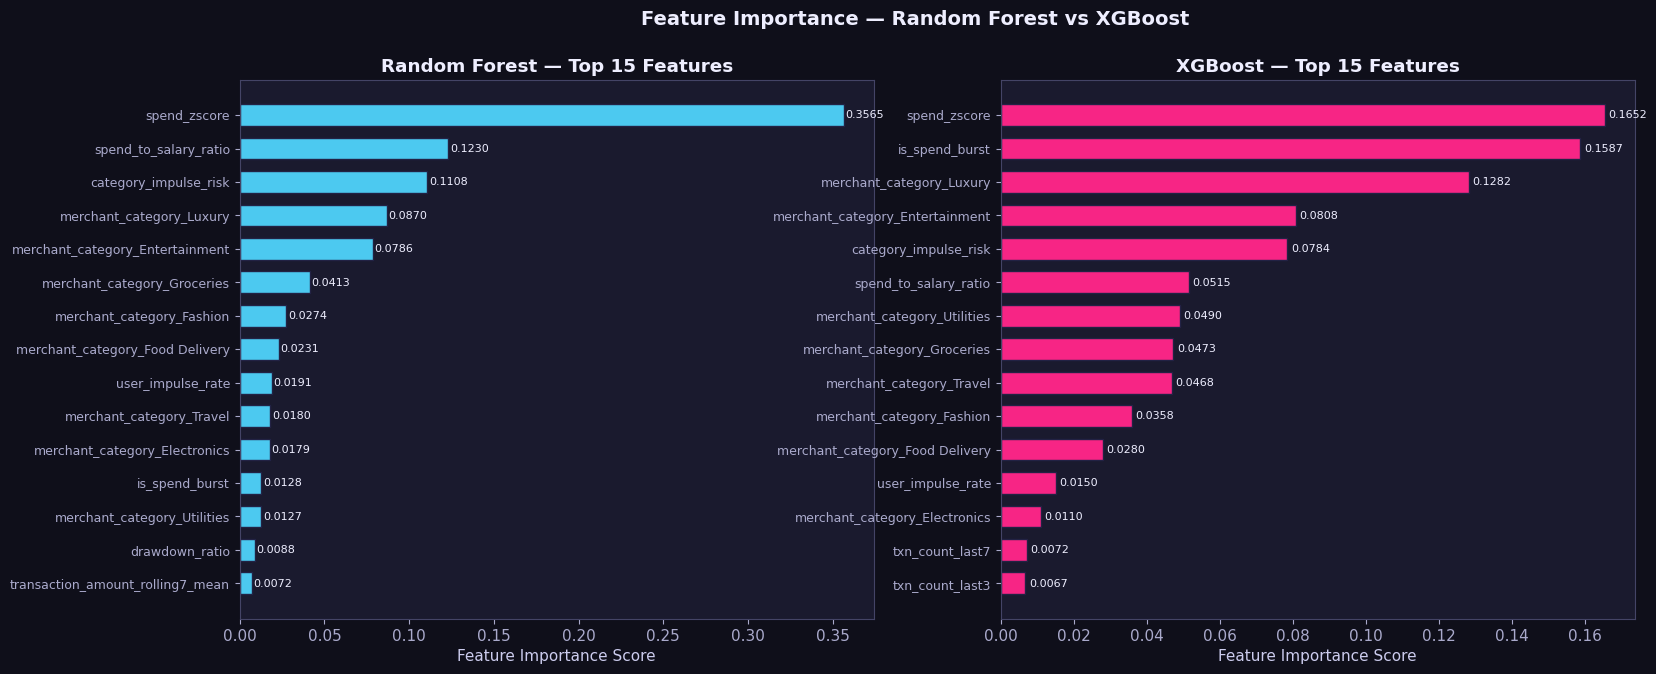

Saved: plot6a_native_importance.png

Generating SHAP beeswarm plot...


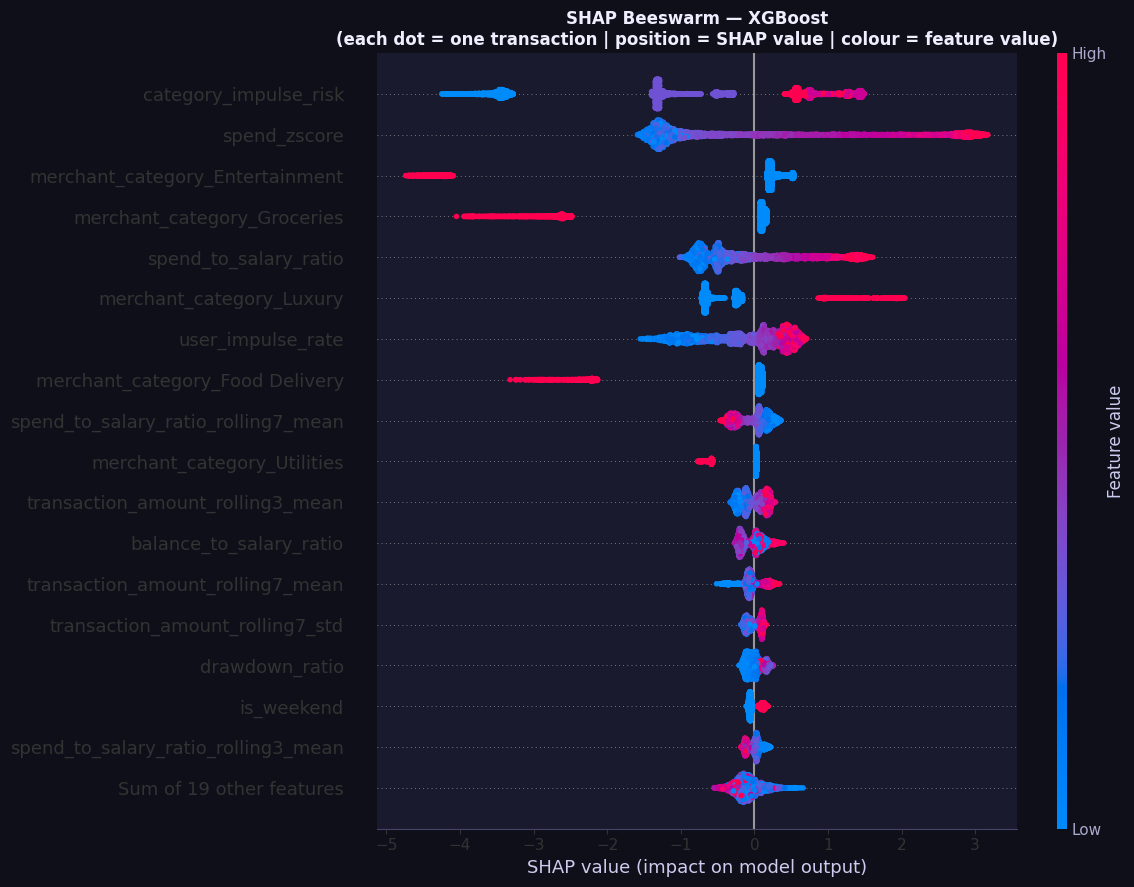

Saved: plot6b_shap_beeswarm.png


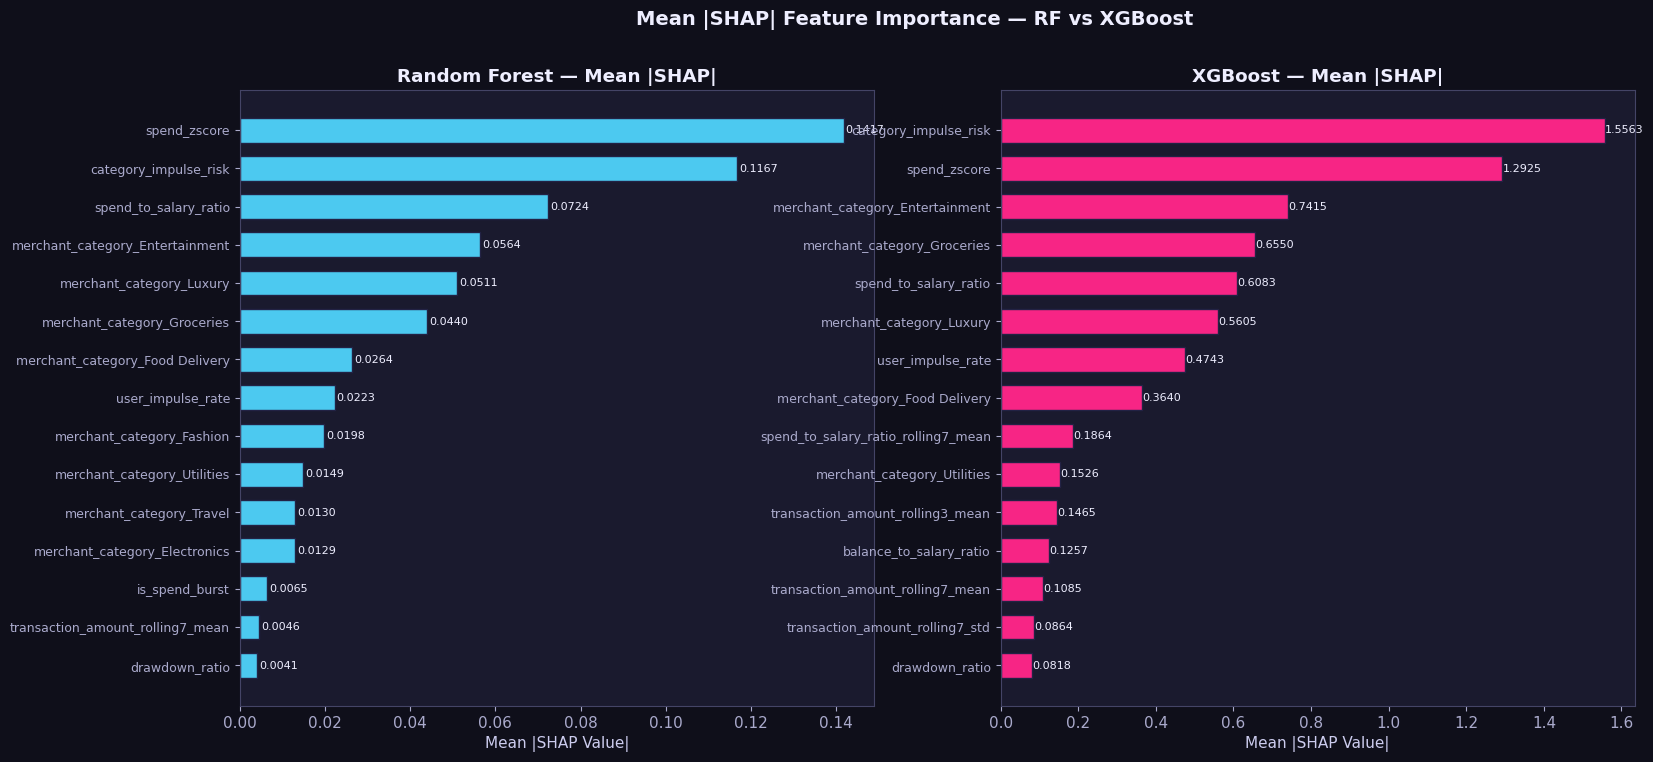

Saved: plot6c_shap_bar_comparison.png


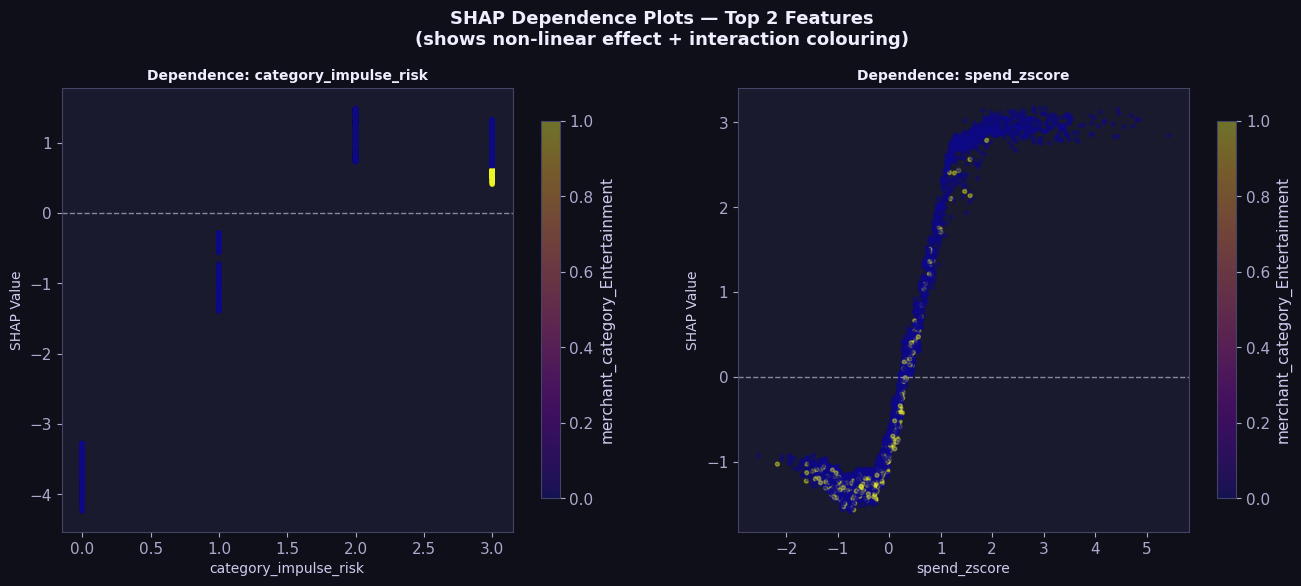

Saved: plot6d_shap_dependence.png


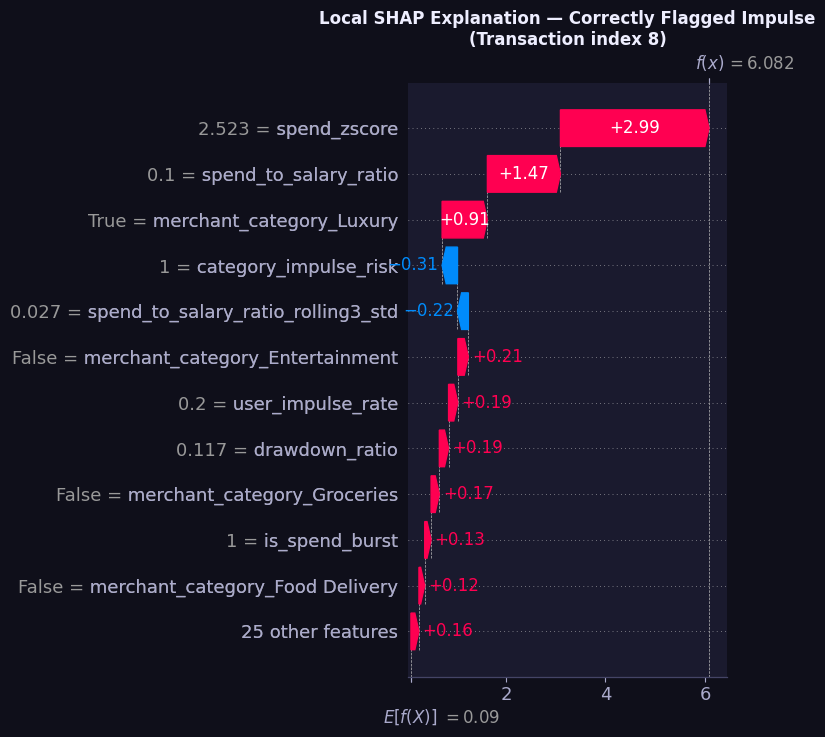

Saved: plot6e_waterfall_Correctly_Flagged_Impulse.png


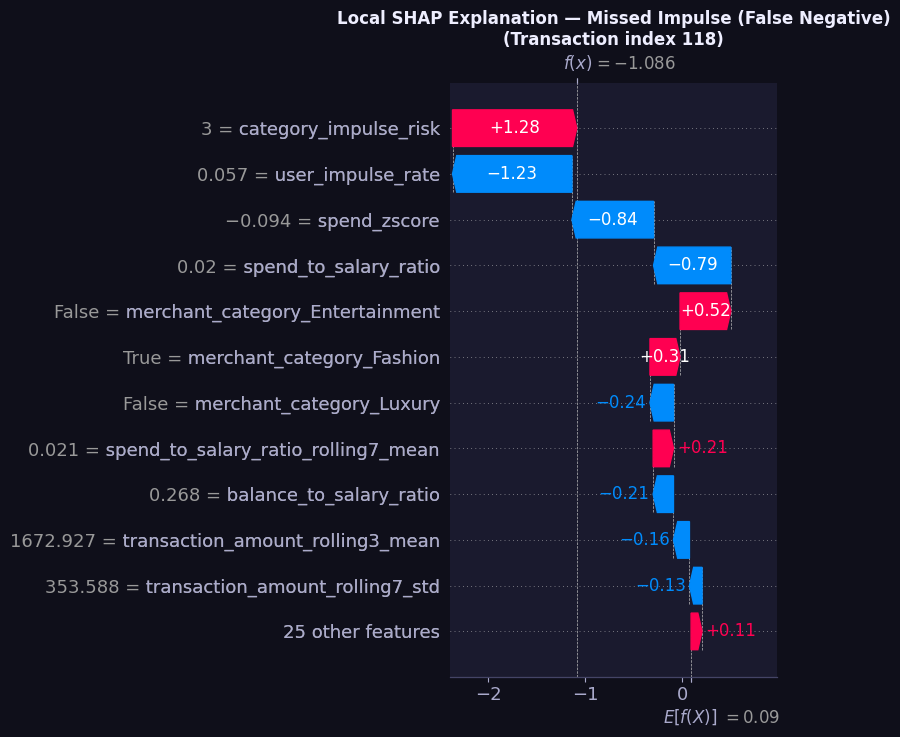

Saved: plot6e_waterfall_Missed_Impulse_False_Negative.png

--- SHAP Rank Consistency: RF vs XGBoost (Top 10) ---
                            feature  rf_rank  xgb_rank  rank_diff
              category_impulse_risk        2         1          1
                       spend_zscore        1         2          1
    merchant_category_Entertainment        4         3          1
        merchant_category_Groceries        6         4          2
              spend_to_salary_ratio        3         5          2
           merchant_category_Luxury        5         6          1
                  user_impulse_rate        8         7          1
    merchant_category_Food Delivery        7         8          1
spend_to_salary_ratio_rolling7_mean       19         9         10
        merchant_category_Utilities       10        10          0

Saved: shap_importance.csv
Saved: shap_rank_consistency.csv

Step 6 complete. Proceed to STEP 7.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import shap
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load Data & Models ─────────────────────────────────────
df = pd.read_csv("df_engineered.csv")

EXCLUDE = [
    "transaction_id", "user_id", "timestamp", "impulse_label",
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X_train, X_test, y_train, y_test = joblib.load("train_test_split.pkl")
best_rf  = joblib.load("model_rf.pkl")
best_xgb = joblib.load("model_xgb.pkl")

# ✅ Fix: Use native booster to avoid sklearn wrapper version conflicts
_booster = best_xgb.get_booster()

def xgb_predict(X):
    """Predict class labels using native booster (bypasses sklearn get_params issues)."""
    dm = xgb.DMatrix(X)
    probs = _booster.predict(dm)
    return (probs > 0.5).astype(int)

# Convert to DataFrame for readable feature names in SHAP
X_test_df  = pd.DataFrame(X_test,  columns=feature_cols)
X_train_df = pd.DataFrame(X_train, columns=feature_cols)

# ── 2. XGBoost Native Feature Importance ─────────────────────
print("Computing XGBoost native feature importance...")
xgb_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("\n--- Top 15 XGBoost Features (by gain) ---")
print(xgb_importance.head(15).to_string(index=False))

# ── 3. Random Forest Feature Importance ──────────────────────
rf_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n--- Top 15 Random Forest Features (by impurity) ---")
print(rf_importance.head(15).to_string(index=False))

# ── 4. SHAP for XGBoost ───────────────────────────────────────
print("\nComputing SHAP values for XGBoost (this may take ~30 seconds)...")
explainer_xgb   = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb(X_test_df)

# Mean absolute SHAP — most reliable global importance measure
shap_mean = pd.DataFrame({
    "feature":       feature_cols,
    "mean_abs_shap": np.abs(shap_values_xgb.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("\n--- Top 15 Features by Mean |SHAP| (XGBoost) ---")
print(shap_mean.head(15).to_string(index=False))
shap_mean.to_csv("shap_importance.csv", index=False)

# ── 5. SHAP for Random Forest ─────────────────────────────────
print("\nComputing SHAP values for Random Forest...")
explainer_rf   = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf(X_test_df)

# ── 6. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

# ── 6a. Native Importance Comparison: RF vs XGB ───────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Importance — Random Forest vs XGBoost", fontsize=14, fontweight="bold")
fig.subplots_adjust(top=0.88)

top_n = 15
for ax, imp_df, name, color in [
    (axes[0], rf_importance,  "Random Forest", "#4cc9f0"),
    (axes[1], xgb_importance, "XGBoost",       "#f72585"),
]:
    plot_df = imp_df.head(top_n).sort_values("importance")
    bars = ax.barh(plot_df["feature"], plot_df["importance"],
                   color=color, edgecolor="#222244", height=0.65)
    ax.set_title(f"{name} — Top {top_n} Features", fontweight="bold")
    ax.set_xlabel("Feature Importance Score")
    ax.tick_params(axis="y", labelsize=9)
    for bar, val in zip(bars, plot_df["importance"]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

plt.savefig("plot6a_native_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot6a_native_importance.png")

# ── 6b. SHAP Beeswarm — XGBoost (global behaviour) ───────────
print("\nGenerating SHAP beeswarm plot...")
fig, ax = plt.subplots(figsize=(12, 9))
shap.plots.beeswarm(
    shap_values_xgb,
    max_display=18,
    show=False,
    color_bar=True,
    plot_size=None
)
plt.title("SHAP Beeswarm — XGBoost\n"
          "(each dot = one transaction | position = SHAP value | "
          "colour = feature value)", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("plot6b_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot6b_shap_beeswarm.png")

# ── 6c. SHAP Bar Summary — RF vs XGB side by side ────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Mean |SHAP| Feature Importance — RF vs XGBoost", fontsize=14, fontweight="bold")
fig.subplots_adjust(top=0.88)

for ax, shap_vals, name, color in [
    (axes[0], shap_values_rf,  "Random Forest", "#4cc9f0"),
    (axes[1], shap_values_xgb, "XGBoost",       "#f72585"),
]:
    raw = shap_vals.values
    if raw.ndim == 3:
        raw = raw[:, :, 1]  # RF: take class 1 (impulse)

    mean_shap = pd.DataFrame({
        "feature":       feature_cols,
        "mean_abs_shap": np.abs(raw).mean(axis=0)
    }).sort_values("mean_abs_shap").tail(15)

    bars = ax.barh(mean_shap["feature"], mean_shap["mean_abs_shap"],
                   color=color, edgecolor="#222244", height=0.65)
    ax.set_title(f"{name} — Mean |SHAP|", fontweight="bold")
    ax.set_xlabel("Mean |SHAP Value|")
    ax.tick_params(axis="y", labelsize=9)
    for bar, val in zip(bars, mean_shap["mean_abs_shap"]):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

plt.savefig("plot6c_shap_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot6c_shap_bar_comparison.png")

# ── 6d. SHAP Dependence Plots — Top 2 Features ───────────────
top2 = shap_mean["feature"].iloc[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("SHAP Dependence Plots — Top 2 Features\n"
             "(shows non-linear effect + interaction colouring)",
             fontsize=13, fontweight="bold")
fig.subplots_adjust(top=0.85)

for ax, feat in zip(axes, top2):
    feat_idx      = feature_cols.index(feat)
    shap_col      = shap_values_xgb.values[:, feat_idx]
    feat_vals     = X_test_df[feat].values
    interact_feat = shap_mean["feature"].iloc[2]
    color_vals    = X_test_df[interact_feat].values

    sc = ax.scatter(feat_vals, shap_col, c=color_vals, cmap="plasma",
                    alpha=0.4, s=8, rasterized=True)
    plt.colorbar(sc, ax=ax, label=interact_feat, shrink=0.85)
    ax.axhline(0, color="#888899", linewidth=1, linestyle="--")
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SHAP Value", fontsize=10)
    ax.set_title(f"Dependence: {feat}", fontweight="bold", fontsize=10)

plt.savefig("plot6d_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot6d_shap_dependence.png")

# ── 6e. Local Explanation — Single Transaction Waterfall ──────
# ✅ Fix: use xgb_predict() instead of best_xgb.predict() to avoid sklearn wrapper crash
preds = xgb_predict(X_test)
impulse_idx = np.where((y_test.values == 1) & (preds == 1))[0][0]
missed_idx  = np.where((y_test.values == 1) & (preds == 0))[0][0]

for idx, label in [(impulse_idx, "Correctly Flagged Impulse"),
                   (missed_idx,  "Missed Impulse (False Negative)")]:
    fig, ax = plt.subplots(figsize=(12, 7))
    shap.plots.waterfall(shap_values_xgb[idx], max_display=12, show=False)
    plt.title(f"Local SHAP Explanation — {label}\n"
              f"(Transaction index {idx})",
              fontweight="bold", fontsize=12)
    plt.tight_layout()
    safe_label = label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"plot6e_waterfall_{safe_label}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: plot6e_waterfall_{safe_label}.png")

# ── 7. SHAP Consistency Check Across Models ──────────────────
rf_raw = shap_values_rf.values
if rf_raw.ndim == 3:
    rf_raw = rf_raw[:, :, 1]

print("\n--- SHAP Rank Consistency: RF vs XGBoost (Top 10) ---")
rf_shap_rank = pd.DataFrame({
    "feature": feature_cols,
    "rf_rank": np.abs(rf_raw).mean(axis=0)
}).sort_values("rf_rank", ascending=False).reset_index(drop=True)
rf_shap_rank["rf_rank"] = rf_shap_rank.index + 1

xgb_shap_rank = shap_mean.reset_index(drop=True)
xgb_shap_rank["xgb_rank"] = xgb_shap_rank.index + 1

rank_df = rf_shap_rank[["feature", "rf_rank"]].merge(
    xgb_shap_rank[["feature", "xgb_rank"]], on="feature"
).sort_values("xgb_rank").head(10)
rank_df["rank_diff"] = (rank_df["rf_rank"] - rank_df["xgb_rank"]).abs()
print(rank_df.to_string(index=False))
rank_df.to_csv("shap_rank_consistency.csv", index=False)

print("\nSaved: shap_importance.csv")
print("Saved: shap_rank_consistency.csv")
print("\nStep 6 complete. Proceed to STEP 7.")


# STEP 7: User-Level Risk Score Construction

[19:27:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[19:27:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  

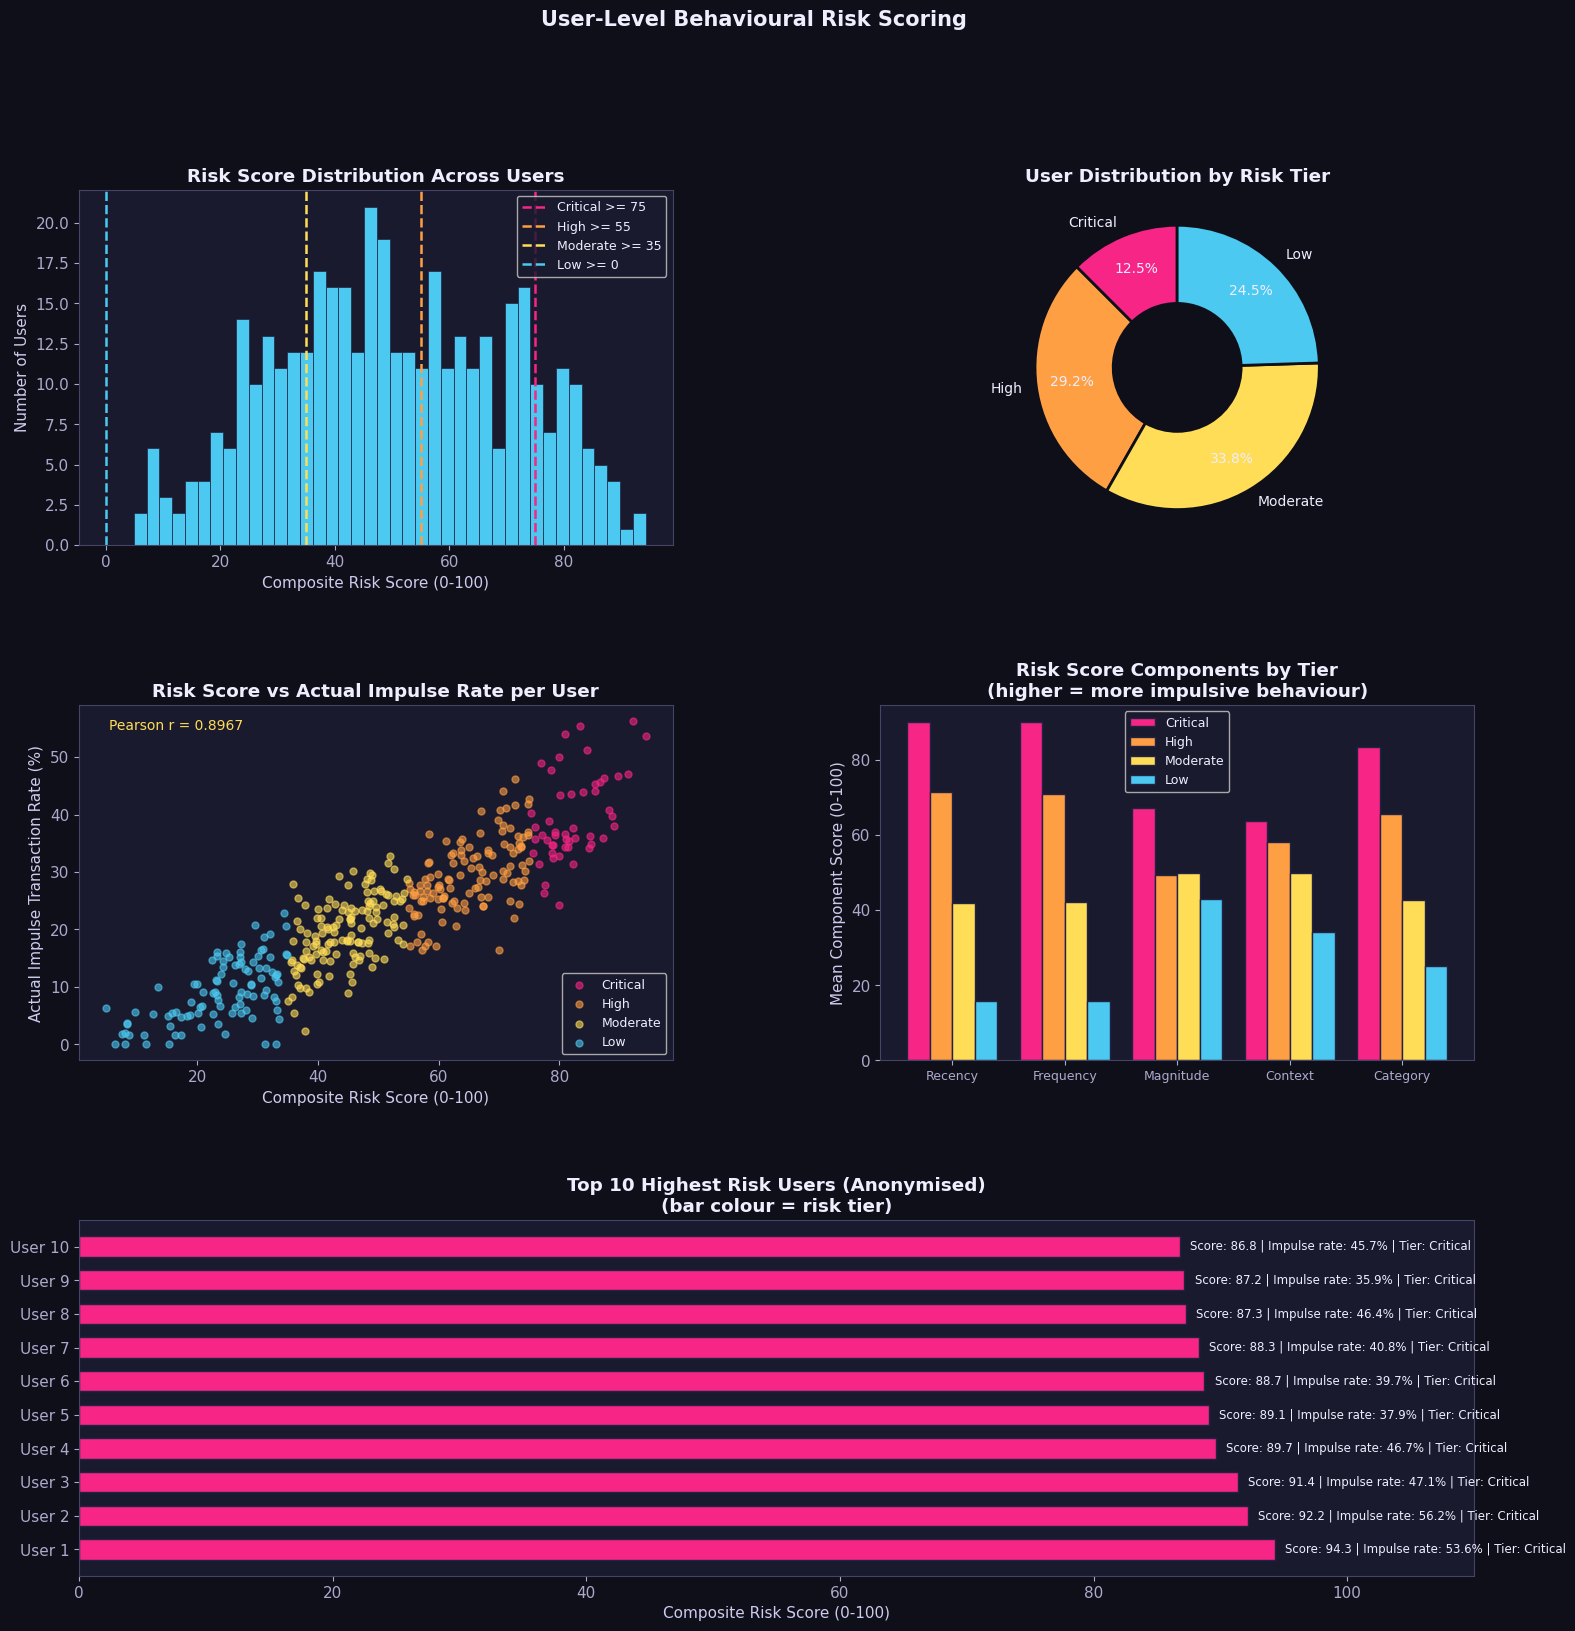


Saved: plot7_user_risk_scores.png
Saved: user_risk_profiles.csv
Saved: tier_summary.csv

Step 7 complete. Proceed to STEP 8.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load Data & Model ──────────────────────────────────────
df = pd.read_csv("df_engineered.csv", parse_dates=["timestamp"])

EXCLUDE = [
    "transaction_id", "user_id", "timestamp", "impulse_label",
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

xgb_cal  = joblib.load("model_xgb_calibrated.pkl")
X_all    = df[feature_cols].fillna(0)

# ── 2. Predict Impulse Probability for Every Transaction ──────
import xgboost as xgb

_cal_booster = xgb_cal.calibrated_classifiers_[0].estimator.get_booster()
_dmat = xgb.DMatrix(X_all)
df["impulse_prob"] = _cal_booster.predict(_dmat)   # native booster returns probs directly
df["impulse_pred"] = (df["impulse_prob"] >= 0.70).astype(int)


print(f"Transactions scored : {len(df):,}")
print(f"Predicted impulse   : {df['impulse_pred'].sum():,} "
      f"({df['impulse_pred'].mean()*100:.1f}%)")

# ── 3. Recency-Weighted Impulse Probability ───────────────────
# Exponential decay: transactions older than 30 days get lower weight
# half-life = 15 days meaning weight halves every 15 days

HALF_LIFE_DAYS = 15
ref_date = df["timestamp"].max()

df["days_ago"] = (ref_date - df["timestamp"]).dt.days
df["decay_weight"] = np.exp(-np.log(2) * df["days_ago"] / HALF_LIFE_DAYS)

def weighted_mean(group):
    return np.average(group["impulse_prob"], weights=group["decay_weight"])

# ── 4. User-Level Aggregation ─────────────────────────────────
print("\nAggregating user-level behavioural profiles...")

user_agg = df.groupby("user_id").agg(
    total_transactions      = ("impulse_prob",   "count"),
    impulse_txn_count       = ("impulse_pred",   "sum"),
    raw_impulse_rate        = ("impulse_label",  "mean"),   # ground truth rate
    pred_impulse_rate       = ("impulse_pred",   "mean"),   # model predicted rate
    mean_impulse_prob       = ("impulse_prob",   "mean"),
    max_impulse_prob        = ("impulse_prob",   "max"),
    impulse_prob_std        = ("impulse_prob",   "std"),    # consistency index
    mean_spend_zscore       = ("spend_zscore",   "mean"),
    mean_salary_ratio       = ("spend_to_salary_ratio", "mean"),
    late_night_rate         = ("is_late_night",  "mean"),
    weekend_rate            = ("is_weekend",     "mean"),
    mean_category_risk      = ("category_impulse_risk", "mean"),
    mean_drawdown           = ("drawdown_ratio", "mean"),
    balance_stress_rate     = ("balance_stress", "mean"),
).reset_index()

# Recency-weighted impulse probability (computed separately)
recency_scores = (
    df.groupby("user_id")
      .apply(weighted_mean)
      .reset_index()
)
recency_scores.columns = ["user_id", "recency_weighted_prob"]
user_agg = user_agg.merge(recency_scores, on="user_id")

# ── 5. Composite Risk Score (0-100) ───────────────────────────
# Weighted combination of behavioural signals — weights reflect
# theoretical and empirical importance from SHAP Step 6

def percentile_scale(series):
    """Convert any series to 0-100 percentile rank."""
    return series.rank(pct=True) * 100

# Component scores (each 0-100)
user_agg["score_recency"]    = percentile_scale(user_agg["recency_weighted_prob"])
user_agg["score_frequency"]  = percentile_scale(user_agg["pred_impulse_rate"])
user_agg["score_magnitude"]  = percentile_scale(user_agg["mean_spend_zscore"])
user_agg["score_context"]    = percentile_scale(
    user_agg["late_night_rate"] * 0.5 + user_agg["weekend_rate"] * 0.3 +
    user_agg["balance_stress_rate"] * 0.2
)
user_agg["score_category"]   = percentile_scale(user_agg["mean_category_risk"])

# Composite score — weights informed by SHAP importance ranking
WEIGHTS = {
    "score_recency":   0.35,   # most important: recent behaviour predicts future
    "score_frequency": 0.25,   # how often does this user impulse buy?
    "score_magnitude": 0.20,   # how anomalous are their spends?
    "score_context":   0.10,   # when do they transact (vulnerability context)?
    "score_category":  0.10,   # what categories do they buy in?
}

user_agg["risk_score"] = sum(
    user_agg[col] * w for col, w in WEIGHTS.items()
)

# ── 6. Risk Tier Segmentation ─────────────────────────────────
def assign_tier(score):
    if score >= 75:   return "Critical"
    elif score >= 55: return "High"
    elif score >= 35: return "Moderate"
    else:             return "Low"

user_agg["risk_tier"] = user_agg["risk_score"].apply(assign_tier)

tier_order  = ["Critical", "High", "Moderate", "Low"]
tier_colors = {"Critical": "#f72585", "High": "#ff9f43",
               "Moderate": "#ffdd57", "Low": "#4cc9f0"}

# ── 7. Risk Tier Summary ──────────────────────────────────────
print("\n" + "="*65)
print("USER RISK TIER SUMMARY")
print("="*65)

tier_summary = user_agg.groupby("risk_tier").agg(
    user_count          = ("user_id",              "count"),
    avg_risk_score      = ("risk_score",           "mean"),
    avg_impulse_rate    = ("raw_impulse_rate",      "mean"),
    avg_late_night_rate = ("late_night_rate",       "mean"),
    avg_salary_ratio    = ("mean_salary_ratio",     "mean"),
    avg_balance_stress  = ("balance_stress_rate",   "mean"),
).round(3)

tier_summary = tier_summary.reindex(
    [t for t in tier_order if t in tier_summary.index]
)
print(tier_summary.to_string())

user_agg.to_csv("user_risk_profiles.csv", index=False)
tier_summary.to_csv("tier_summary.csv", index=False)

# ── 8. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("User-Level Behavioural Risk Scoring", fontsize=15, fontweight="bold")

# 8a. Risk Score Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(user_agg["risk_score"], bins=40, color="#4cc9f0",
         edgecolor="#222244", linewidth=0.5)
for tier, color in tier_colors.items():
    thresholds = {"Critical": 75, "High": 55, "Moderate": 35, "Low": 0}
    ax1.axvline(thresholds[tier], color=color, linewidth=1.8,
                linestyle="--", label=f"{tier} >= {thresholds[tier]}")
ax1.set_title("Risk Score Distribution Across Users", fontweight="bold")
ax1.set_xlabel("Composite Risk Score (0-100)")
ax1.set_ylabel("Number of Users")
ax1.legend(fontsize=9)

# 8b. Tier Population Donut Chart
ax2 = fig.add_subplot(gs[0, 1])
tier_counts = user_agg["risk_tier"].value_counts().reindex(tier_order).dropna()
colors_list = [tier_colors[t] for t in tier_counts.index]
wedges, texts, autotexts = ax2.pie(
    tier_counts.values,
    labels=tier_counts.index,
    colors=colors_list,
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "#0f0f1a", "linewidth": 2}
)
for t in texts + autotexts:
    t.set_color("#eeeeff")
    t.set_fontsize(10)
ax2.set_title("User Distribution by Risk Tier", fontweight="bold")

# 8c. Risk Score vs Actual Impulse Rate (scatter)
ax3 = fig.add_subplot(gs[1, 0])
for tier in tier_order:
    subset = user_agg[user_agg["risk_tier"] == tier]
    ax3.scatter(subset["risk_score"], subset["raw_impulse_rate"] * 100,
                color=tier_colors[tier], alpha=0.6, s=25, label=tier)
ax3.set_title("Risk Score vs Actual Impulse Rate per User", fontweight="bold")
ax3.set_xlabel("Composite Risk Score (0-100)")
ax3.set_ylabel("Actual Impulse Transaction Rate (%)")
ax3.legend(fontsize=9)

# Correlation annotation
corr = user_agg["risk_score"].corr(user_agg["raw_impulse_rate"])
ax3.text(0.05, 0.93, f"Pearson r = {corr:.4f}", transform=ax3.transAxes,
         fontsize=10, color="#ffdd57")

# 8d. Behavioural Component Radar — Average per Tier
ax4 = fig.add_subplot(gs[1, 1])
component_cols = ["score_recency", "score_frequency",
                  "score_magnitude", "score_context", "score_category"]
component_labels = ["Recency", "Frequency", "Magnitude", "Context", "Category"]

tier_means = user_agg.groupby("risk_tier")[component_cols].mean().reindex(tier_order)
x = np.arange(len(component_labels))
width = 0.2

for i, tier in enumerate(tier_order):
    if tier not in tier_means.index:
        continue
    vals = tier_means.loc[tier].values
    ax4.bar(x + i * width, vals, width, label=tier,
            color=tier_colors[tier], edgecolor="#222244")

ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(component_labels, fontsize=9)
ax4.set_title("Risk Score Components by Tier\n(higher = more impulsive behaviour)",
              fontweight="bold")
ax4.set_ylabel("Mean Component Score (0-100)")
ax4.legend(fontsize=9)

# 8e. Top 10 Highest Risk Users (anonymised)
ax5 = fig.add_subplot(gs[2, :])
top_users = user_agg.nlargest(10, "risk_score").copy()
top_users["user_label"] = [f"User {i+1}" for i in range(len(top_users))]

bar_colors = [tier_colors[t] for t in top_users["risk_tier"]]
bars = ax5.barh(top_users["user_label"], top_users["risk_score"],
                color=bar_colors, edgecolor="#222244", height=0.6)
ax5.set_title("Top 10 Highest Risk Users (Anonymised)\n"
              "(bar colour = risk tier)", fontweight="bold")
ax5.set_xlabel("Composite Risk Score (0-100)")
ax5.set_xlim(0, 110)

for bar, (_, row) in zip(bars, top_users.iterrows()):
    ax5.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
             f"Score: {row['risk_score']:.1f} | "
             f"Impulse rate: {row['raw_impulse_rate']*100:.1f}% | "
             f"Tier: {row['risk_tier']}",
             va="center", fontsize=8.5)

plt.savefig("plot7_user_risk_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: plot7_user_risk_scores.png")
print("Saved: user_risk_profiles.csv")
print("Saved: tier_summary.csv")
print("\nStep 7 complete. Proceed to STEP 8.")

# STEP 8: Behavioural Clustering — KMeans Persona Profiling

Users loaded: 400
Computing elbow and silhouette scores...
Elbow method suggests     : k = 7
Best silhouette score at  : k = 2  (score = 0.2143)
Using k = 2

CLUSTER PROFILES (Z-SCORES RELATIVE TO POPULATION)
         pred_impulse_rate  mean_spend_zscore  late_night_rate  weekend_rate  mean_category_risk  mean_salary_ratio  balance_stress_rate  impulse_prob_std  mean_drawdown  recency_weighted_prob
cluster                                                                                                                                                                                         
0                   -0.779              0.013            0.079        -0.243              -0.583             -0.514               -0.632            -0.754         -0.034                 -0.758
1                    0.663             -0.011           -0.067         0.207               0.496              0.437                0.538             0.643          0.029                  0.646

CLUSTER RAW MEANS 

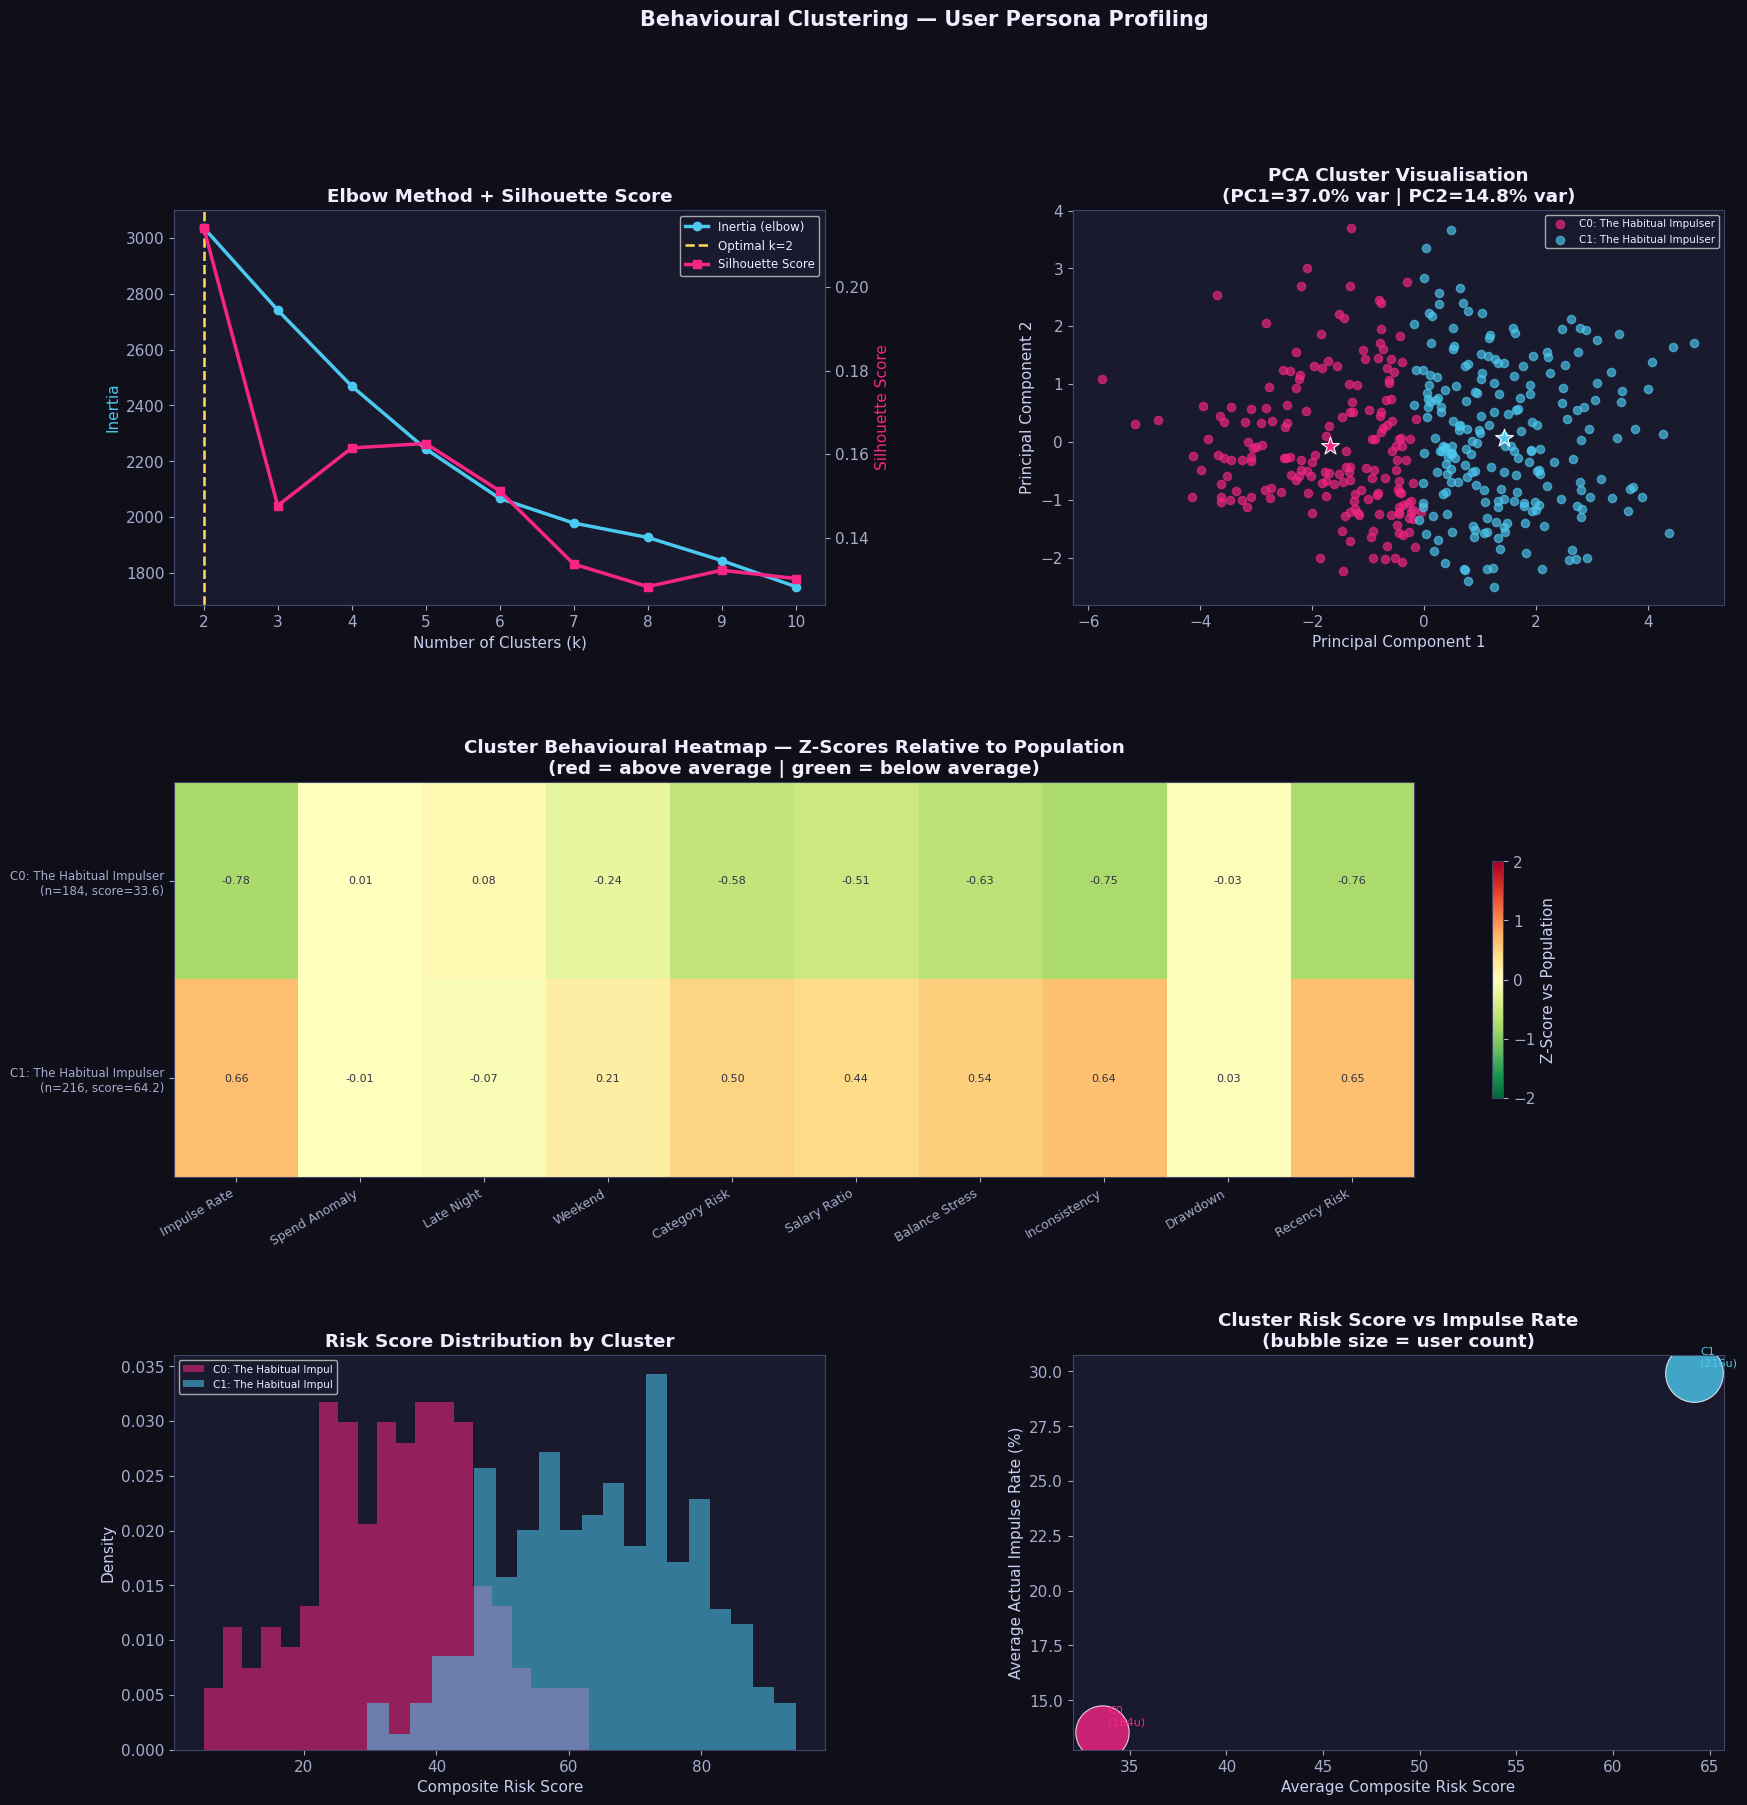


Saved: plot8_clustering.png
Saved: user_risk_profiles.csv  (updated with cluster + persona)
Saved: persona_summary.csv
Saved: model_kmeans.pkl

Step 8 complete. Proceed to STEP 9.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── 1. Load User Risk Profiles ────────────────────────────────
user_agg = pd.read_csv("user_risk_profiles.csv")
print(f"Users loaded: {len(user_agg)}")

# ── 2. Select Clustering Features ────────────────────────────
# Use behavioural dimensions only — not the derived score itself
cluster_features = [
    "pred_impulse_rate",       # how often they impulse buy
    "mean_spend_zscore",       # how anomalous their spends are
    "late_night_rate",         # when they transact
    "weekend_rate",            # weekend behaviour
    "mean_category_risk",      # what they buy
    "mean_salary_ratio",       # relative spend size
    "balance_stress_rate",     # financial pressure context
    "impulse_prob_std",        # consistency vs binge pattern
    "mean_drawdown",           # how much of balance they consume
    "recency_weighted_prob",   # recent impulse tendency
]

X_cluster = user_agg[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# ── 3. Optimal Cluster Count — Elbow + Silhouette ─────────────
print("Computing elbow and silhouette scores...")
inertias    = []
sil_scores  = []
k_range     = range(2, 11)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

# Find elbow via second derivative
deltas      = np.diff(inertias)
accel       = np.diff(deltas)
elbow_k     = k_range[np.argmax(accel) + 2]
sil_best_k  = k_range[np.argmax(sil_scores)]

print(f"Elbow method suggests     : k = {elbow_k}")
print(f"Best silhouette score at  : k = {sil_best_k}  "
      f"(score = {max(sil_scores):.4f})")

# Use silhouette-optimal k — more statistically rigorous
OPTIMAL_K = sil_best_k
print(f"Using k = {OPTIMAL_K}")

# ── 4. Final KMeans Fit ───────────────────────────────────────
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
user_agg["cluster"] = km_final.fit_predict(X_scaled)

joblib.dump(km_final, "model_kmeans.pkl")
joblib.dump(scaler,   "scaler_kmeans.pkl")

# ── 5. Cluster Profiling ──────────────────────────────────────
cluster_profile = user_agg.groupby("cluster")[cluster_features + ["risk_score"]].mean()
cluster_counts  = user_agg["cluster"].value_counts().sort_index()
cluster_profile["user_count"] = cluster_counts

# Standardise profile relative to population mean for radar interpretation
pop_mean = X_cluster.mean()
pop_std  = X_cluster.std().replace(0, 1)
cluster_profile_z = (cluster_profile[cluster_features] - pop_mean) / pop_std

print("\n" + "="*70)
print("CLUSTER PROFILES (Z-SCORES RELATIVE TO POPULATION)")
print("="*70)
print(cluster_profile_z.round(3).to_string())

print("\n" + "="*70)
print("CLUSTER RAW MEANS + RISK SCORE")
print("="*70)
print(cluster_profile[cluster_features + ["risk_score", "user_count"]].round(3).to_string())

# ── 6. Assign Persona Names Based on Dominant Z-Score Signal ──
def assign_persona(row):
    z = cluster_profile_z.loc[row["cluster"]]
    dominant = z.abs().idxmax()
    persona_map = {
        "late_night_rate":       "The Night Owl Splurger",
        "weekend_rate":          "The Weekend Binge Buyer",
        "mean_spend_zscore":     "The Burst Spender",
        "balance_stress_rate":   "The Financially Stressed Impulser",
        "mean_category_risk":    "The Hedonic Category Shopper",
        "pred_impulse_rate":     "The Habitual Impulser",
        "mean_salary_ratio":     "The Salary Burner",
        "impulse_prob_std":      "The Unpredictable Splurger",
        "recency_weighted_prob": "The Escalating Risk User",
        "mean_drawdown":         "The Balance Drainer",
    }
    return persona_map.get(dominant, f"Cluster {row['cluster']}")

user_agg["persona"] = user_agg.apply(assign_persona, axis=1)

persona_summary = user_agg.groupby(["cluster", "persona"]).agg(
    user_count      = ("user_id",          "count"),
    avg_risk_score  = ("risk_score",       "mean"),
    avg_impulse_rate= ("raw_impulse_rate", "mean"),
).round(3).reset_index()

print("\n" + "="*70)
print("PERSONA SUMMARY")
print("="*70)
print(persona_summary.to_string(index=False))

user_agg.to_csv("user_risk_profiles.csv", index=False)
persona_summary.to_csv("persona_summary.csv", index=False)

# ── 7. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

CLUSTER_PALETTE = [
    "#f72585", "#4cc9f0", "#7bed9f", "#ffdd57",
    "#a29bfe", "#fd79a8", "#00cec9", "#e17055",
    "#6c5ce7", "#55efc4"
][:OPTIMAL_K]

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle("Behavioural Clustering — User Persona Profiling", fontsize=15, fontweight="bold")

# 7a. Elbow + Silhouette
ax1 = fig.add_subplot(gs[0, 0])
ax1b = ax1.twinx()
ax1.plot(list(k_range), inertias, color="#4cc9f0", linewidth=2.5,
         marker="o", markersize=6, label="Inertia (elbow)")
ax1b.plot(list(k_range), sil_scores, color="#f72585", linewidth=2.5,
          marker="s", markersize=6, label="Silhouette Score")
ax1.axvline(OPTIMAL_K, color="#ffdd57", linestyle="--", linewidth=1.8,
            label=f"Optimal k={OPTIMAL_K}")
ax1.set_title("Elbow Method + Silhouette Score", fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="#4cc9f0")
ax1b.set_ylabel("Silhouette Score", color="#f72585")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5)

# 7b. PCA 2D Cluster Visualisation
ax2 = fig.add_subplot(gs[0, 1])
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

for c in range(OPTIMAL_K):
    mask = user_agg["cluster"] == c
    persona = user_agg.loc[mask, "persona"].iloc[0]
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=CLUSTER_PALETTE[c], alpha=0.65, s=35,
                label=f"C{c}: {persona}")
    # Cluster centroid marker
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax2.scatter(cx, cy, color=CLUSTER_PALETTE[c], s=180,
                marker="*", edgecolors="white", linewidths=0.8, zorder=5)

ax2.set_title(f"PCA Cluster Visualisation\n"
              f"(PC1={var_explained[0]:.1f}% var | PC2={var_explained[1]:.1f}% var)",
              fontweight="bold")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
ax2.legend(fontsize=7.5, loc="best")

# 7c. Cluster Heatmap — Z-Score Profile
ax3 = fig.add_subplot(gs[1, :])
short_names = {
    "pred_impulse_rate":      "Impulse Rate",
    "mean_spend_zscore":      "Spend Anomaly",
    "late_night_rate":        "Late Night",
    "weekend_rate":           "Weekend",
    "mean_category_risk":     "Category Risk",
    "mean_salary_ratio":      "Salary Ratio",
    "balance_stress_rate":    "Balance Stress",
    "impulse_prob_std":       "Inconsistency",
    "mean_drawdown":          "Drawdown",
    "recency_weighted_prob":  "Recency Risk",
}
z_plot = cluster_profile_z.rename(columns=short_names)
row_labels = [
    f"C{i}: {user_agg[user_agg['cluster']==i]['persona'].iloc[0]}\n"
    f"(n={cluster_counts[i]}, score={cluster_profile.loc[i,'risk_score']:.1f})"
    for i in range(OPTIMAL_K)
]

im = ax3.imshow(z_plot.values, cmap="RdYlGn_r", aspect="auto",
                vmin=-2, vmax=2)
plt.colorbar(im, ax=ax3, shrink=0.6, label="Z-Score vs Population")
ax3.set_xticks(range(len(z_plot.columns)))
ax3.set_xticklabels(z_plot.columns, rotation=30, ha="right", fontsize=9)
ax3.set_yticks(range(OPTIMAL_K))
ax3.set_yticklabels(row_labels, fontsize=8.5)
ax3.set_title("Cluster Behavioural Heatmap — Z-Scores Relative to Population\n"
              "(red = above average | green = below average)", fontweight="bold")

for i in range(OPTIMAL_K):
    for j in range(len(z_plot.columns)):
        val = z_plot.values[i, j]
        ax3.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=8, color="white" if abs(val) > 1 else "#333344")

# 7d. Risk Score Distribution per Cluster
ax4 = fig.add_subplot(gs[2, 0])
for c in range(OPTIMAL_K):
    subset  = user_agg[user_agg["cluster"] == c]["risk_score"]
    persona = user_agg[user_agg["cluster"] == c]["persona"].iloc[0]
    ax4.hist(subset, bins=20, alpha=0.55, color=CLUSTER_PALETTE[c],
             label=f"C{c}: {persona[:18]}", edgecolor="none", density=True)
ax4.set_title("Risk Score Distribution by Cluster", fontweight="bold")
ax4.set_xlabel("Composite Risk Score")
ax4.set_ylabel("Density")
ax4.legend(fontsize=7.5)

# 7e. Cluster Size vs Average Risk Score (bubble chart)
ax5 = fig.add_subplot(gs[2, 1])
for c in range(OPTIMAL_K):
    subset  = user_agg[user_agg["cluster"] == c]
    persona = subset["persona"].iloc[0]
    n       = len(subset)
    score   = subset["risk_score"].mean()
    imp     = subset["raw_impulse_rate"].mean() * 100
    ax5.scatter(score, imp, s=n * 8, color=CLUSTER_PALETTE[c],
                alpha=0.8, edgecolors="white", linewidths=0.8)
    ax5.text(score + 0.3, imp + 0.3, f"C{c}\n({n}u)",
             fontsize=8, color=CLUSTER_PALETTE[c])

ax5.set_title("Cluster Risk Score vs Impulse Rate\n"
              "(bubble size = user count)", fontweight="bold")
ax5.set_xlabel("Average Composite Risk Score")
ax5.set_ylabel("Average Actual Impulse Rate (%)")

plt.savefig("plot8_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: plot8_clustering.png")
print("Saved: user_risk_profiles.csv  (updated with cluster + persona)")
print("Saved: persona_summary.csv")
print("Saved: model_kmeans.pkl")
print("\nStep 8 complete. Proceed to STEP 9.")

# STEP 9: High-Risk Upcoming Transaction Prediction

[19:45:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[19:45:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  

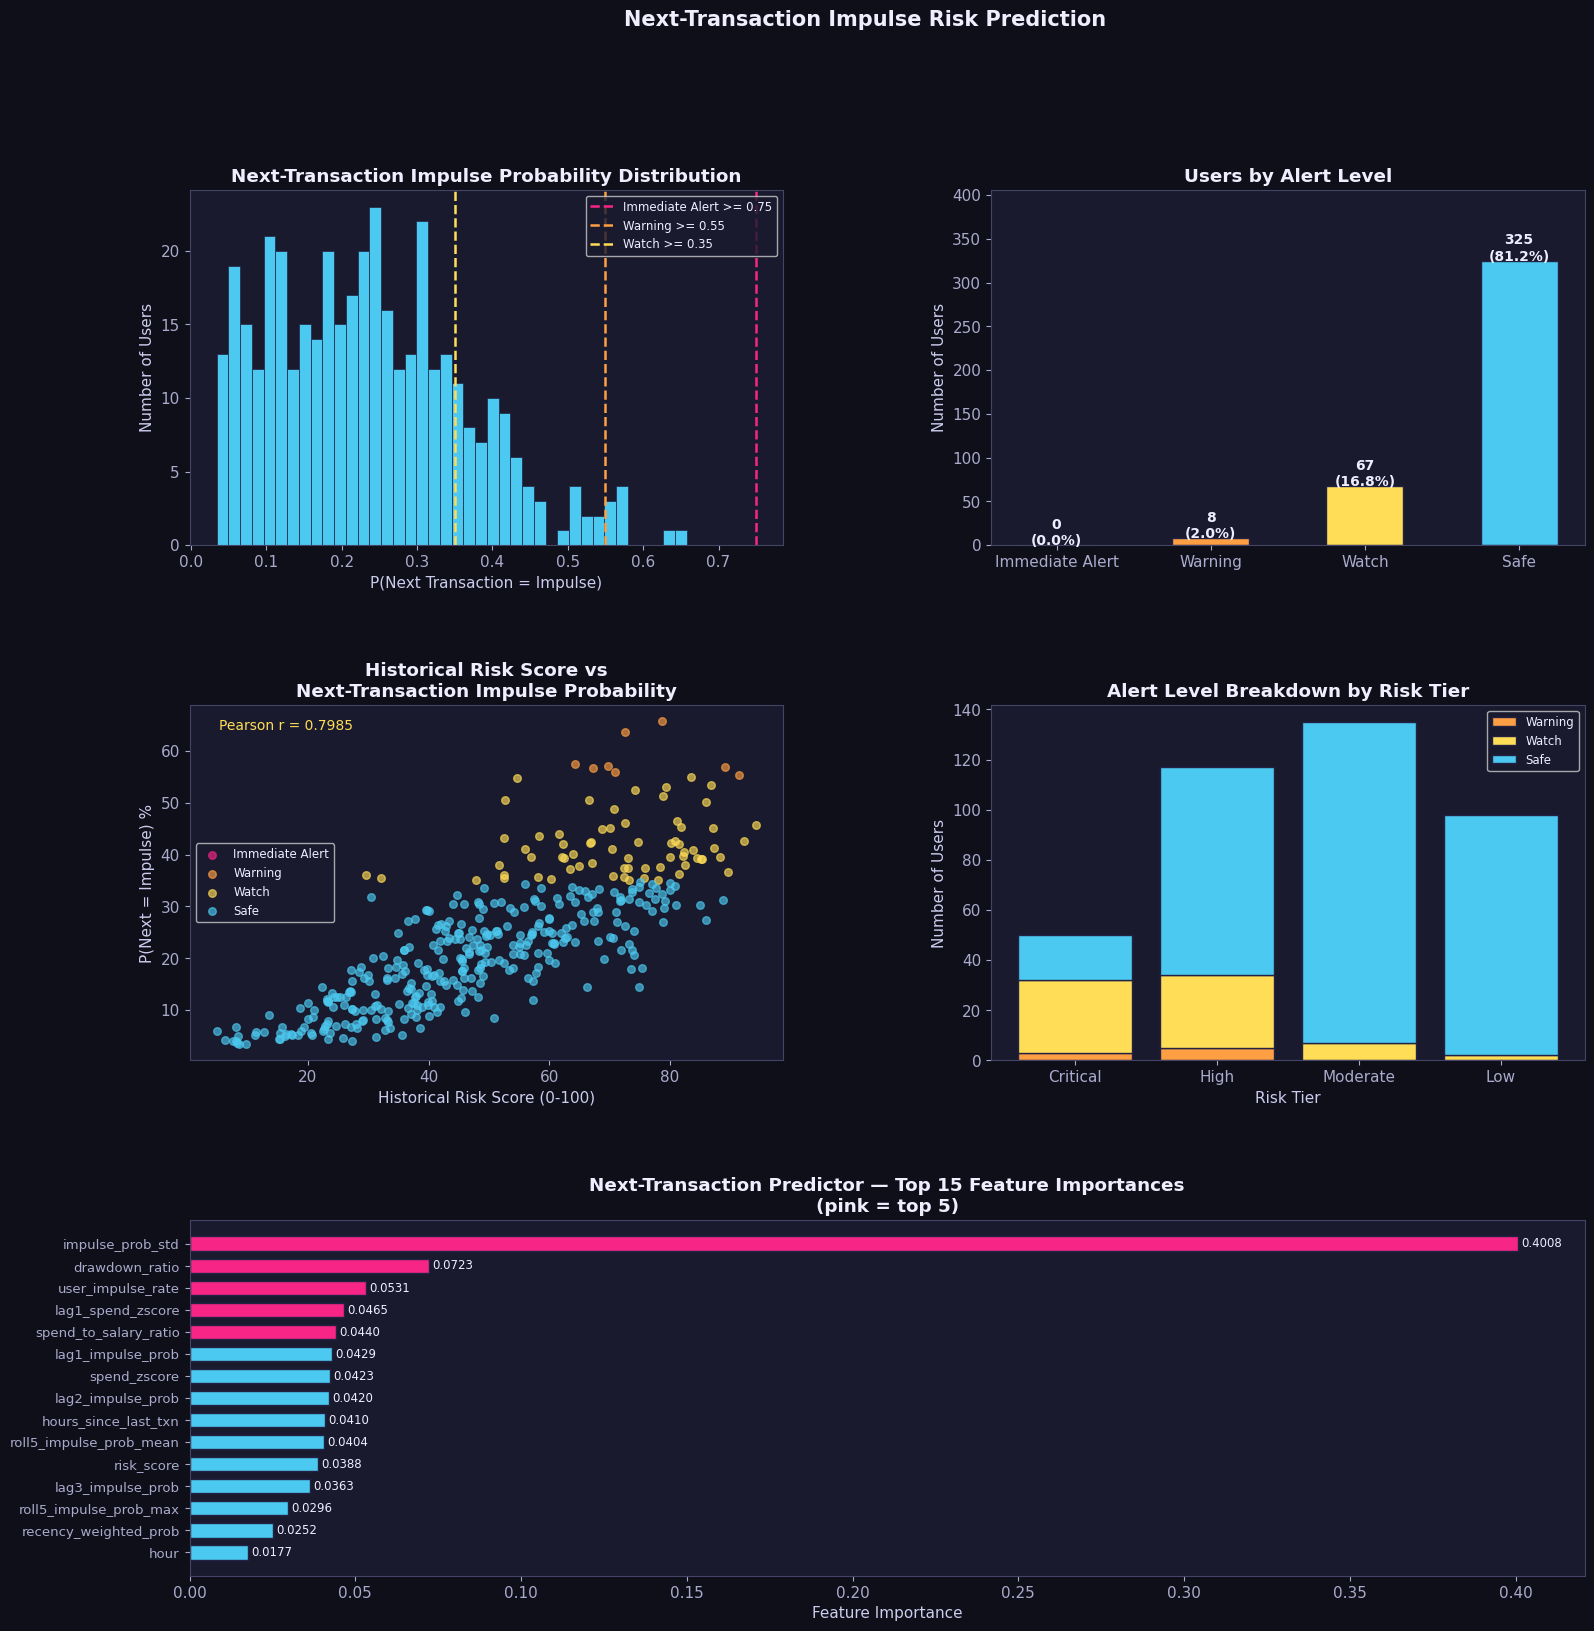


Saved: plot9_next_txn_prediction.png
Saved: at_risk_users.csv
Saved: model_next_txn_predictor.pkl

Step 9 complete. Proceed to STEP 10.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, f1_score

# ── 1. Load Data ──────────────────────────────────────────────
df = pd.read_csv("df_engineered.csv", parse_dates=["timestamp"])
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

user_agg = pd.read_csv("user_risk_profiles.csv")
xgb_cal  = joblib.load("model_xgb_calibrated.pkl")

# ✅ Fix: bypass sklearn wrapper, align features, cast to float32
def cal_proba(X):
    """Drop-in replacement for xgb_cal.predict_proba()."""
    preds = []
    X_df = X.reset_index(drop=True)
    for cc in xgb_cal.calibrated_classifiers_:
        est     = getattr(cc, 'estimator', None) or getattr(cc, 'base_estimator', None)
        booster = est.get_booster()
        booster_features = booster.feature_names
        X_aligned = pd.DataFrame(0.0, index=X_df.index, columns=booster_features)
        for col in booster_features:
            if col in X_df.columns:
                X_aligned[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0)
        X_aligned = X_aligned.astype(np.float32)
        dm = xgb.DMatrix(X_aligned)
        preds.append(booster.predict(dm, validate_features=False))
    avg = np.mean(preds, axis=0)
    return np.column_stack([1 - avg, avg])

EXCLUDE = [
    "transaction_id", "user_id", "timestamp", "impulse_label",
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

df["impulse_prob"] = cal_proba(df[feature_cols].fillna(0))[:, 1]

# ── 2. Build Next-Transaction Prediction Features ─────────────
print("Building next-transaction prediction dataset...")

def build_next_txn_features(group):
    group = group.sort_values("timestamp").copy()
    for lag in [1, 2, 3]:
        group[f"lag{lag}_impulse_prob"]  = group["impulse_prob"].shift(lag)
        group[f"lag{lag}_impulse_label"] = group["impulse_label"].shift(lag)
        group[f"lag{lag}_spend_zscore"]  = group["spend_zscore"].shift(lag)
    group["roll5_impulse_prob_mean"] = group["impulse_prob"].shift(1).rolling(5, min_periods=1).mean()
    group["roll5_impulse_prob_max"]  = group["impulse_prob"].shift(1).rolling(5, min_periods=1).max()
    group["roll5_impulse_rate"]      = group["impulse_label"].shift(1).rolling(5, min_periods=1).mean()
    group["hours_since_last_txn"] = (
        group["timestamp"].diff().dt.total_seconds() / 3600
    ).fillna(0)
    def impulse_streak(series):
        streaks, count = [], 0
        for val in series.shift(1).fillna(0):
            count = count + 1 if val == 1 else 0
            streaks.append(count)
        return streaks
    group["impulse_streak"] = impulse_streak(group["impulse_label"])
    group["next_impulse"]   = group["impulse_label"].shift(-1)
    return group

df_next = df.groupby("user_id", group_keys=False).apply(build_next_txn_features)

user_feats = user_agg[["user_id", "risk_score", "recency_weighted_prob", "impulse_prob_std", "cluster"]]
df_next = df_next.merge(user_feats, on="user_id", how="left")
df_next = df_next.dropna(subset=["next_impulse"])
df_next["next_impulse"] = df_next["next_impulse"].astype(int)

print(f"Next-transaction dataset shape : {df_next.shape}")
print(f"Next impulse rate              : {df_next['next_impulse'].mean():.4f}")

# ── 3. Define Feature Set ─────────────────────────────────────
next_features = [
    "lag1_impulse_prob", "lag2_impulse_prob", "lag3_impulse_prob",
    "lag1_impulse_label", "lag2_impulse_label", "lag3_impulse_label",
    "lag1_spend_zscore",
    "roll5_impulse_prob_mean", "roll5_impulse_prob_max", "roll5_impulse_rate",
    "hour", "is_weekend", "is_late_night", "is_evening",
    "impulse_streak", "hours_since_last_txn",
    "spend_zscore", "spend_to_salary_ratio", "balance_stress",
    "category_impulse_risk", "drawdown_ratio",
    "risk_score", "recency_weighted_prob", "impulse_prob_std", "cluster",
    "user_impulse_rate",
]
next_features = [f for f in next_features if f in df_next.columns]
X_next = df_next[next_features].fillna(0)
y_next = df_next["next_impulse"]
print(f"Next-txn feature count : {len(next_features)}")

# ── 4. Train/Test Split (time-aware) ─────────────────────────
cutoff     = df_next["timestamp"].quantile(0.80)
train_mask = df_next["timestamp"] <= cutoff
test_mask  = df_next["timestamp"] >  cutoff

X_tr, X_te = X_next[train_mask], X_next[test_mask]
y_tr, y_te = y_next[train_mask], y_next[test_mask]

print(f"\nTime-aware split:")
print(f"  Train: {X_tr.shape[0]:,} rows | cutoff = {cutoff}")
print(f"  Test : {X_te.shape[0]:,} rows")
print(f"  Train impulse rate: {y_tr.mean():.4f}")
print(f"  Test  impulse rate: {y_te.mean():.4f}")

# ── 5. Train Next-Transaction Predictor ──────────────────────
print("\nTraining next-transaction GBM predictor...")

next_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=42
    ))
])

cv     = StratifiedKFold(n_splits=5, shuffle=False)
cv_auc = cross_val_score(next_model, X_tr, y_tr, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")

next_model.fit(X_tr, y_tr)

y_next_prob = next_model.predict_proba(X_te)[:, 1]
y_next_pred = (y_next_prob >= 0.5).astype(int)

print(f"\nTest ROC-AUC : {roc_auc_score(y_te, y_next_prob):.4f}")
print(f"Test F1      : {f1_score(y_te, y_next_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_te, y_next_pred,
      target_names=["Non-Impulse Next", "Impulse Next"], digits=4))

joblib.dump(next_model, "model_next_txn_predictor.pkl")

# ── 6. Generate At-Risk User List ─────────────────────────────
print("Generating at-risk user alerts...")

latest_txns = (
    df_next.sort_values("timestamp")
           .groupby("user_id").last()
           .reset_index()
)

X_latest = latest_txns[next_features].fillna(0)
latest_txns["next_impulse_prob"] = next_model.predict_proba(X_latest)[:, 1]

at_risk = latest_txns[["user_id", "next_impulse_prob"]].merge(
    user_agg[["user_id", "risk_score", "risk_tier", "raw_impulse_rate", "persona", "cluster"]],
    on="user_id", how="left"
)

def alert_level(p):
    if   p >= 0.75: return "Immediate Alert"
    elif p >= 0.55: return "Warning"
    elif p >= 0.35: return "Watch"
    else:           return "Safe"

at_risk["alert_level"] = at_risk["next_impulse_prob"].apply(alert_level)
at_risk = at_risk.sort_values("next_impulse_prob", ascending=False)

print("\n" + "="*70)
print("AT-RISK USER ALERT SUMMARY")
print("="*70)
alert_summary = at_risk["alert_level"].value_counts().reset_index()
alert_summary.columns = ["alert_level", "user_count"]
print(alert_summary.to_string(index=False))

print("\n--- Top 10 Highest Risk Users for Next Transaction ---")
print(at_risk.head(10)[[
    "user_id", "next_impulse_prob", "risk_score",
    "risk_tier", "alert_level", "raw_impulse_rate"
]].to_string(index=False))

at_risk.to_csv("at_risk_users.csv", index=False)

# ── 7. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

ALERT_COLORS = {
    "Immediate Alert": "#f72585",
    "Warning":         "#ff9f43",
    "Watch":           "#ffdd57",
    "Safe":            "#4cc9f0",
}

fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Next-Transaction Impulse Risk Prediction", fontsize=15, fontweight="bold")
alert_order = ["Immediate Alert", "Warning", "Watch", "Safe"]

# 7a. Probability distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(at_risk["next_impulse_prob"], bins=40, color="#4cc9f0", edgecolor="#222244", linewidth=0.5)
ax1.axvline(0.75, color="#f72585", linewidth=1.8, linestyle="--", label="Immediate Alert >= 0.75")
ax1.axvline(0.55, color="#ff9f43", linewidth=1.8, linestyle="--", label="Warning >= 0.55")
ax1.axvline(0.35, color="#ffdd57", linewidth=1.8, linestyle="--", label="Watch >= 0.35")
ax1.set_title("Next-Transaction Impulse Probability Distribution", fontweight="bold")
ax1.set_xlabel("P(Next Transaction = Impulse)")
ax1.set_ylabel("Number of Users")
ax1.legend(fontsize=8.5)

# 7b. Alert level counts
ax2 = fig.add_subplot(gs[0, 1])
alert_counts = at_risk["alert_level"].value_counts().reindex(alert_order).fillna(0)
colors_list  = [ALERT_COLORS[a] for a in alert_order]
bars = ax2.bar(alert_order, alert_counts.values, color=colors_list, edgecolor="#222244", width=0.5)
for bar, val in zip(bars, alert_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{int(val)}\n({val/len(at_risk)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Users by Alert Level", fontweight="bold")
ax2.set_ylabel("Number of Users")
ax2.set_ylim(0, alert_counts.max() * 1.25)

# 7c. Scatter: risk score vs next impulse prob
ax3 = fig.add_subplot(gs[1, 0])
for alert, color in ALERT_COLORS.items():
    subset = at_risk[at_risk["alert_level"] == alert]
    ax3.scatter(subset["risk_score"], subset["next_impulse_prob"] * 100,
                color=color, alpha=0.65, s=30, label=alert)
ax3.set_title("Historical Risk Score vs\nNext-Transaction Impulse Probability", fontweight="bold")
ax3.set_xlabel("Historical Risk Score (0-100)")
ax3.set_ylabel("P(Next = Impulse) %")
ax3.legend(fontsize=8.5)
corr = at_risk["risk_score"].corr(at_risk["next_impulse_prob"])
ax3.text(0.05, 0.93, f"Pearson r = {corr:.4f}", transform=ax3.transAxes, fontsize=10, color="#ffdd57")

# 7d. Stacked bar: alert level by risk tier
ax4 = fig.add_subplot(gs[1, 1])
tier_alert = at_risk.groupby(["risk_tier", "alert_level"]).size().unstack(fill_value=0)
tier_order_plot = ["Critical", "High", "Moderate", "Low"]
tier_alert = tier_alert.reindex([t for t in tier_order_plot if t in tier_alert.index])
bottom = np.zeros(len(tier_alert))
for alert in alert_order:
    if alert not in tier_alert.columns:
        continue
    vals = tier_alert[alert].values
    ax4.bar(tier_alert.index, vals, bottom=bottom, color=ALERT_COLORS[alert],
            label=alert, edgecolor="#222244")
    bottom += vals
ax4.set_title("Alert Level Breakdown by Risk Tier", fontweight="bold")
ax4.set_xlabel("Risk Tier")
ax4.set_ylabel("Number of Users")
ax4.legend(fontsize=8.5)

# 7e. Feature importance
ax5 = fig.add_subplot(gs[2, :])
gbm_clf  = next_model.named_steps["clf"]
feat_imp = pd.DataFrame({
    "feature":    next_features,
    "importance": gbm_clf.feature_importances_
}).sort_values("importance").tail(15)

colors = ["#f72585" if i >= len(feat_imp) - 5 else "#4cc9f0" for i in range(len(feat_imp))]
bars = ax5.barh(feat_imp["feature"], feat_imp["importance"], color=colors, edgecolor="#222244", height=0.65)
ax5.set_title("Next-Transaction Predictor — Top 15 Feature Importances\n(pink = top 5)", fontweight="bold")
ax5.set_xlabel("Feature Importance")
ax5.tick_params(axis="y", labelsize=9.5)
for bar, val in zip(bars, feat_imp["importance"]):
    ax5.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8.5)

plt.savefig("plot9_next_txn_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: plot9_next_txn_prediction.png")
print("Saved: at_risk_users.csv")
print("Saved: model_next_txn_predictor.pkl")
print("\nStep 9 complete. Proceed to STEP 10.")


# STEP 10: Personalised Behavioural Nudges

[19:51:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[19:51:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  

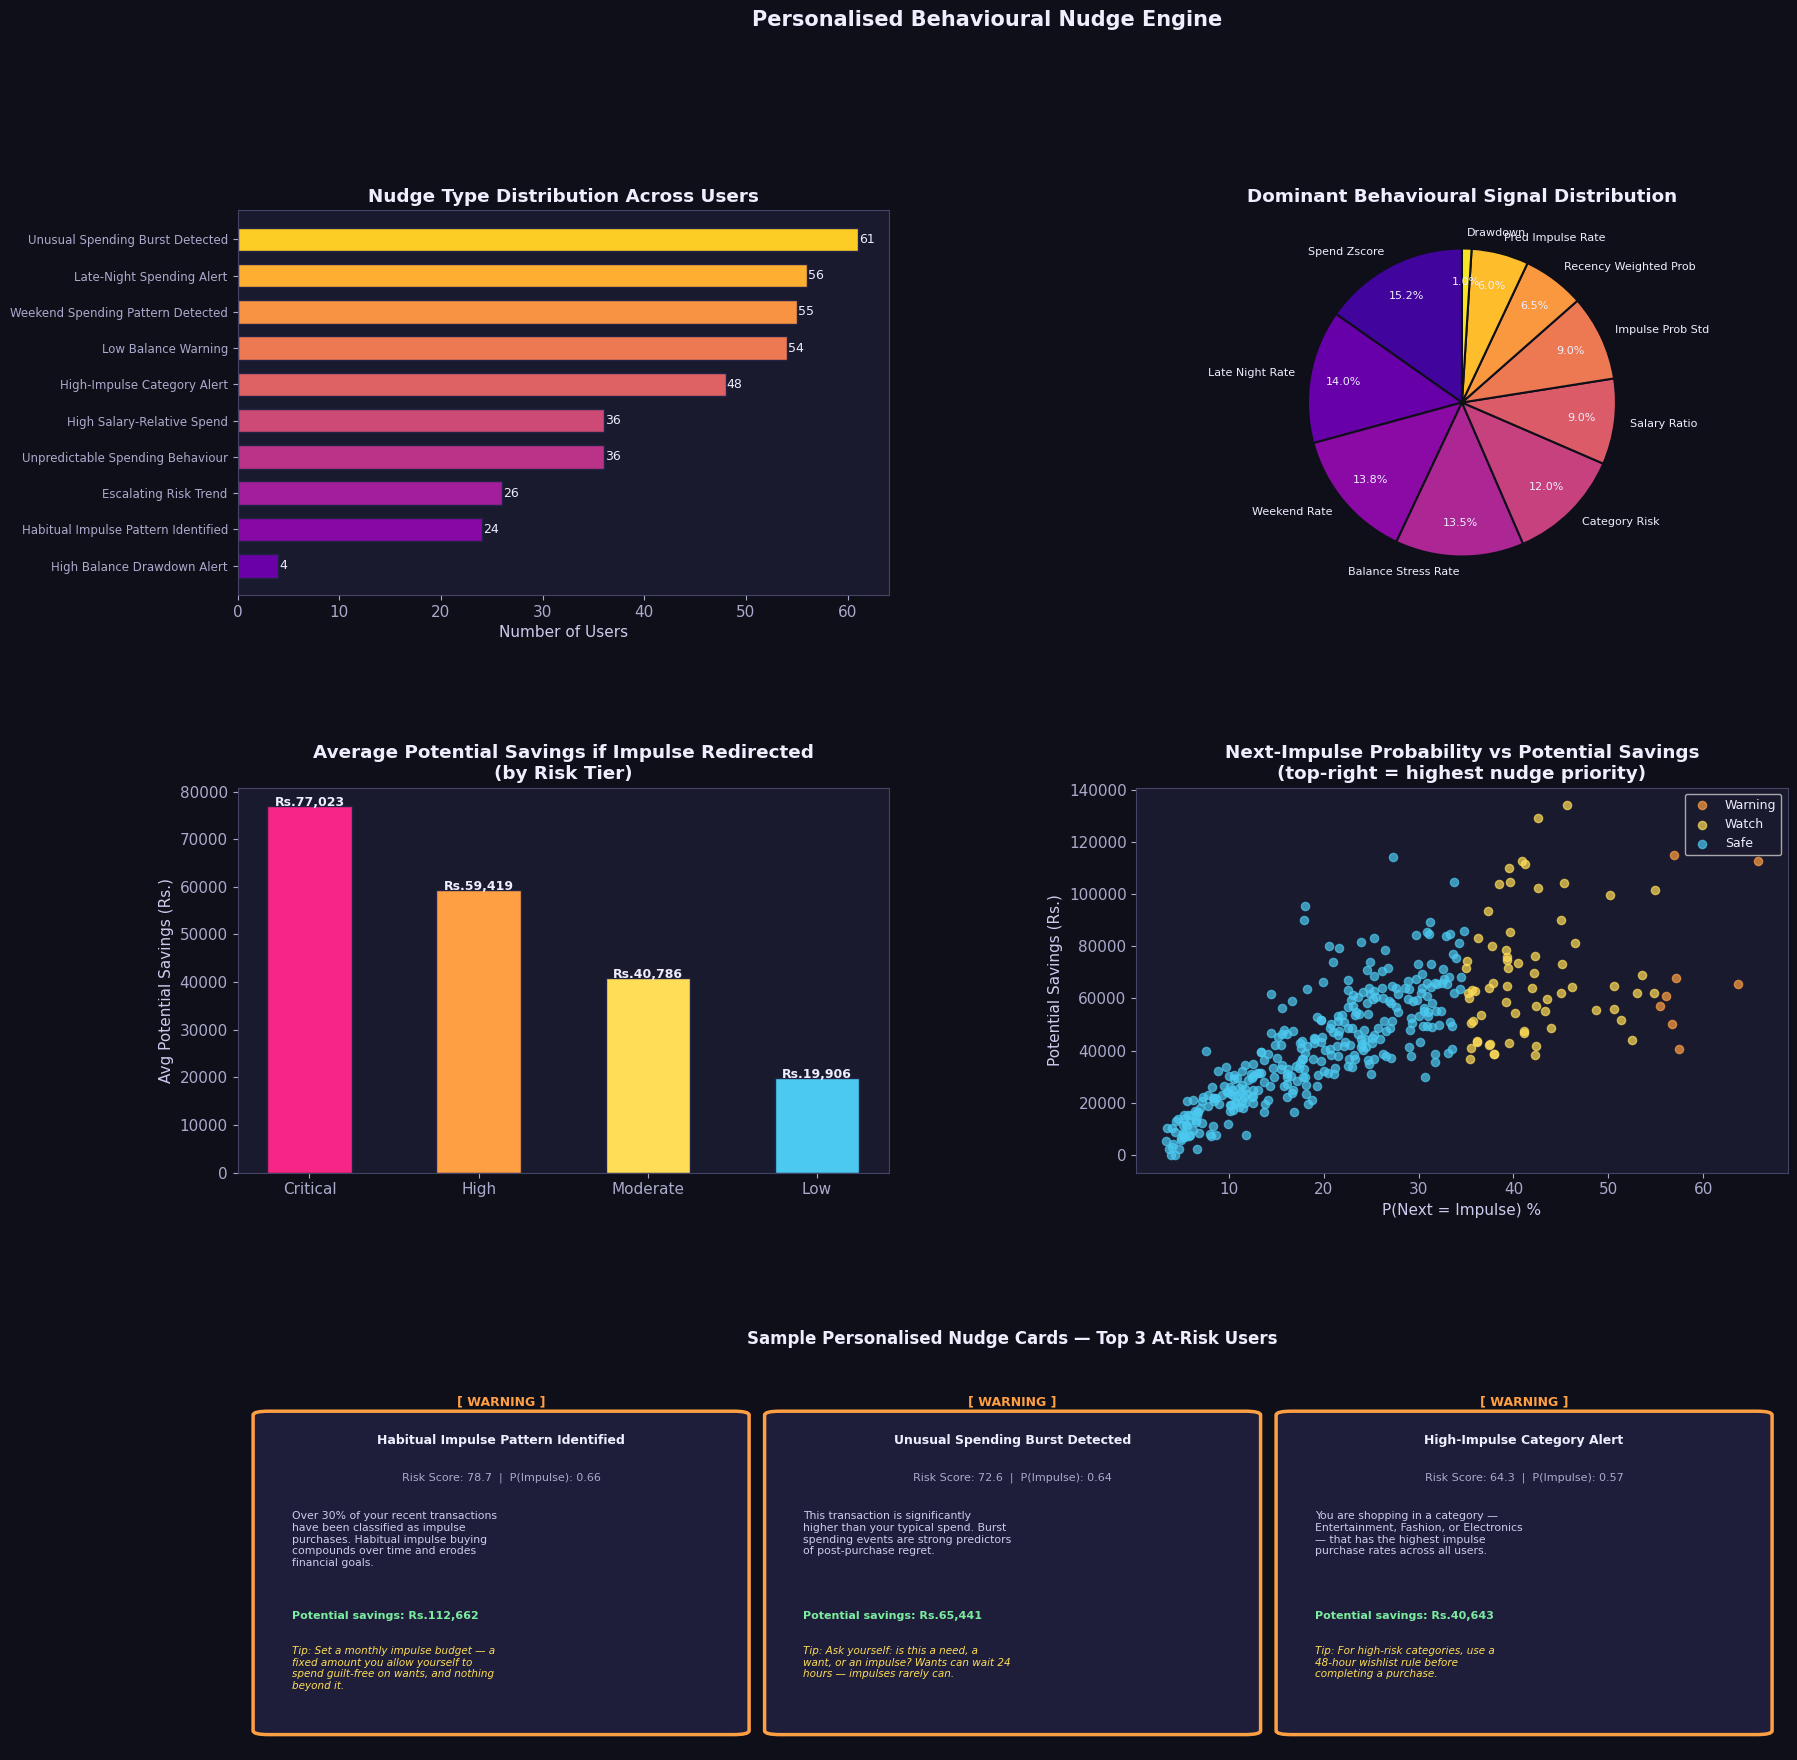


Saved: plot10_nudge_engine.png
Saved: personalised_nudges.csv

Step 10 complete.

Full pipeline summary:
  STEP 1  — Feature Engineering       : df_engineered.csv
  STEP 2  — Exploratory Analysis      : eba_summary.csv
  STEP 3  — Logistic Regression       : model_lr_baseline.pkl
  STEP 4  — RF + XGBoost              : model_rf.pkl / model_xgb.pkl
  STEP 5  — Deep Evaluation           : deep_evaluation.csv
  STEP 6  — SHAP Explainability       : shap_importance.csv
  STEP 7  — User Risk Scores          : user_risk_profiles.csv
  STEP 8  — Behavioural Clustering    : persona_summary.csv
  STEP 9  — Next-Txn Prediction       : at_risk_users.csv
  STEP 10 — Personalised Nudges       : personalised_nudges.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import textwrap
import joblib
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load All Required Artefacts ───────────────────────────
df = pd.read_csv("df_engineered.csv", parse_dates=["timestamp"])
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

user_agg = pd.read_csv("user_risk_profiles.csv")
at_risk  = pd.read_csv("at_risk_users.csv")
xgb_cal  = joblib.load("model_xgb_calibrated.pkl")

# ✅ Fix: bypass broken sklearn wrapper
def cal_proba(X):
    preds = []
    X_df = X.reset_index(drop=True)
    for cc in xgb_cal.calibrated_classifiers_:
        est     = getattr(cc, 'estimator', None) or getattr(cc, 'base_estimator', None)
        booster = est.get_booster()
        booster_features = booster.feature_names
        X_aligned = pd.DataFrame(0.0, index=X_df.index, columns=booster_features)
        for col in booster_features:
            if col in X_df.columns:
                X_aligned[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0)
        X_aligned = X_aligned.astype(np.float32)
        dm = xgb.DMatrix(X_aligned)
        preds.append(booster.predict(dm, validate_features=False))
    avg = np.mean(preds, axis=0)
    return np.column_stack([1 - avg, avg])

EXCLUDE = [
    "transaction_id", "user_id", "timestamp", "impulse_label",
    "balance_before_approx", "user_mean_spend", "user_std_spend",
    "balance_after", "transaction_amount", "monthly_salary"
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

# ── 2. Nudge Template Library ─────────────────────────────────
NUDGE_LIBRARY = {
    "late_night_rate": {
        "title":   "Late-Night Spending Alert",
        "message": "You tend to make unplanned purchases late at night. "
                   "Research shows decision-making quality drops significantly "
                   "after 10 PM due to mental fatigue.",
        "tip":     "Try the 10-minute rule: add items to your cart but wait "
                   "until morning to confirm the purchase.",
        "icon":    "NIGHT"
    },
    "weekend_rate": {
        "title":   "Weekend Spending Pattern Detected",
        "message": "Your spending tends to spike on weekends. Weekend purchases "
                   "are 34% more likely to be regretted compared to weekday ones.",
        "tip":     "Set a weekend leisure budget at the start of each week "
                   "and track it separately from your essentials.",
        "icon":    "WEEKEND"
    },
    "mean_spend_zscore": {
        "title":   "Unusual Spending Burst Detected",
        "message": "This transaction is significantly higher than your typical "
                   "spend. Burst spending events are strong predictors of "
                   "post-purchase regret.",
        "tip":     "Ask yourself: is this a need, a want, or an impulse? "
                   "Wants can wait 24 hours — impulses rarely can.",
        "icon":    "BURST"
    },
    "balance_stress_rate": {
        "title":   "Low Balance Warning",
        "message": "You are spending when your balance is under 10% of your "
                   "monthly income. Financial stress and impulsive decisions "
                   "often occur together.",
        "tip":     "Pause non-essential purchases until after your next salary "
                   "credit. Your future self will thank you.",
        "icon":    "STRESS"
    },
    "mean_category_risk": {
        "title":   "High-Impulse Category Alert",
        "message": "You are shopping in a category — Entertainment, Fashion, "
                   "or Electronics — that has the highest impulse purchase rates "
                   "across all users.",
        "tip":     "For high-risk categories, use a 48-hour wishlist rule before "
                   "completing a purchase.",
        "icon":    "CATEGORY"
    },
    "pred_impulse_rate": {
        "title":   "Habitual Impulse Pattern Identified",
        "message": "Over 30% of your recent transactions have been classified "
                   "as impulse purchases. Habitual impulse buying compounds "
                   "over time and erodes financial goals.",
        "tip":     "Set a monthly impulse budget — a fixed amount you allow "
                   "yourself to spend guilt-free on wants, and nothing beyond it.",
        "icon":    "HABIT"
    },
    "mean_salary_ratio": {
        "title":   "High Salary-Relative Spend",
        "message": "Your transactions are consuming an above-average share of "
                   "your income. Even small percentage increases in discretionary "
                   "spend compound significantly over a year.",
        "tip":     "Try the 50/30/20 rule: 50% needs, 30% wants, 20% savings. "
                   "Your current pattern may be inverting this ratio.",
        "icon":    "SALARY"
    },
    "impulse_prob_std": {
        "title":   "Unpredictable Spending Behaviour",
        "message": "Your spending pattern is highly variable — calm periods "
                   "followed by sudden spending bursts. This pattern is associated "
                   "with emotional spending triggers.",
        "tip":     "Keep a 2-line spending journal: what you bought and how you "
                   "felt. Patterns will emerge within 2 weeks.",
        "icon":    "VARIABLE"
    },
    "recency_weighted_prob": {
        "title":   "Escalating Risk Trend",
        "message": "Your recent transactions show an increasing impulse "
                   "probability trend. Early intervention is significantly "
                   "more effective than later correction.",
        "tip":     "Review your last 5 purchases and identify which ones you "
                   "would make again. This builds financial self-awareness.",
        "icon":    "ESCALATING"
    },
    "mean_drawdown": {
        "title":   "High Balance Drawdown Alert",
        "message": "Your transactions are consuming a high proportion of your "
                   "available balance in single sessions, leaving little buffer "
                   "for planned expenses.",
        "tip":     "Before any purchase over 5% of your balance, check your "
                   "upcoming fixed expenses for the week.",
        "icon":    "DRAWDOWN"
    },
}

# ── 3. Determine Dominant Signal Per User ─────────────────────
cluster_feature_cols = [
    "pred_impulse_rate", "mean_spend_zscore", "late_night_rate",
    "weekend_rate", "mean_category_risk", "mean_salary_ratio",
    "balance_stress_rate", "impulse_prob_std", "mean_drawdown",
    "recency_weighted_prob",
]

pop_mean = user_agg[cluster_feature_cols].mean()
pop_std  = user_agg[cluster_feature_cols].std().replace(0, 1)

def get_dominant_signal(row):
    z_scores = (row[cluster_feature_cols] - pop_mean) / pop_std
    return z_scores.abs().idxmax()

user_agg["dominant_signal"] = user_agg.apply(get_dominant_signal, axis=1)

# ── 4. Counterfactual Saving Calculation ─────────────────────
# ✅ Fixed: use cal_proba() instead of xgb_cal.predict_proba()
df["impulse_prob"] = cal_proba(df[feature_cols].fillna(0))[:, 1]
df["impulse_pred"] = (df["impulse_prob"] >= 0.70).astype(int)

user_savings = df.groupby("user_id").apply(
    lambda g: (g["transaction_amount"] * g["impulse_pred"]).sum()
).reset_index()
user_savings.columns = ["user_id", "potential_savings"]

user_agg = user_agg.merge(user_savings, on="user_id", how="left")

# ── 5. Generate Personalised Nudges ───────────────────────────
at_risk_full = at_risk.merge(
    user_agg[["user_id", "dominant_signal", "potential_savings",
              "late_night_rate", "balance_stress_rate",
              "mean_spend_zscore", "pred_impulse_rate"]],
    on="user_id", how="left"
)

def generate_nudge(row):
    signal  = row.get("dominant_signal", "pred_impulse_rate")
    nudge   = NUDGE_LIBRARY.get(signal, NUDGE_LIBRARY["pred_impulse_rate"])
    savings = row.get("potential_savings", 0)
    alert   = row.get("alert_level", "Watch")

    savings_line = (
        f"If you had redirected your impulse spending, you could have saved "
        f"approximately Rs.{savings:,.0f} this period."
        if savings > 0 else ""
    )

    urgency = {
        "Immediate Alert": "ACTION REQUIRED",
        "Warning":         "HEADS UP",
        "Watch":           "FYI",
        "Safe":            "TIP",
    }.get(alert, "TIP")

    full_message = (
        f"[{urgency}] {nudge['title']}\n"
        f"{nudge['message']}\n"
        f"{savings_line}\n"
        f"What to do: {nudge['tip']}"
    ).strip()

    return pd.Series({
        "nudge_title":   nudge["title"],
        "nudge_icon":    nudge["icon"],
        "nudge_message": nudge["message"],
        "nudge_tip":     nudge["tip"],
        "savings_line":  savings_line,
        "urgency":       urgency,
        "full_nudge":    full_message,
    })

nudge_cols   = at_risk_full.apply(generate_nudge, axis=1)
at_risk_full = pd.concat([at_risk_full, nudge_cols], axis=1)

# ── 6. Nudge Summary ──────────────────────────────────────────
print("="*70)
print("PERSONALISED NUDGE DELIVERY SUMMARY")
print("="*70)

nudge_dist = at_risk_full["nudge_title"].value_counts().reset_index()
nudge_dist.columns = ["nudge_type", "user_count"]
print(nudge_dist.to_string(index=False))

print(f"\nTotal users receiving nudges : {len(at_risk_full[at_risk_full['alert_level'] != 'Safe']):,}")
print(f"Total users marked Safe      : {len(at_risk_full[at_risk_full['alert_level'] == 'Safe']):,}")

print("\n--- Sample Nudges: Top 5 At-Risk Users ---")
for _, row in at_risk_full.head(5).iterrows():
    print(f"\nUser      : {str(row['user_id'])[:18]}...")
    print(f"Risk Tier : {row['risk_tier']}  |  Alert: {row['alert_level']}  "
          f"|  Next-Impulse P: {row['next_impulse_prob']:.3f}")
    print(f"Signal    : {row['dominant_signal']}")
    print(f"Savings   : Rs.{row['potential_savings']:,.0f}")
    for line in textwrap.wrap(row["full_nudge"], width=70):
        print(f"  {line}")
    print("-" * 70)

at_risk_full.to_csv("personalised_nudges.csv", index=False)

# ── 7. Plots ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444466",   "axes.labelcolor": "#ccccee",
    "xtick.color": "#aaaacc",      "ytick.color": "#aaaacc",
    "text.color": "#eeeeff",       "grid.color": "#2a2a44",
    "grid.linestyle": "--",        "grid.alpha": 0.5, "font.size": 11,
})

ALERT_COLORS = {
    "Immediate Alert": "#f72585",
    "Warning":         "#ff9f43",
    "Watch":           "#ffdd57",
    "Safe":            "#4cc9f0",
}

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.38)
fig.suptitle("Personalised Behavioural Nudge Engine", fontsize=15, fontweight="bold")

# 7a. Nudge type distribution
ax1 = fig.add_subplot(gs[0, 0])
nudge_plot  = at_risk_full["nudge_title"].value_counts().sort_values()
colors_bar  = plt.cm.get_cmap("plasma")(np.linspace(0.2, 0.9, len(nudge_plot)))
bars = ax1.barh(nudge_plot.index, nudge_plot.values,
                color=colors_bar, edgecolor="#222244", height=0.65)
ax1.set_title("Nudge Type Distribution Across Users", fontweight="bold")
ax1.set_xlabel("Number of Users")
ax1.tick_params(axis="y", labelsize=8.5)
for bar, val in zip(bars, nudge_plot.values):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)

# 7b. Dominant signal pie
ax2 = fig.add_subplot(gs[0, 1])
sig_counts  = user_agg["dominant_signal"].value_counts()
short_labels = [s.replace("_", " ").replace("mean ", "").title()
                for s in sig_counts.index]
wedges, texts, autotexts = ax2.pie(
    sig_counts.values, labels=short_labels,
    autopct="%1.1f%%", pctdistance=0.78, startangle=90,
    wedgeprops={"edgecolor": "#0f0f1a", "linewidth": 1.5},
    colors=plt.cm.get_cmap("plasma")(np.linspace(0.1, 0.95, len(sig_counts)))
)
for t in texts + autotexts:
    t.set_color("#eeeeff")
    t.set_fontsize(8)
ax2.set_title("Dominant Behavioural Signal Distribution", fontweight="bold")

# 7c. Potential savings by risk tier
ax3 = fig.add_subplot(gs[1, 0])
tier_savings = user_agg.groupby("risk_tier")["potential_savings"].mean().reindex(
    ["Critical", "High", "Moderate", "Low"]
).dropna()
tier_colors_list = ["#f72585", "#ff9f43", "#ffdd57", "#4cc9f0"]
bars = ax3.bar(tier_savings.index, tier_savings.values,
               color=tier_colors_list[:len(tier_savings)],
               edgecolor="#222244", width=0.5)
ax3.set_title("Average Potential Savings if Impulse Redirected\n(by Risk Tier)", fontweight="bold")
ax3.set_ylabel("Avg Potential Savings (Rs.)")
for bar, val in zip(bars, tier_savings.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"Rs.{val:,.0f}", ha="center", fontsize=9, fontweight="bold")

# 7d. Next impulse prob vs savings scatter
ax4 = fig.add_subplot(gs[1, 1])
for alert, color in ALERT_COLORS.items():
    subset = at_risk_full[at_risk_full["alert_level"] == alert]
    if len(subset) == 0:
        continue
    ax4.scatter(subset["next_impulse_prob"] * 100, subset["potential_savings"],
                color=color, alpha=0.7, s=35, label=alert)
ax4.set_title("Next-Impulse Probability vs Potential Savings\n"
              "(top-right = highest nudge priority)", fontweight="bold")
ax4.set_xlabel("P(Next = Impulse) %")
ax4.set_ylabel("Potential Savings (Rs.)")
ax4.legend(fontsize=9)

# 7e. Nudge cards for top 3 users
ax5 = fig.add_subplot(gs[2, :])
ax5.axis("off")
ax5.set_title("Sample Personalised Nudge Cards — Top 3 At-Risk Users",
              fontweight="bold", fontsize=12, pad=15)

top3 = at_risk_full.head(3)
card_width  = 0.30
card_gap    = 0.03
card_height = 0.82
card_top    = 0.92

for i, (_, row) in enumerate(top3.iterrows()):
    x_start = i * (card_width + card_gap) + 0.02
    color   = ALERT_COLORS.get(row["alert_level"], "#4cc9f0")

    fancy = mpatches.FancyBboxPatch(
        (x_start, 0.05), card_width, card_height,
        boxstyle="round,pad=0.01",
        facecolor="#1e1e3a", edgecolor=color, linewidth=2.5,
        transform=ax5.transAxes, zorder=2
    )
    ax5.add_patch(fancy)

    ax5.text(x_start + card_width/2, card_top,
             f"[ {row['alert_level'].upper()} ]",
             transform=ax5.transAxes, ha="center", va="top",
             fontsize=9, fontweight="bold", color=color, zorder=3)

    ax5.text(x_start + card_width/2, card_top - 0.10,
             row["nudge_title"],
             transform=ax5.transAxes, ha="center", va="top",
             fontsize=9, fontweight="bold", color="#eeeeff", zorder=3)

    ax5.text(x_start + card_width/2, card_top - 0.20,
             f"Risk Score: {row['risk_score']:.1f}  |  "
             f"P(Impulse): {row['next_impulse_prob']:.2f}",
             transform=ax5.transAxes, ha="center", va="top",
             fontsize=8, color="#aaaacc", zorder=3)

    wrapped_msg = textwrap.fill(row["nudge_message"], width=38)
    ax5.text(x_start + 0.015, card_top - 0.30,
             wrapped_msg,
             transform=ax5.transAxes, ha="left", va="top",
             fontsize=7.8, color="#ccccee", zorder=3)

    if row["potential_savings"] > 0:
        ax5.text(x_start + 0.015, card_top - 0.56,
                 f"Potential savings: Rs.{row['potential_savings']:,.0f}",
                 transform=ax5.transAxes, ha="left", va="top",
                 fontsize=8, color="#7bed9f", fontweight="bold", zorder=3)

    wrapped_tip = textwrap.fill(f"Tip: {row['nudge_tip']}", width=38)
    ax5.text(x_start + 0.015, card_top - 0.65,
             wrapped_tip,
             transform=ax5.transAxes, ha="left", va="top",
             fontsize=7.5, color="#ffdd57", style="italic", zorder=3)

plt.savefig("plot10_nudge_engine.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: plot10_nudge_engine.png")
print("Saved: personalised_nudges.csv")
print("\nStep 10 complete.")
print("\nFull pipeline summary:")
print("  STEP 1  — Feature Engineering       : df_engineered.csv")
print("  STEP 2  — Exploratory Analysis      : eba_summary.csv")
print("  STEP 3  — Logistic Regression       : model_lr_baseline.pkl")
print("  STEP 4  — RF + XGBoost              : model_rf.pkl / model_xgb.pkl")
print("  STEP 5  — Deep Evaluation           : deep_evaluation.csv")
print("  STEP 6  — SHAP Explainability       : shap_importance.csv")
print("  STEP 7  — User Risk Scores          : user_risk_profiles.csv")
print("  STEP 8  — Behavioural Clustering    : persona_summary.csv")
print("  STEP 9  — Next-Txn Prediction       : at_risk_users.csv")
print("  STEP 10 — Personalised Nudges       : personalised_nudges.csv")


In [20]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load All Pipeline Outputs ─────────────────────────────
user_agg     = pd.read_csv("user_risk_profiles.csv")
at_risk      = pd.read_csv("at_risk_users.csv")
nudges       = pd.read_csv("personalised_nudges.csv")
eval_df      = pd.read_csv("deep_evaluation.csv")
shap_imp     = pd.read_csv("shap_importance.csv")
tier_summary = pd.read_csv("tier_summary.csv")
persona_df   = pd.read_csv("persona_summary.csv")

# ── 2. Prepare Embedded Data ──────────────────────────────────
tier_data    = tier_summary.fillna(0).to_dict(orient="records")
model_data   = eval_df[["Model","ROC-AUC","F1","MCC","Precision","Recall"]].to_dict(orient="records")
shap_data    = shap_imp.head(12)[["feature","mean_abs_shap"]].to_dict(orient="records")
alert_counts = at_risk["alert_level"].value_counts().to_dict()
top_users    = nudges.head(8)[[
    "user_id","next_impulse_prob","risk_score","risk_tier",
    "alert_level","raw_impulse_rate","nudge_title",
    "nudge_tip","potential_savings","dominant_signal"
]].fillna(0).to_dict(orient="records")
tier_counts  = user_agg["risk_tier"].value_counts().to_dict()
scores       = user_agg["risk_score"].dropna().tolist()
persona_data = persona_df.fillna(0).to_dict(orient="records")

total_users      = len(user_agg)
total_txns       = 23852
best_auc         = float(eval_df["ROC-AUC"].max())
best_f1          = float(eval_df["F1"].max())
best_mcc         = float(eval_df["MCC"].max())
critical_users   = int(tier_counts.get("Critical", 0))
immediate_alerts = int(alert_counts.get("Immediate Alert", 0))
warning_alerts   = int(alert_counts.get("Warning", 0))

# ── 3. Pre-build HTML snippets (avoids nested f-string issues) ─

STEP_NAMES = [
    "Feature Eng", "EBA", "Logistic Reg", "RF+XGBoost",
    "Deep Eval", "SHAP", "Risk Score", "Clustering",
    "Next-Txn", "Nudges", "Dashboard"
]
pipeline_html = ""
for i, name in enumerate(STEP_NAMES):
    active_cls = " active" if i == 10 else ""
    arrow      = "" if i == 10 else '<div class="pipeline-arrow">&#8250;</div>'
    pipeline_html += (
        '<div class="pipeline-step">'
        '<div class="pipeline-node' + active_cls + '">S' + str(i+1) + " " + name + "</div>"
        + arrow + "</div>"
    )

TIER_COLORS = {"Critical": "#f72585", "High": "#ff9f43", "Moderate": "#ffdd57", "Low": "#4cc9f0"}

tier_rows_html = ""
for r in tier_data:
    tier      = str(r.get("risk_tier", "Moderate"))
    tcolor    = TIER_COLORS.get(tier, "#4cc9f0")
    ucount    = int(r.get("user_count", 0))
    imp_rate  = r.get("avg_impulse_rate", 0) * 100
    ln_rate   = r.get("avg_late_night_rate", 0) * 100
    bal_str   = r.get("avg_balance_stress", 0) * 100
    tier_rows_html += (
        '<div class="tier-row">'
        '<div>'
        '<div class="tier-row-label" style="color:' + tcolor + ';">' + tier + '</div>'
        '<div style="font-size:10px;color:var(--muted);">' + str(ucount) + ' users</div>'
        '</div>'
        '<div class="tier-row-stat"><strong>' + "{:.1f}%".format(imp_rate) + '</strong>impulse rate</div>'
        '<div class="tier-row-stat"><strong>' + "{:.1f}%".format(ln_rate)  + '</strong>late night</div>'
        '<div class="tier-row-stat"><strong>' + "{:.1f}%".format(bal_str)  + '</strong>balance stress</div>'
        '</div>'
    )

user_table_rows_html = ""
for u in top_users:
    uid        = str(u.get("user_id", ""))[:22] + "..."
    prob       = u.get("next_impulse_prob", 0)
    prob_pct   = min(prob * 100, 100)
    rscore     = u.get("risk_score", 0)
    rtier      = str(u.get("risk_tier", "Low"))
    alevel     = str(u.get("alert_level", "Safe"))
    alevel_cls = alevel.replace(" ", "-")
    imp_rate   = u.get("raw_impulse_rate", 0) * 100
    signal     = str(u.get("dominant_signal", "")).replace("_", " ")
    best_color = "var(--accent3)" if rtier == "Critical" else "var(--text)"
    user_table_rows_html += (
        "<tr>"
        '<td style="font-size:10px;color:var(--muted);">' + uid + "</td>"
        "<td>"
        '<div style="display:flex;align-items:center;gap:8px;">'
        '<div style="width:50px;height:5px;background:var(--border);border-radius:3px;">'
        '<div style="width:' + "{:.0f}".format(prob_pct) + '%;height:100%;background:var(--accent1);border-radius:3px;"></div>'
        "</div>"
        + "{:.3f}".format(prob) +
        "</div>"
        "</td>"
        "<td>" + "{:.1f}".format(rscore) + "</td>"
        '<td><span class="tier-pill tier-' + rtier + '">' + rtier + "</span></td>"
        '<td><span class="tier-pill tier-' + alevel_cls + '">' + alevel + "</span></td>"
        "<td>" + "{:.1f}%".format(imp_rate) + "</td>"
        '<td style="font-size:10px;color:var(--accent5);">' + signal + "</td>"
        "</tr>"
    )

nudge_cards_html = ""
for u in top_users:
    alevel  = str(u.get("alert_level", "Watch"))
    nc_color = (
        "#f72585" if alevel == "Immediate Alert" else
        "#ff9f43" if alevel == "Warning" else
        "#ffdd57" if alevel == "Watch" else "#4cc9f0"
    )
    rtier    = str(u.get("risk_tier", "Low"))
    uid      = str(u.get("user_id", ""))[:20] + "..."
    ntitle   = str(u.get("nudge_title", ""))
    ntip_raw = str(u.get("nudge_tip", ""))
    ntip     = ntip_raw[:100] + ("..." if len(ntip_raw) > 100 else "")
    prob     = u.get("next_impulse_prob", 0)
    savings  = u.get("potential_savings", 0)
    nudge_cards_html += (
        '<div class="nudge-card" style="--nc:' + nc_color + ';">'
        '<div class="nudge-alert">' + alevel + "</div>"
        '<div class="nudge-title">' + ntitle + "</div>"
        '<div class="nudge-user">' + uid + "</div>"
        '<div class="nudge-meta">'
        '<span class="tier-pill tier-' + rtier + '">' + rtier + "</span>"
        '<span class="badge" style="background:rgba(162,155,254,0.1);color:var(--accent5);border:1px solid rgba(162,155,254,0.3);">'
        "P=" + "{:.2f}".format(prob) + "</span>"
        "</div>"
        '<div class="nudge-tip">' + ntip + "</div>"
        '<div class="nudge-savings">Rs.' + "{:,.0f}".format(savings) + " potential savings</div>"
        "</div>"
    )

model_table_rows_html = ""
for m in model_data:
    mname    = str(m.get("Model", ""))
    is_best  = mname == "XGBoost"
    badge    = ' <span class="badge badge-best">BEST</span>' if is_best else ""
    name_color = "var(--accent3)" if is_best else "var(--text)"
    model_table_rows_html += (
        "<tr>"
        '<td style="font-weight:600;color:' + name_color + ';">' + mname + badge + "</td>"
        "<td>&mdash;</td>"
        '<td style="color:var(--accent2);">' + "{:.4f}".format(m.get("ROC-AUC", 0)) + "</td>"
        "<td>&mdash;</td>"
        '<td style="color:var(--accent3);">' + "{:.4f}".format(m.get("F1", 0)) + "</td>"
        "<td>" + "{:.4f}".format(m.get("Precision", 0)) + "</td>"
        "<td>" + "{:.4f}".format(m.get("Recall", 0)) + "</td>"
        '<td style="color:var(--accent5);">' + "{:.4f}".format(m.get("MCC", 0)) + "</td>"
        "</tr>"
    )

# ── 4. Build HTML ─────────────────────────────────────────────
html = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width, initial-scale=1.0"/>
<title>ImpulseIQ — Behavioural Analytics Dashboard</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=JetBrains+Mono:wght@300;400;500&display=swap" rel="stylesheet"/>
<style>
  :root {
    --bg:       #05050f; --surface:  #0d0d1f; --surface2: #13132a;
    --border:   #1e1e40; --accent1:  #f72585; --accent2:  #4cc9f0;
    --accent3:  #7bed9f; --accent4:  #ffdd57; --accent5:  #a29bfe;
    --text:     #e8e8f0; --muted:    #7070a0;
    --critical: #f72585; --high:     #ff9f43; --moderate: #ffdd57; --low: #4cc9f0;
    --font-display: 'Syne', sans-serif;
    --font-mono:    'JetBrains Mono', monospace;
  }
  * { margin:0; padding:0; box-sizing:border-box; }
  body { background:var(--bg); color:var(--text); font-family:var(--font-mono); min-height:100vh; overflow-x:hidden; }
  body::before {
    content:''; position:fixed; inset:0;
    background-image: linear-gradient(var(--border) 1px, transparent 1px),
                      linear-gradient(90deg, var(--border) 1px, transparent 1px);
    background-size:40px 40px; opacity:0.4; pointer-events:none; z-index:0;
  }
  .everything { position:relative; z-index:1; }
  header {
    padding:32px 40px 24px; border-bottom:1px solid var(--border);
    display:flex; align-items:center; justify-content:space-between;
    background:linear-gradient(180deg, rgba(247,37,133,0.06) 0%, transparent 100%);
  }
  .logo { font-family:var(--font-display); font-size:28px; font-weight:800; letter-spacing:-1px; }
  .logo span { color:var(--accent1); }
  .header-right { display:flex; align-items:center; gap:20px; font-size:11px; color:var(--muted); letter-spacing:1px; text-transform:uppercase; }
  .live-dot { width:8px; height:8px; border-radius:50%; background:var(--accent3); animation:pulse 2s infinite; display:inline-block; margin-right:6px; }
  @keyframes pulse { 0%,100%{opacity:1;box-shadow:0 0 0 0 rgba(123,237,159,0.4);} 50%{opacity:0.6;box-shadow:0 0 0 6px rgba(123,237,159,0);} }
  .dashboard { padding:28px 40px; display:flex; flex-direction:column; gap:24px; }
  .section-label { font-family:var(--font-display); font-size:11px; font-weight:600; letter-spacing:3px; text-transform:uppercase; color:var(--accent1); margin-bottom:14px; display:flex; align-items:center; gap:10px; }
  .section-label::after { content:''; flex:1; height:1px; background:var(--border); }
  .kpi-row { display:grid; grid-template-columns:repeat(7,1fr); gap:14px; }
  .kpi-card { background:var(--surface); border:1px solid var(--border); border-radius:12px; padding:18px 16px; position:relative; overflow:hidden; transition:border-color 0.2s; }
  .kpi-card:hover { border-color:var(--accent1); }
  .kpi-card::before { content:''; position:absolute; top:0; left:0; right:0; height:2px; background:var(--kpi-color,var(--accent1)); }
  .kpi-label { font-size:9px; letter-spacing:2px; text-transform:uppercase; color:var(--muted); margin-bottom:8px; }
  .kpi-value { font-family:var(--font-display); font-size:26px; font-weight:800; color:var(--kpi-color,var(--text)); line-height:1; }
  .kpi-sub { font-size:10px; color:var(--muted); margin-top:5px; }
  .grid-2  { display:grid; grid-template-columns:1fr 1fr; gap:20px; }
  .grid-3  { display:grid; grid-template-columns:1fr 1fr 1fr; gap:20px; }
  .card { background:var(--surface); border:1px solid var(--border); border-radius:14px; padding:22px; }
  .card-title { font-family:var(--font-display); font-size:13px; font-weight:700; color:var(--text); margin-bottom:18px; letter-spacing:0.3px; }
  .model-table { width:100%; border-collapse:collapse; font-size:12px; }
  .model-table th { text-align:left; padding:8px 12px; font-size:9px; letter-spacing:2px; text-transform:uppercase; color:var(--muted); border-bottom:1px solid var(--border); }
  .model-table td { padding:10px 12px; border-bottom:1px solid rgba(30,30,64,0.5); font-family:var(--font-mono); font-size:12px; }
  .model-table tr:last-child td { border-bottom:none; }
  .model-table tr:hover td { background:var(--surface2); }
  .badge { display:inline-block; padding:2px 8px; border-radius:20px; font-size:10px; font-weight:600; letter-spacing:0.5px; }
  .badge-best { background:rgba(123,237,159,0.15); color:var(--accent3); border:1px solid rgba(123,237,159,0.3); }
  .tier-pill { display:inline-block; padding:3px 10px; border-radius:20px; font-size:10px; font-weight:600; letter-spacing:0.5px; }
  .tier-Critical      { background:rgba(247,37,133,0.15); color:#f72585; border:1px solid rgba(247,37,133,0.3); }
  .tier-High          { background:rgba(255,159,67,0.15);  color:#ff9f43; border:1px solid rgba(255,159,67,0.3); }
  .tier-Moderate      { background:rgba(255,221,87,0.15);  color:#ffdd57; border:1px solid rgba(255,221,87,0.3); }
  .tier-Low           { background:rgba(76,201,240,0.15);  color:#4cc9f0; border:1px solid rgba(76,201,240,0.3); }
  .tier-Warning       { background:rgba(255,159,67,0.15);  color:#ff9f43; border:1px solid rgba(255,159,67,0.3); }
  .tier-Watch         { background:rgba(255,221,87,0.15);  color:#ffdd57; border:1px solid rgba(255,221,87,0.3); }
  .tier-Safe          { background:rgba(76,201,240,0.15);  color:#4cc9f0; border:1px solid rgba(76,201,240,0.3); }
  .tier-Immediate-Alert { background:rgba(247,37,133,0.15); color:#f72585; border:1px solid rgba(247,37,133,0.3); }
  .nudge-grid { display:grid; grid-template-columns:repeat(4,1fr); gap:14px; }
  .nudge-card { background:var(--surface2); border:1px solid var(--border); border-radius:12px; padding:16px; position:relative; overflow:hidden; transition:transform 0.2s, border-color 0.2s; }
  .nudge-card:hover { transform:translateY(-3px); border-color:var(--nc,var(--accent1)); }
  .nudge-card::before { content:''; position:absolute; top:0; left:0; right:0; height:3px; background:var(--nc,var(--accent1)); }
  .nudge-alert { font-size:9px; font-weight:700; letter-spacing:2px; text-transform:uppercase; color:var(--nc,var(--accent1)); margin-bottom:6px; }
  .nudge-title { font-family:var(--font-display); font-size:12px; font-weight:700; color:var(--text); margin-bottom:8px; line-height:1.3; }
  .nudge-user  { font-size:9px; color:var(--muted); margin-bottom:8px; font-family:var(--font-mono); }
  .nudge-meta  { display:flex; gap:8px; margin-bottom:10px; flex-wrap:wrap; }
  .nudge-tip   { font-size:10px; color:var(--accent4); line-height:1.4; border-left:2px solid var(--accent4); padding-left:8px; margin-top:10px; font-style:italic; }
  .nudge-savings { font-size:11px; color:var(--accent3); font-weight:600; margin-top:8px; }
  .shap-row { display:flex; align-items:center; gap:10px; margin-bottom:9px; }
  .shap-label { font-size:10px; color:var(--muted); width:200px; flex-shrink:0; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; }
  .shap-bar-bg { flex:1; height:6px; background:var(--border); border-radius:3px; overflow:hidden; }
  .shap-bar-fill { height:100%; border-radius:3px; background:linear-gradient(90deg,var(--accent1),var(--accent5)); transition:width 1s ease; }
  .shap-val { font-size:10px; color:var(--text); width:50px; text-align:right; flex-shrink:0; }
  .tier-row { display:flex; align-items:center; justify-content:space-between; padding:10px 14px; border-radius:8px; margin-bottom:8px; background:var(--surface2); border:1px solid var(--border); }
  .tier-row-label { font-family:var(--font-display); font-size:13px; font-weight:700; }
  .tier-row-stat { font-size:11px; color:var(--muted); text-align:right; }
  .tier-row-stat strong { color:var(--text); display:block; font-size:15px; }
  .pipeline-trail { display:flex; align-items:center; gap:0; overflow-x:auto; padding-bottom:4px; }
  .pipeline-step { display:flex; align-items:center; gap:0; flex-shrink:0; }
  .pipeline-node { background:var(--surface2); border:1px solid var(--border); border-radius:8px; padding:8px 14px; font-size:10px; letter-spacing:0.5px; color:var(--muted); white-space:nowrap; transition:all 0.2s; cursor:default; }
  .pipeline-node:hover { background:rgba(247,37,133,0.1); border-color:var(--accent1); color:var(--text); }
  .pipeline-node.active { background:rgba(247,37,133,0.12); border-color:var(--accent1); color:var(--accent1); font-weight:600; }
  .pipeline-arrow { color:var(--border); font-size:16px; padding:0 4px; }
  footer { margin-top:10px; padding:20px 40px; border-top:1px solid var(--border); display:flex; justify-content:space-between; align-items:center; font-size:10px; color:var(--muted); letter-spacing:1px; }
  canvas { max-width:100%; }
</style>
</head>
<body>
<div class="everything">
<header>
  <div>
    <div class="logo">Impulse<span>IQ</span></div>
    <div style="font-size:11px;color:var(--muted);margin-top:4px;letter-spacing:1px;">BEHAVIOURAL FINANCIAL ANALYTICS PLATFORM</div>
  </div>
  <div class="header-right">
    <div><span class="live-dot"></span>LIVE DEMO</div>
    <div>HACKATHON BUILD</div>
    <div style="color:var(--accent3);">PIPELINE COMPLETE</div>
  </div>
</header>
<div class="dashboard">

  <div>
    <div class="section-label">Pipeline Overview</div>
    <div class="pipeline-trail">""" + pipeline_html + """</div>
  </div>

  <div>
    <div class="section-label">Key Metrics</div>
    <div class="kpi-row">""" + (
      '<div class="kpi-card" style="--kpi-color:var(--accent2);">'
      '<div class="kpi-label">Transactions</div>'
      '<div class="kpi-value">' + "{:,}".format(total_txns) + "</div>"
      '<div class="kpi-sub">Scored &amp; Analysed</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--accent5);">'
      '<div class="kpi-label">Users Profiled</div>'
      '<div class="kpi-value">' + str(total_users) + "</div>"
      '<div class="kpi-sub">With Risk Scores</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--accent3);">'
      '<div class="kpi-label">Best ROC-AUC</div>'
      '<div class="kpi-value">' + "{:.4f}".format(best_auc) + "</div>"
      '<div class="kpi-sub">XGBoost Model</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--accent3);">'
      '<div class="kpi-label">Best F1 Score</div>'
      '<div class="kpi-value">' + "{:.4f}".format(best_f1) + "</div>"
      '<div class="kpi-sub">Threshold Tuned</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--accent4);">'
      '<div class="kpi-label">Best MCC</div>'
      '<div class="kpi-value">' + "{:.4f}".format(best_mcc) + "</div>"
      '<div class="kpi-sub">Imbalance-Robust</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--critical);">'
      '<div class="kpi-label">Critical Users</div>'
      '<div class="kpi-value">' + str(critical_users) + "</div>"
      '<div class="kpi-sub">Risk Score &gt; 75</div></div>'

      '<div class="kpi-card" style="--kpi-color:var(--high);">'
      '<div class="kpi-label">Active Alerts</div>'
      '<div class="kpi-value">' + str(warning_alerts + immediate_alerts) + "</div>"
      '<div class="kpi-sub">Warning + Immediate</div></div>'
    ) + """
    </div>
  </div>

  <div class="grid-3">
    <div class="card"><div class="card-title">User Risk Tier Distribution</div><canvas id="donutChart" height="200"></canvas></div>
    <div class="card"><div class="card-title">Model Performance Comparison</div><canvas id="modelChart" height="200"></canvas></div>
    <div class="card"><div class="card-title">Risk Score Distribution</div><canvas id="scoreDistChart" height="200"></canvas></div>
  </div>

  <div class="grid-2">
    <div class="card">
      <div class="card-title">Risk Tier Behavioural Breakdown</div>
      """ + tier_rows_html + """
    </div>
    <div class="card">
      <div class="card-title">Top SHAP Feature Importance (XGBoost)</div>
      <div id="shapBars"></div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">Top At-Risk Users — Next Transaction Prediction</div>
    <table class="model-table">
      <thead><tr>
        <th>User ID</th><th>P(Next Impulse)</th><th>Risk Score</th>
        <th>Risk Tier</th><th>Alert Level</th><th>Historical Impulse Rate</th><th>Dominant Signal</th>
      </tr></thead>
      <tbody>""" + user_table_rows_html + """</tbody>
    </table>
  </div>

  <div>
    <div class="section-label">Personalised Behavioural Nudges</div>
    <div class="nudge-grid">""" + nudge_cards_html + """</div>
  </div>

  <div class="card">
    <div class="card-title">Full Model Evaluation Summary</div>
    <table class="model-table">
      <thead><tr>
        <th>Model</th><th>Threshold</th><th>ROC-AUC</th><th>Avg Precision</th>
        <th>F1 Score</th><th>Precision</th><th>Recall</th><th>MCC</th>
      </tr></thead>
      <tbody>""" + model_table_rows_html + """</tbody>
    </table>
  </div>

</div>
<footer>
  <div>ImpulseIQ — Detecting Financial Impulse Behaviour in Young Adults</div>
  <div>10-Step ML Pipeline | XGBoost + SHAP + Behavioural Economics</div>
  <div style="color:var(--accent3);">BUILD COMPLETE</div>
</footer>
</div>

<script>
const tierCounts = """ + json.dumps(tier_counts) + """;
const modelData  = """ + json.dumps(model_data)  + """;
const shapData   = """ + json.dumps(shap_data)   + """;
const scoresBins = """ + json.dumps(sorted(scores)) + """;

const COLORS = {Critical:'#f72585',High:'#ff9f43',Moderate:'#ffdd57',Low:'#4cc9f0'};
Chart.defaults.color = '#7070a0';
Chart.defaults.borderColor = '#1e1e40';
Chart.defaults.font.family = "'JetBrains Mono', monospace";

const tierOrder = ['Critical','High','Moderate','Low'];
new Chart(document.getElementById('donutChart').getContext('2d'), {
  type: 'doughnut',
  data: {
    labels: tierOrder.filter(t => tierCounts[t]),
    datasets: [{
      data: tierOrder.filter(t => tierCounts[t]).map(t => tierCounts[t]),
      backgroundColor: tierOrder.filter(t => tierCounts[t]).map(t => COLORS[t] + '99'),
      borderColor:     tierOrder.filter(t => tierCounts[t]).map(t => COLORS[t]),
      borderWidth: 2, hoverOffset: 8,
    }]
  },
  options: {
    cutout: '65%',
    plugins: {
      legend: {position:'bottom', labels:{boxWidth:12,padding:14,font:{size:11}}},
      tooltip: { callbacks: { label: ctx => ' ' + ctx.label + ': ' + ctx.raw + ' users' } }
    }
  }
});

const metrics = ['ROC-AUC','F1','MCC','Precision','Recall'];
new Chart(document.getElementById('modelChart').getContext('2d'), {
  type: 'bar',
  data: {
    labels: metrics,
    datasets: modelData.map((m, i) => ({
      label: m.Model,
      data: metrics.map(k => m[k]),
      backgroundColor: ['rgba(255,221,87,0.7)','rgba(76,201,240,0.7)','rgba(247,37,133,0.7)'][i],
      borderColor:     ['#ffdd57','#4cc9f0','#f72585'][i],
      borderWidth: 1.5, borderRadius: 4,
    }))
  },
  options: {
    plugins: {legend:{position:'bottom',labels:{boxWidth:12,font:{size:10}}}},
    scales: {
      y: {min:0.8, max:1.0, grid:{color:'#1e1e40'}, ticks:{font:{size:10}}},
      x: {grid:{display:false}, ticks:{font:{size:10}}}
    }
  }
});

function histBins(data, nBins) {
  const mn = Math.min(...data), mx = Math.max(...data);
  const step = (mx - mn) / nBins;
  const bins = Array(nBins).fill(0);
  const labels = [];
  for (let i = 0; i < nBins; i++) labels.push((mn + i*step).toFixed(0));
  data.forEach(v => { let idx = Math.floor((v-mn)/step); if(idx>=nBins) idx=nBins-1; bins[idx]++; });
  return {labels, bins};
}
const {labels:sLabels, bins:sBins} = histBins(scoresBins, 30);
new Chart(document.getElementById('scoreDistChart').getContext('2d'), {
  type: 'bar',
  data: {
    labels: sLabels,
    datasets: [{
      label: 'Users', data: sBins,
      backgroundColor: ctx => {
        const v = parseFloat(sLabels[ctx.dataIndex]);
        if(v>=75) return 'rgba(247,37,133,0.75)';
        if(v>=55) return 'rgba(255,159,67,0.75)';
        if(v>=35) return 'rgba(255,221,87,0.75)';
        return 'rgba(76,201,240,0.75)';
      },
      borderWidth: 0, borderRadius: 2,
    }]
  },
  options: {
    plugins: {legend:{display:false}},
    scales: {
      y: {grid:{color:'#1e1e40'}, ticks:{font:{size:10}}},
      x: {grid:{display:false}, ticks:{maxTicksLimit:8, font:{size:9}}}
    }
  }
});

const maxShap = Math.max(...shapData.map(d => d.mean_abs_shap));
const shapContainer = document.getElementById('shapBars');
shapData.forEach(d => {
  const pct = (d.mean_abs_shap / maxShap * 100).toFixed(1);
  const row = document.createElement('div');
  row.className = 'shap-row';
  row.innerHTML =
    '<div class="shap-label" title="' + d.feature + '">' + d.feature + '</div>' +
    '<div class="shap-bar-bg"><div class="shap-bar-fill" style="width:' + pct + '%"></div></div>' +
    '<div class="shap-val">' + d.mean_abs_shap.toFixed(4) + '</div>';
  shapContainer.appendChild(row);
});
</script>
</body>
</html>"""

# ── 5. Write to file ──────────────────────────────────────────
output_path = "impulseiq_dashboard.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print("Dashboard written successfully.")
print("File: " + output_path)
print("Size: " + "{:.1f}".format(len(html)/1024) + " KB")
print("\nOpen impulseiq_dashboard.html in any browser for the live demo.")


Dashboard written successfully.
File: impulseiq_dashboard.html
Size: 33.7 KB

Open impulseiq_dashboard.html in any browser for the live demo.
